# PV Power Forecasting — PVDAQ Site 9068
Cleaned and fixed version of the original notebook.

**Fixes applied vs. the original (see chat for full explanation):**
1. Train/val/test preprocessing unified into a single `build_dataset()` function (was copy-pasted 3x).
2. Fixed `outlier_feature` referencing the global `final_df` instead of its own `df` parameter.
3. Fixed the daytime-only experiment: masks are built on the **full continuous** timeline and applied by timestamp, instead of windowing over `.between_time()`-filtered rows (which silently spliced non-adjacent days together).
4. Each model's results are stored under its own variable name (`lr_results`, `rf_results`, `xgb_results`, `rf_day_results`, `lstm_results`) instead of all being overwritten into `lr_results`.
5. `lstm_only_model` is freshly instantiated before training instead of being re-trained on top of a previous run.
6. LSTM `input_size` is derived from `len(lstm_feature_cols)` instead of hardcoded `130`.
7. Checkpoint dict now consistently uses `val_loss` as the key (the original had a mismatch between the save call and a later resume call using `loss`).
8. Added `torch.manual_seed()` for reproducibility.
9. Data path uses `pathlib.Path` instead of a hardcoded Windows string with backslashes.
10. Removed the dead/duplicate "old no longer use" training loop cell.
11. Added a final comparison table across all models.
12. **Renamed `final_df` → `train_df`** since it is the training split — consistent with `val_df` / `test_df` naming.
13. **Fixed a MemoryError**: sliding windows for the LSTM were being fully materialized into one array (`(506297, 24, 130)` float64 ≈ 11.8 GB). Replaced with a lazy `torch.utils.data.Dataset` that slices windows on demand.
14. **Lag features are now built separately and only when needed.** `feature_enginer()` only adds cyclical time features; `add_targets()` adds the forecast targets (always needed, every model); `add_lag_features()` adds the `lag_*` columns (only needed for the tree/linear models — the LSTM gets the same history for free from its sliding window, so adding lags there would just be redundant, higher-dimensional input). `build_dataset()` now returns a lag-free `train_df` / `val_df` / `test_df` by default; `train_df_flat` / `val_df_flat` / `test_df_flat` are built afterward by calling `add_lag_features()` on copies, only for LR/RF/XGBoost.
15. **Added a CNN+LSTM hybrid** (section 11): 1D convolution along the time axis (features treated as channels, not a second spatial axis — see the markdown there for why 2D convolution over time×features doesn't make sense for tabular sensor data). Also **refactored the LSTM training loop into a reusable `train_forecaster()` function** so the plain LSTM and the CNN+LSTM hybrid share one training/checkpointing implementation instead of duplicating ~80 lines per model.
16. **Remaining NaNs fixed.** `weather_station_ambient_temperature` was never interpolated after outlier-masking (16,997 NaNs in train), `is_day`'s `.ffill()` couldn't reach a handful of leading NaNs at the very start of the timeline, and the test split additionally had gaps in `pad_1`/`pad_2` (same leading-NaN issue) and the thermocouple pad-temperature columns (never touched by any `nan_feature_*` function). Fixed the specific cases where they occur (`is_day` now does `.ffill().bfill()`, ambient temperature is now interpolated), plus added a catch-all `df.interpolate(method='linear', limit_direction='both')` pass at the end of `build_dataset()` to cover anything the specific functions miss going forward.


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


### GPU / CUDA diagnostic

Worth checking explicitly. Two separate things are true here:
- **PyTorch models (LSTM, CNN+LSTM)** *can* run on GPU -- `device` below is
  set from `torch.cuda.is_available()` and used automatically if a GPU is
  detected.
- **scikit-learn's `RandomForestRegressor` cannot use a GPU at all** -- hard
  scikit-learn limitation, not a configuration issue. `n_jobs=-1` parallelizes
  across CPU cores, which is the most it can do. Only **XGBoost** here can
  actually use CUDA (`device='cuda'`), wired in below.

In [2]:
print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected -- LSTM/CNN+LSTM will train on CPU (slower, but still correct).")

USE_CUDA = torch.cuda.is_available()

import multiprocessing
print("CPU cores available:", multiprocessing.cpu_count())


torch version: 2.14.1+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
CPU cores available: 12


## 1. Config & file listing

In [3]:
# FIX: portable path handling instead of a hardcoded Windows string.
# Edit this single line to point at your local data folder.
data_folder = Path("D:/AI_and_Python/Local_Notebooks/pvdaq_db/pvdaq_db/data")

files = sorted(os.listdir(data_folder))
for i, file in enumerate(files):
    print(f"Reading file {i+1} : {file}...")


Reading file 1 : 9068_ac_power_data.csv...
Reading file 2 : 9068_ac_power_data_20240101_20250430.csv...
Reading file 3 : 9068_acvolt_curr_data.csv...
Reading file 4 : 9068_acvolt_curr_data_20240101_20250430.csv...
Reading file 5 : 9068_dc_combiner_data.csv...
Reading file 6 : 9068_dc_combiner_data_20240101_20250430.csv...
Reading file 7 : 9068_environment_data.csv...
Reading file 8 : 9068_environment_data_20240101_20250430.csv...
Reading file 9 : 9068_irradiance_data.csv...
Reading file 10 : 9068_irradiance_data_20240101_20250430.csv...
Reading file 11 : 9068_meter_data_20240101_20250430.csv...
Reading file 12 : 9068_meter_pf_data.csv...
Reading file 13 : 9068_open_meteo_data.csv...
Reading file 14 : 9068_tracker_data.csv...
Reading file 15 : 9068_tracker_data_20240101_20250430.csv...


In [4]:
# Quick sanity check that every file is readable and report its shape
for file in files:
    print(f"Reading: {file}")
    try:
        df = pd.read_csv(data_folder / file, nrows=2)
        print(f"OK {df.shape}")
    except Exception as e:
        print(f"ERROR in {file}")
        print(e)
        break


Reading: 9068_ac_power_data.csv
OK (2, 17)
Reading: 9068_ac_power_data_20240101_20250430.csv
OK (2, 13)
Reading: 9068_acvolt_curr_data.csv
OK (2, 43)
Reading: 9068_acvolt_curr_data_20240101_20250430.csv
OK (2, 37)
Reading: 9068_dc_combiner_data.csv
OK (2, 49)
Reading: 9068_dc_combiner_data_20240101_20250430.csv
OK (2, 49)
Reading: 9068_environment_data.csv
OK (2, 100)
Reading: 9068_environment_data_20240101_20250430.csv
OK (2, 94)
Reading: 9068_irradiance_data.csv
OK (2, 5)
Reading: 9068_irradiance_data_20240101_20250430.csv
OK (2, 5)
Reading: 9068_meter_data_20240101_20250430.csv
OK (2, 15)
Reading: 9068_meter_pf_data.csv
OK (2, 5)
Reading: 9068_open_meteo_data.csv
OK (2, 9)
Reading: 9068_tracker_data.csv
OK (2, 225)
Reading: 9068_tracker_data_20240101_20250430.csv
OK (2, 225)


## 2. Reusable extraction / cleaning functions

These are unchanged in logic from the original but the outlier-scoping bug is fixed.

In [5]:
def avg_tracker_angle(path):
    """FIX: build all 4 averaged columns at once via pd.concat instead of
    assigning them one at a time (df[avg_col] = ...). The original triggered
    pandas' PerformanceWarning: DataFrame is highly fragmented -- each
    single-column assignment forces an internal reallocation; doing it once
    with pd.concat is both faster and silences the warning.
    """
    df = pd.read_csv(path)
    tracker_groups = {
        'tracker_1.1_avg_angle': 'tracker_1.1-',
        'tracker_1.2_avg_angle': 'tracker_1.2-',
        'tracker_2.1_avg_angle': 'tracker_2.1-',
        'tracker_2.2_avg_angle': 'tracker_2.2-'
    }

    avg_cols = {
        avg_col: df[[c for c in df.columns if c.startswith(prefix)]].mean(axis=1)
        for avg_col, prefix in tracker_groups.items()
    }
    avg_df = pd.concat(avg_cols, axis=1)

    out = pd.concat([df[['measured_on']], avg_df], axis=1)
    out = out.set_index('measured_on')
    out.index = pd.to_datetime(out.index)
    return out


In [6]:
def process_dc_combiner(file_path):
    df = pd.read_csv(file_path)
    df['measured_on'] = pd.to_datetime(df['measured_on'])
    df = df.set_index('measured_on')

    inverters = ['1', '2']
    strings = [f"{i:02d}" for i in range(1, 13)]  # '01', ..., '12'

    power_results = {'inv_1': [], 'inv_2': []}

    for inv in inverters:
        for s in strings:
            curr_col = [c for c in df.columns if f"output_{inv}.{s}_dc_current" in c]
            volt_col = [c for c in df.columns if f"output_{inv}.{s}_dc_voltage" in c]

            if curr_col and volt_col:
                curr_col = curr_col[0]
                volt_col = volt_col[0]
                p_val = pd.to_numeric(df[curr_col], errors='coerce') * \
                        pd.to_numeric(df[volt_col], errors='coerce')
                power_results[f'inv_{inv}'].append(p_val)

    dc_df = pd.DataFrame(index=df.index)
    dc_df['total_dc_power_inv_1'] = pd.concat(power_results['inv_1'], axis=1).sum(axis=1)
    dc_df['total_dc_power_inv_2'] = pd.concat(power_results['inv_2'], axis=1).sum(axis=1)
    return dc_df


In [7]:
def rename_weather_columns(df):
    rename_dict = {
        'apparent_temperature (°C)': 'apparent_temp',
        'is_day ()': 'is_day',
        'direct_radiation (W/m²)': 'direct_rad',
        'shortwave_radiation (W/m²)': 'shortwave_rad',
        'diffuse_radiation (W/m²)': 'diffuse_rad',
        'direct_normal_irradiance (W/m²)': 'dni',
        'cloud_cover (%)': 'cloud_cover',
        'pyranometer_(class_a)_pad_1_poa_irradiance_temp_compensated_(w/m2)_o_149724': 'pad_1',
        'pyranometer_(class_a)_pad_2_poa_irradiance_temp_compensated_(w/m2)_o_149726': 'pad_2'
    }
    return df.rename(columns=rename_dict)


In [8]:
def outlier_feature(df):
    """Mask physically-impossible sensor readings as NaN before interpolation.

    FIX: the original version referenced the *global* `final_df` to build an
    unused `cols` variable instead of the `df` parameter. That variable was
    never used downstream so it was harmless in practice, but it silently
    broke the moment this function was reused on val/test data. Removed here.
    """
    thresholds = {
        # Weather
        'apparent_temp': (-35, 55),
        'direct_rad': (0, 1450),
        'shortwave_rad': (0, 1450),
        'diffuse_rad': (0, 1450),
        'dni': (0, 1450),
        'cloud_cover': (0, 100),
        # Irradiance sensors
        'pad_1': (0, 1450),
        'pad_2': (0, 1450),
        'weather_station_ambient_temperature_(c)_o_149727': (-35, 55),
        # Inverter health (IGBTs run hot)
        'inverter_1_max_igbt_temperature_(c)_inv_149819': (-35, 155),
        'inverter_2__max_igbt_temperature_(c)_inv_149823': (-35, 155),
        # Trackers
        'tracker_1.1_avg_angle': (0, 360),
        'tracker_1.2_avg_angle': (0, 360),
        'tracker_2.1_avg_angle': (0, 360),
        'tracker_2.2_avg_angle': (0, 360),
        # AC power (1.91 MW limit + ~10% tolerance)
        'inverter_1_ac_power_(kw)_inv_150143': (0, 2100),
        'inverter_2_ac_power_(kw)_inv_150144': (0, 2100),
        # DC power
        'total_dc_power_inv_1': (0, 2400),
        'total_dc_power_inv_2': (0, 2400),
    }

    for col, (min_val, max_val) in thresholds.items():
        if col in df.columns:
            mask = (df[col] < min_val) | (df[col] > max_val)
            df.loc[mask, col] = np.nan
    return df


In [9]:
def nan_feature_weather(df):
    cols = ['apparent_temp', 'direct_rad', 'shortwave_rad', 'diffuse_rad', 'dni', 'cloud_cover']
    df[cols] = df[cols].interpolate(method='linear', limit_direction='both')

    # FIX: is_day had a handful of leading NaNs that ffill() alone can't reach
    # (nothing before them to forward-fill from). bfill() as a second pass
    # covers that edge case for the very start of the timeline.
    df['is_day'] = df['is_day'].ffill().bfill()

    # Reconstruct missing pad_2 readings from pad_1 using their historical ratio
    df['pad_1'] = df['pad_1'].ffill()
    valid_mask = df['pad_1'].notnull() & df['pad_2'].notnull()
    if valid_mask.sum() > 0:
        ratio = df.loc[valid_mask, 'pad_2'].mean() / df.loc[valid_mask, 'pad_1'].mean()
    else:
        ratio = 1.0

    missing_pad2 = df['pad_2'].isnull()
    df.loc[missing_pad2, 'pad_2'] = df.loc[missing_pad2, 'pad_1'] * ratio

    cols = ['inverter_1_max_igbt_temperature_(c)_inv_149819',
            'inverter_2__max_igbt_temperature_(c)_inv_149823']
    df[cols] = df[cols].interpolate(method='linear', limit_direction='both')

    # FIX: weather_station_ambient_temperature was checked for outliers in
    # outlier_feature() but never had its resulting NaNs interpolated -- it
    # fell through the cracks in the original pipeline (16,997 NaNs left in
    # the training split). Added here alongside the other weather sensors.
    df['weather_station_ambient_temperature_(c)_o_149727'] = (
        df['weather_station_ambient_temperature_(c)_o_149727']
        .interpolate(method='linear', limit_direction='both')
    )
    return df


def nan_feature_tracker(df):
    cols = ['tracker_1.1_avg_angle', 'tracker_1.2_avg_angle',
            'tracker_2.1_avg_angle', 'tracker_2.2_avg_angle']
    df[cols] = df[cols].interpolate(method='linear', limit_direction='both')
    return df


def nan_feature_power(df):
    cols = ['total_dc_power_inv_1', 'total_dc_power_inv_2']
    df[cols] = df[cols].interpolate(method='linear', limit_direction='both')

    cols = ['inverter_1_power_factor_inv_150145', 'inverter_2_power_factor_inv_150146']
    df[cols] = df[cols].ffill()

    missing_col = df['inverter_1_ac_power_(kw)_inv_150143'].isnull()
    df.loc[missing_col, 'inverter_1_ac_power_(kw)_inv_150143'] = (
        df.loc[missing_col, 'inverter_1_power_factor_inv_150145'] *
        df.loc[missing_col, 'total_dc_power_inv_1']
    )

    missing_col = df['inverter_2_ac_power_(kw)_inv_150144'].isnull()
    df.loc[missing_col, 'inverter_2_ac_power_(kw)_inv_150144'] = (
        df.loc[missing_col, 'inverter_2_power_factor_inv_150146'] *
        df.loc[missing_col, 'total_dc_power_inv_2']
    )
    return df


## Feature engineering — split into 3 functions

**Changed by Mohamed:** `feature_enginer` now only builds the cyclical time
features. Lag creation and target creation used to happen inside the same
function as a fixed bundle; they're now split into `add_targets` (always
needed) and `add_lag_features` (only needed for the flat/tree models), so the
dataset can be built lag-free by default and lags added only where useful.

In [10]:
def feature_enginer(df):
    # Cyclical time features
    df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
    df['day_sin'] = np.sin(2 * np.pi * df.index.dayofyear / 365.25)
    df['day_cos'] = np.cos(2 * np.pi * df.index.dayofyear / 365.25)
    return df


In [11]:
def add_targets(df):
    """Forecast targets: +1h (12 steps) and +2h (24 steps) ahead AC power.
    Always needed, regardless of which model consumes the data.
    """
    df['obj_ac_power_1hour'] = (
        df['inverter_1_ac_power_(kw)_inv_150143'].shift(-12) +
        df['inverter_2_ac_power_(kw)_inv_150144'].shift(-12)
    )
    df['obj_ac_power_2hour'] = (
        df['inverter_1_ac_power_(kw)_inv_150143'].shift(-24) +
        df['inverter_2_ac_power_(kw)_inv_150144'].shift(-24)
    )
    # Only the trailing rows (no future value to shift in) become NaN here.
    df.dropna(subset=['obj_ac_power_1hour', 'obj_ac_power_2hour'], inplace=True)
    return df


In [12]:
def add_lag_features(df, lag=24):
    """Adds lag_* columns (last `lag` steps @ 5-min resolution, i.e. 2 hours
    by default). Only applied when building the flat/tree-model version of a
    split -- the LSTM gets the same history for free from its sliding window,
    so adding lags there would just duplicate information at ~4x the input size.
    """
    for i in range(0, lag + 1):
        df[f'lag_ac_power{i}'] = (
            df['inverter_1_ac_power_(kw)_inv_150143'].shift(i) +
            df['inverter_2_ac_power_(kw)_inv_150144'].shift(i)
        )
        df[f'lag_dc_power{i}'] = df['total_dc_power_inv_1'].shift(i)
        df[f'lag_pad_1{i}'] = df['pad_1'].shift(i)
        df[f'lag_pad_2{i}'] = df['pad_2'].shift(i)

    # Leading rows without enough history become NaN -- drop them.
    df.dropna(inplace=True)
    return df


## 3. Unified dataset builder

FIX: this replaces three separate, hand-duplicated blocks (one each for train/val/test)
with a single function. `build_dataset()` now returns a **lag-free** dataframe
(cyclical features + targets only) — lags are added afterward, per split, only
for the models that need them (see section 4).

In [13]:
def build_dataset(start_date, end_date, tracker_file, dc_file, selected_cols, open_meteo_df):
    """Build one fully-processed, feature-engineered dataframe for a date range.

    Parameters
    ----------
    start_date, end_date : str
        Bounds of the 5-min timeline to build.
    tracker_file, dc_file : str
        Filenames (relative to data_folder) for tracker and DC combiner data.
    selected_cols : dict[str, list[str]]
        Mapping of {filename: [columns to keep]} for the remaining source files.
    open_meteo_df : pd.DataFrame
        Pre-loaded, pre-indexed Open-Meteo weather dataframe (shared across splits).

    Returns
    -------
    A lag-free dataframe: raw/derived features + cyclical time features +
    forecast targets. Call `add_lag_features()` on a copy afterward if you
    need the lagged/flat version for a tree or linear model.
    """
    full_timeline = pd.date_range(start=start_date, end=end_date, freq='5min')
    dfs = pd.DataFrame(index=full_timeline)
    dfs.index.name = 'measured_on'

    tracker_df = avg_tracker_angle(data_folder / tracker_file)
    dc_df = process_dc_combiner(data_folder / dc_file)

    out = dfs.join(tracker_df, how='left')
    out = out.join(open_meteo_df, how='left')
    out = out.join(dc_df, how='left')

    for file, cols in selected_cols.items():
        df = pd.read_csv(data_folder / file)
        df = df[cols]
        df = df.set_index('measured_on')
        df.index = pd.to_datetime(df.index)
        out = out.join(df, how='left')

    out = rename_weather_columns(out)
    out = outlier_feature(out)
    out = nan_feature_weather(out)
    out = nan_feature_tracker(out)
    out = nan_feature_power(out)

    # FIX: catch-all pass for anything the specific nan_feature_* functions
    # above don't cover -- e.g. thermocouple pad-temperature columns (never
    # explicitly interpolated), pad_1 leading-NaN edge cases, or occasional
    # power-factor gaps in the test split. limit_direction='both' also
    # handles leading NaNs at the very start of a split, the same edge case
    # fixed for is_day earlier.
    out = out.interpolate(method='linear', limit_direction='both')

    out = feature_enginer(out)
    out = add_targets(out)
    return out


In [14]:
open_meteo_df = pd.read_csv(data_folder / '9068_open_meteo_data.csv')
open_meteo_df['time'] = pd.to_datetime(open_meteo_df['time'], format='%Y-%m-%dT%H:%M')
open_meteo_df.rename(columns={'time': 'measured_on'}, inplace=True)
open_meteo_df = open_meteo_df.set_index('measured_on')
open_meteo_df.drop(columns=['precipitation (mm)'], inplace=True)
open_meteo_df.head()


,apparent_temperature (°C),is_day (),direct_radiation (W/m²),shortwave_radiation (W/m²),diffuse_radiation (W/m²),direct_normal_irradiance (W/m²),cloud_cover (%)
measured_on,,,,,,,
2017-08-23 00:00:00,17.3,0.0,0.0,0.0,0.0,0.0,0.0
2017-08-23 01:00:00,17.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-08-23 02:00:00,17.3,0.0,0.0,0.0,0.0,0.0,0.0
2017-08-23 03:00:00,14.6,0.0,0.0,0.0,0.0,0.0,11.0
2017-08-23 04:00:00,13.3,0.0,0.0,0.0,0.0,0.0,7.0


In [15]:
train_selected_cols = {
    "9068_irradiance_data.csv": [
        'measured_on',
        'pyranometer_(class_a)_pad_1_poa_irradiance_temp_compensated_(w/m2)_o_149724',
        'pyranometer_(class_a)_pad_2_poa_irradiance_temp_compensated_(w/m2)_o_149726'
    ],
    "9068_environment_data.csv": [
        'measured_on',
        'weather_station_ambient_temperature_(c)_o_149727',
        'thermocouple_pad_1_back-of-module_temperature_1_(c)_o_149728',
        'thermocouple_pad_1_back-of-module_temperature_2_(c)_o_149729',
        'thermocouple_pad_2_back-of-module_temperature_1_(c)_o_149730',
        'thermocouple_pad_2_back-of-module_temperature_2_(c)_o_149731',
        'inverter_1_max_igbt_temperature_(c)_inv_149819',
        'inverter_2__max_igbt_temperature_(c)_inv_149823'
    ],
    "9068_ac_power_data.csv": [
        'measured_on',
        'inverter_1_ac_power_(kw)_inv_150143',
        'inverter_2_ac_power_(kw)_inv_150144',
        'inverter_1_power_factor_inv_150145',
        'inverter_2_power_factor_inv_150146'
    ]
}

test_selected_cols = {
    "9068_irradiance_data_20240101_20250430.csv": [
        'measured_on',
        'pyranometer_(class_a)_pad_1_poa_irradiance_temp_compensated_(w/m2)_o_149724',
        'pyranometer_(class_a)_pad_2_poa_irradiance_temp_compensated_(w/m2)_o_149726'
    ],
    "9068_environment_data_20240101_20250430.csv": [
        'measured_on',
        'weather_station_ambient_temperature_(c)_o_149727',
        'thermocouple_pad_1_back-of-module_temperature_1_(c)_o_149728',
        'thermocouple_pad_1_back-of-module_temperature_2_(c)_o_149729',
        'thermocouple_pad_2_back-of-module_temperature_1_(c)_o_149730',
        'thermocouple_pad_2_back-of-module_temperature_2_(c)_o_149731',
        'inverter_1_max_igbt_temperature_(c)_inv_149819',
        'inverter_2__max_igbt_temperature_(c)_inv_149823'
    ],
    "9068_ac_power_data_20240101_20250430.csv": [
        'measured_on',
        'inverter_1_ac_power_(kw)_inv_150143',
        'inverter_2_ac_power_(kw)_inv_150144',
        'inverter_1_power_factor_inv_150145',
        'inverter_2_power_factor_inv_150146'
    ]
}


In [16]:
# train_df / val_df / test_df are now LAG-FREE (cyclical features + targets only).
train_df = build_dataset(
    start_date='2017-08-23 18:15:00',
    end_date='2022-08-15 00:00:00',
    tracker_file='9068_tracker_data.csv',
    dc_file='9068_dc_combiner_data.csv',
    selected_cols=train_selected_cols,
    open_meteo_df=open_meteo_df,
)

val_df = build_dataset(
    start_date='2022-08-15 00:00:00',
    end_date='2023-11-16 00:00:00',
    tracker_file='9068_tracker_data.csv',
    dc_file='9068_dc_combiner_data.csv',
    selected_cols=train_selected_cols,
    open_meteo_df=open_meteo_df,
)

test_df = build_dataset(
    start_date='2024-01-01 00:00:00',
    end_date='2025-04-30 00:00:00',
    tracker_file='9068_tracker_data_20240101_20250430.csv',
    dc_file='9068_dc_combiner_data_20240101_20250430.csv',
    selected_cols=test_selected_cols,
    open_meteo_df=open_meteo_df,
)

print("train (lag-free):", train_df.shape)
print("val (lag-free):  ", val_df.shape)
print("test (lag-free): ", test_df.shape)


train (lag-free): (523342, 32)
val (lag-free):   (131881, 32)
test (lag-free):  (139657, 32)


## 4. Build the lagged (flat) versions, per split

Only LR/RF/XGBoost need this — they have no memory of row order and rely on
`lag_*` columns for history. Applied on **copies** so `train_df`/`val_df`/`test_df`
stay lag-free for the LSTM.

In [17]:
LAG = 24  # 2 hours @ 5-min resolution

train_df_flat = add_lag_features(train_df.copy(), lag=LAG)
val_df_flat = add_lag_features(val_df.copy(), lag=LAG)
test_df_flat = add_lag_features(test_df.copy(), lag=LAG)

print("train_df_flat:", train_df_flat.shape)
print("val_df_flat:  ", val_df_flat.shape)
print("test_df_flat: ", test_df_flat.shape)


C:\Users\aidim\AppData\Local\Temp\ipykernel_17936\139648616.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'lag_pad_2{i}'] = df['pad_2'].shift(i)


train_df_flat: (523318, 132)
val_df_flat:   (131857, 132)
test_df_flat:  (139633, 132)


In [18]:
train_df.isnull().sum()


tracker_1.1_avg_angle                                           0
tracker_1.2_avg_angle                                           0
tracker_2.1_avg_angle                                           0
tracker_2.2_avg_angle                                           0
apparent_temp                                                   0
is_day                                                          0
direct_rad                                                      0
shortwave_rad                                                   0
diffuse_rad                                                     0
dni                                                             0
cloud_cover                                                     0
total_dc_power_inv_1                                            0
total_dc_power_inv_2                                            0
pad_1                                                           0
pad_2                                                           0
weather_st

In [19]:
train_df.describe().T


,count,mean,std,min,25%,50%,75%,max
tracker_1.1_avg_angle,523342.0,28.335309,15.432117,0.000000,18.832484,2.981148e+01,29.868333,60.196296
tracker_1.2_avg_angle,523342.0,27.633339,15.606709,0.000000,17.750909,2.921000e+01,29.878793,60.118448
tracker_2.1_avg_angle,523342.0,27.928975,15.763494,0.000000,17.876616,2.980593e+01,29.872037,60.174074
tracker_2.2_avg_angle,523342.0,27.523553,15.976688,0.000000,16.968556,2.978966e+01,29.843966,60.219828
apparent_temp,523342.0,7.356053,12.992925,-30.200000,-3.400000,6.225000e+00,18.108333,39.000000
is_day,523342.0,0.507586,0.499943,0.000000,0.000000,1.000000e+00,1.000000,1.000000
direct_rad,523342.0,143.068035,220.754547,0.000000,0.000000,3.333333e+00,238.916667,914.000000
shortwave_rad,523342.0,201.271818,274.919175,0.000000,0.000000,1.800000e+01,378.500000,1012.000000
diffuse_rad,523342.0,58.203784,78.991975,0.000000,0.000000,1.050000e+01,97.916667,603.000000
dni,523342.0,257.273030,329.202670,0.000000,0.000000,2.418333e+01,551.800000,990.100000


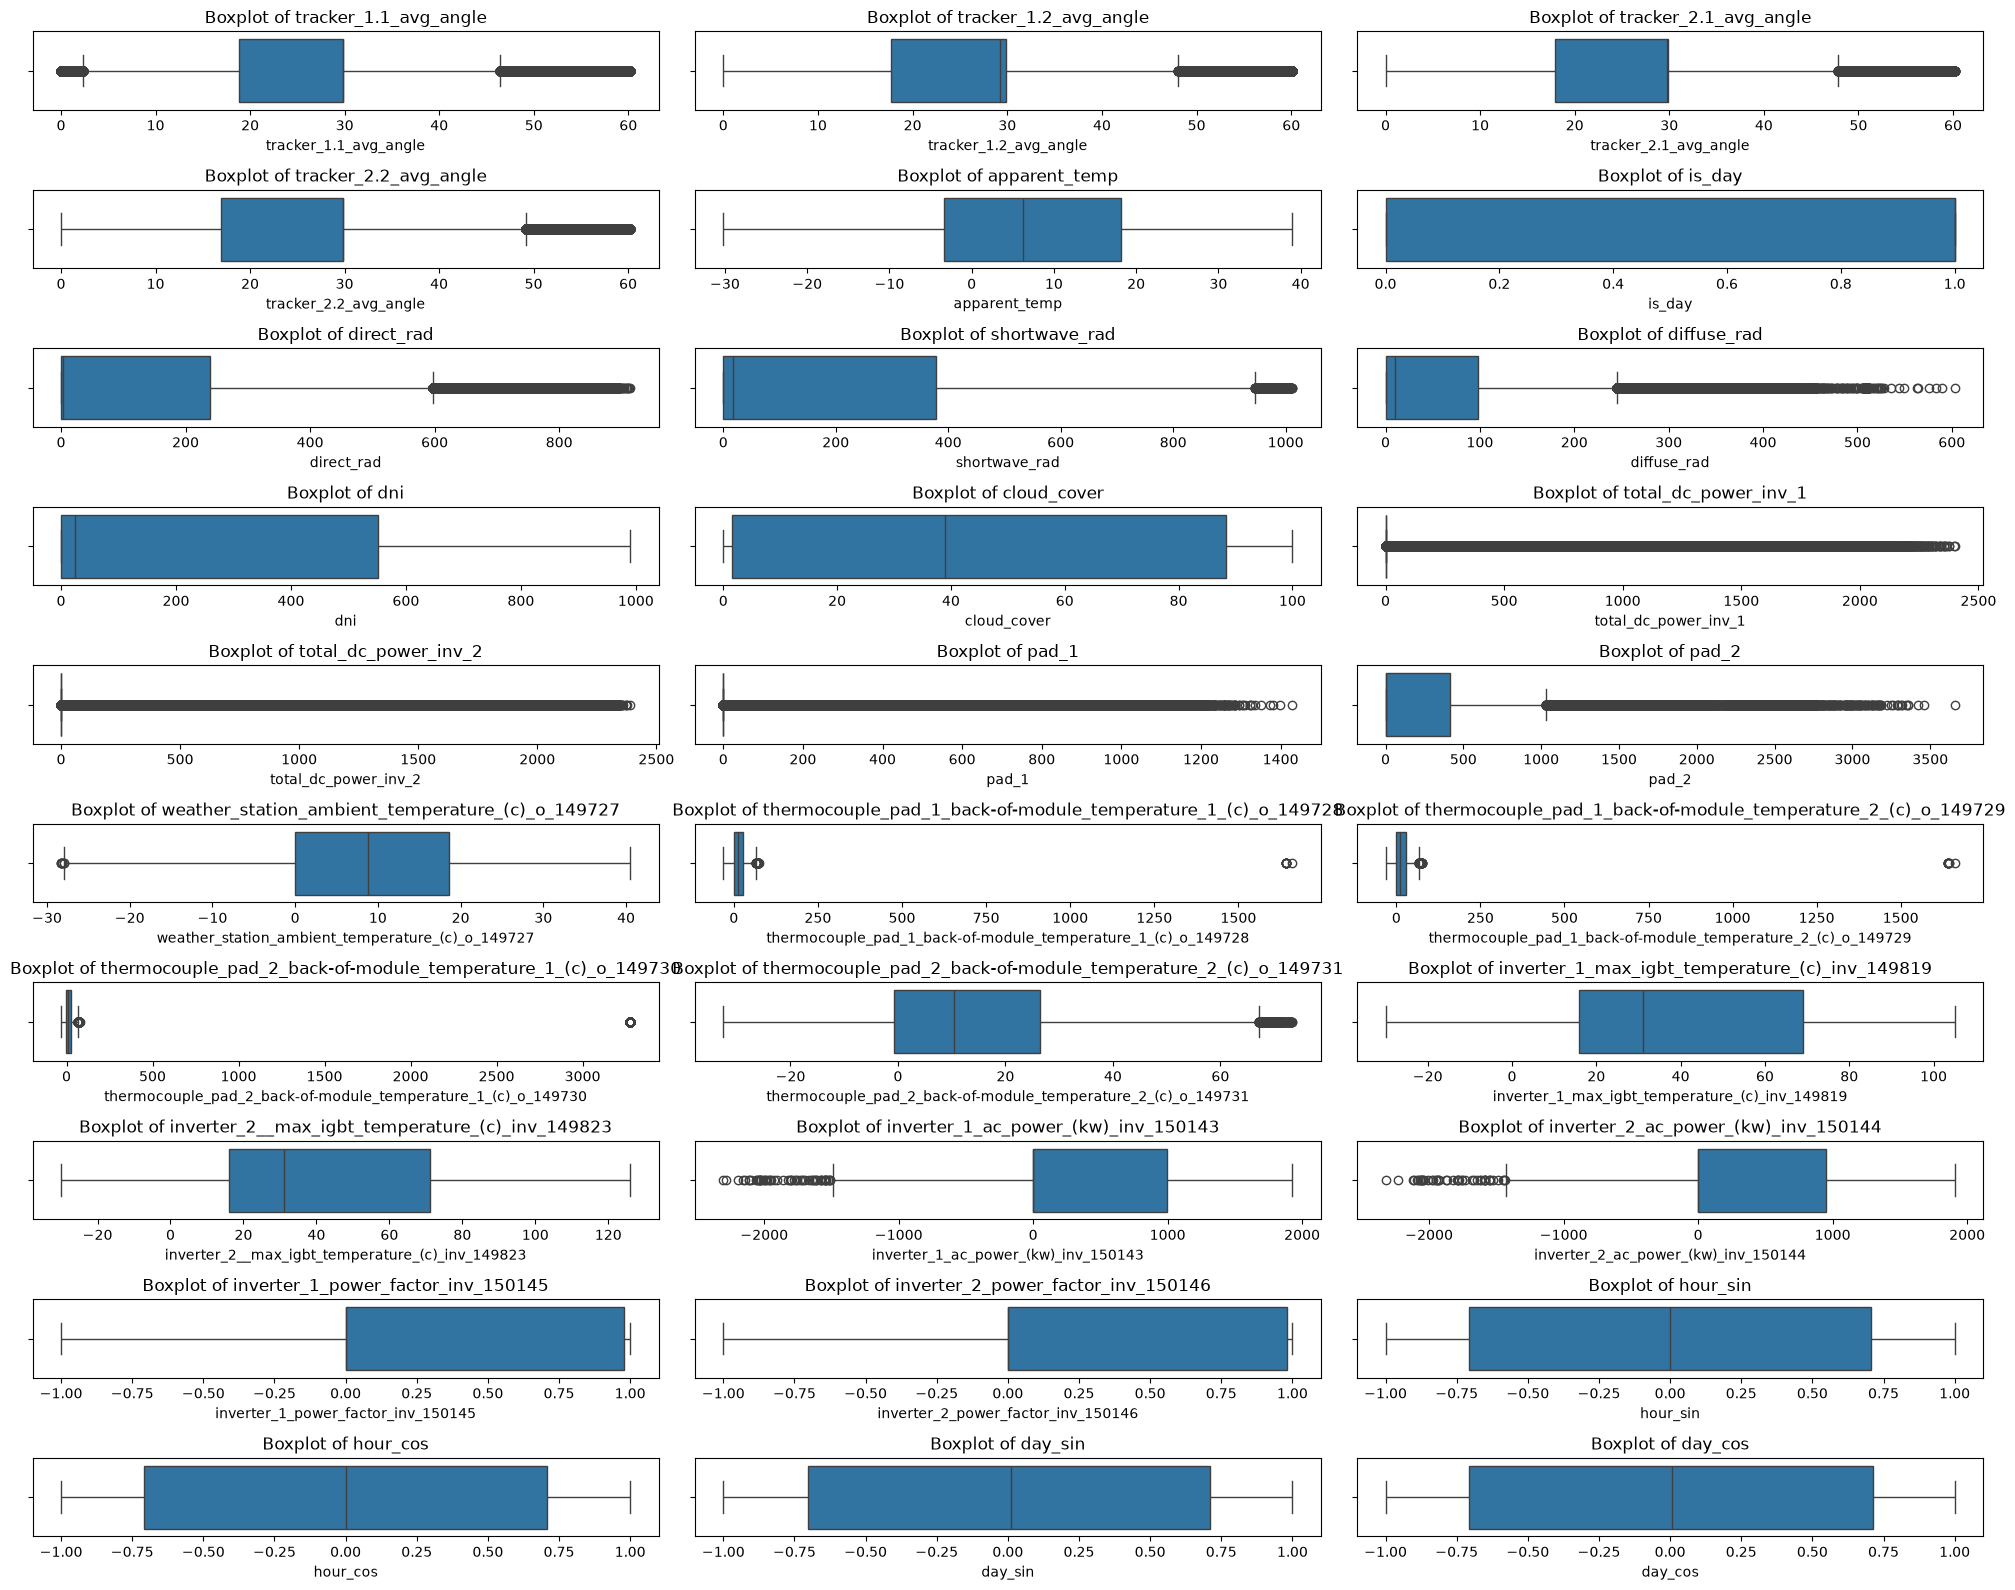

In [20]:
numeric_features = train_df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(20, 16))
for i, col in enumerate(numeric_features[:30]):
    plt.subplot(10, 3, i + 1)
    sns.boxplot(x=train_df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


In [21]:
print("train_df columns (lag-free):", train_df.columns.tolist())
print()
print("train_df_flat columns (with lags):", train_df_flat.columns.tolist())


train_df columns (lag-free): ['tracker_1.1_avg_angle', 'tracker_1.2_avg_angle', 'tracker_2.1_avg_angle', 'tracker_2.2_avg_angle', 'apparent_temp', 'is_day', 'direct_rad', 'shortwave_rad', 'diffuse_rad', 'dni', 'cloud_cover', 'total_dc_power_inv_1', 'total_dc_power_inv_2', 'pad_1', 'pad_2', 'weather_station_ambient_temperature_(c)_o_149727', 'thermocouple_pad_1_back-of-module_temperature_1_(c)_o_149728', 'thermocouple_pad_1_back-of-module_temperature_2_(c)_o_149729', 'thermocouple_pad_2_back-of-module_temperature_1_(c)_o_149730', 'thermocouple_pad_2_back-of-module_temperature_2_(c)_o_149731', 'inverter_1_max_igbt_temperature_(c)_inv_149819', 'inverter_2__max_igbt_temperature_(c)_inv_149823', 'inverter_1_ac_power_(kw)_inv_150143', 'inverter_2_ac_power_(kw)_inv_150144', 'inverter_1_power_factor_inv_150145', 'inverter_2_power_factor_inv_150146', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'obj_ac_power_1hour', 'obj_ac_power_2hour']

train_df_flat columns (with lags): ['tracker_1.1_avg_an

## 5. Scaling

Two scalers now: one for the lag-free (LSTM) feature set, one for the lagged (flat) feature set. Both fit only on train, applied (not re-fit) to val/test. `target_scaler` is fit once on `train_df`'s targets and shared, since the target values themselves are identical in both versions.

In [22]:
from sklearn.preprocessing import StandardScaler

target_cols = ['obj_ac_power_1hour', 'obj_ac_power_2hour']

lstm_feature_cols = [c for c in train_df.columns if c not in target_cols]
feature_cols = [c for c in train_df_flat.columns if c not in target_cols]

print(f"lstm_feature_cols (LSTM, lag-free): {len(lstm_feature_cols)}")
print(f"feature_cols (flat models, with lags): {len(feature_cols)}")

# ---- Scaler for the LSTM (lag-free) feature set ----
lstm_scaler = StandardScaler()
lstm_scaler.fit(train_df[lstm_feature_cols])

train_df_scaled = train_df.copy()
val_df_scaled = val_df.copy()
test_df_scaled = test_df.copy()

train_df_scaled[lstm_feature_cols] = lstm_scaler.transform(train_df[lstm_feature_cols])
val_df_scaled[lstm_feature_cols] = lstm_scaler.transform(val_df[lstm_feature_cols])
test_df_scaled[lstm_feature_cols] = lstm_scaler.transform(test_df[lstm_feature_cols])

# ---- Scaler for the flat (lagged) feature set ----
flat_scaler = StandardScaler()
flat_scaler.fit(train_df_flat[feature_cols])

train_flat_scaled = train_df_flat.copy()
val_flat_scaled = val_df_flat.copy()
test_flat_scaled = test_df_flat.copy()

train_flat_scaled[feature_cols] = flat_scaler.transform(train_df_flat[feature_cols])
val_flat_scaled[feature_cols] = flat_scaler.transform(val_df_flat[feature_cols])
test_flat_scaled[feature_cols] = flat_scaler.transform(test_df_flat[feature_cols])

# ---- Shared target scaler ----
target_scaler = StandardScaler()
target_scaler.fit(train_df[target_cols])

train_df_scaled[target_cols] = target_scaler.transform(train_df[target_cols])
val_df_scaled[target_cols] = target_scaler.transform(val_df[target_cols])
test_df_scaled[target_cols] = target_scaler.transform(test_df[target_cols])

train_flat_scaled[target_cols] = target_scaler.transform(train_df_flat[target_cols])
val_flat_scaled[target_cols] = target_scaler.transform(val_df_flat[target_cols])
test_flat_scaled[target_cols] = target_scaler.transform(test_df_flat[target_cols])

print("\nNaNs check:")
print("train_df_scaled:", train_df_scaled.isnull().sum().sum())
print("train_flat_scaled:", train_flat_scaled.isnull().sum().sum())


lstm_feature_cols (LSTM, lag-free): 30
feature_cols (flat models, with lags): 130

NaNs check:
train_df_scaled: 0
train_flat_scaled: 0


In [23]:
print(f"Train mean: {train_df_scaled['inverter_1_ac_power_(kw)_inv_150143'].mean():.2f}")
print(f"Train std: {train_df_scaled['inverter_1_ac_power_(kw)_inv_150143'].std():.2f}")
print(f"Validation mean: {val_df_scaled['inverter_1_ac_power_(kw)_inv_150143'].mean():.2f}")
print(f"Test mean: {test_df_scaled['inverter_1_ac_power_(kw)_inv_150143'].mean():.2f}")


Train mean: 0.00
Train std: 1.00
Validation mean: -0.07
Test mean: -0.03


## 6. Sliding windows (LSTM) & flat arrays (tree/linear models)

FIX (MemoryError): the original built every overlapping window upfront into one
array — with `window_size=24` and 130 features, that's `(506297, 24, 130)`
float64 ≈ 11.8 GB, since each row gets duplicated into ~24 different windows.

Fixed with:
1. **Lazy windowing** — `SlidingWindowDataset` slices a window out of the base
   array only when a batch is requested, so memory stays at the size of the
   base feature array.
2. **Lag-free LSTM input** — `train_df_scaled` now has no `lag_*` columns at
   all (see section 4), so the per-window size is already just the ~30 base
   features rather than ~130.

The flat arrays for the tree/linear models come straight from
`train_flat_scaled` / `val_flat_scaled` / `test_flat_scaled` — no windowing
involved, since the `lag_*` columns already encode the history those models need.

In [24]:
class SlidingWindowDataset(torch.utils.data.Dataset):
    """Lazily slices sliding windows out of a scaled dataframe.

    Only the base (num_rows, num_features) array is held in memory; each
    window is materialized on demand inside __getitem__, avoiding the
    (num_rows, window_size, num_features) blowup of pre-building every window.
    """
    def __init__(self, df_scaled, target_cols, feature_cols, window_size=24):
        # Cast to float32 immediately -- halves memory vs. pandas' default float64
        self.features = df_scaled[feature_cols].values.astype(np.float32)
        self.targets = df_scaled[target_cols].values.astype(np.float32)
        self.window_size = window_size
        self.index = df_scaled.index

    def __len__(self):
        return len(self.features) - self.window_size

    def __getitem__(self, i):
        x = self.features[i: i + self.window_size]   # (window_size, num_features)
        y = self.targets[i + self.window_size]         # (num_targets,)
        return torch.from_numpy(x), torch.from_numpy(y)

    @property
    def target_index(self):
        """Timestamps aligned with each item's target (i.e. index[window_size:])."""
        return self.index[self.window_size:]


In [25]:
WINDOW_SIZE = 24

# Lazy datasets for the LSTM (lag-free)
train_dataset = SlidingWindowDataset(train_df_scaled, target_cols, lstm_feature_cols, WINDOW_SIZE)
val_dataset = SlidingWindowDataset(val_df_scaled, target_cols, lstm_feature_cols, WINDOW_SIZE)
test_dataset = SlidingWindowDataset(test_df_scaled, target_cols, lstm_feature_cols, WINDOW_SIZE)

# Flat arrays for Linear Regression / Random Forest / XGBoost (with lags)
X_train_flat = train_flat_scaled[feature_cols].values
y_train_flat = train_flat_scaled[target_cols].values
idx_train = train_flat_scaled.index

X_val_flat = val_flat_scaled[feature_cols].values
y_val_flat = val_flat_scaled[target_cols].values
idx_val = val_flat_scaled.index

X_test_flat = test_flat_scaled[feature_cols].values
y_test_flat = test_flat_scaled[target_cols].values
idx_test = test_flat_scaled.index


In [26]:
print("LSTM datasets (lazy, windowed, lag-free):")
print("  train:", len(train_dataset), "windows |", len(lstm_feature_cols), "features")
print("  val:  ", len(val_dataset), "windows")
print("  test: ", len(test_dataset), "windows")

print("\nFlat arrays (tree/linear models, with lags):")
print("  X_train_flat:", X_train_flat.shape)
print("  X_val_flat:  ", X_val_flat.shape)
print("  X_test_flat: ", X_test_flat.shape)


LSTM datasets (lazy, windowed, lag-free):
  train: 523318 windows | 30 features
  val:   131857 windows
  test:  139633 windows

Flat arrays (tree/linear models, with lags):
  X_train_flat: (523318, 130)
  X_val_flat:   (131857, 130)
  X_test_flat:  (139633, 130)


## 7. Evaluation helper

Accepts either a `torch.utils.data.Dataset`/`DataLoader` (LSTM path) or a raw array (tree/linear models). Metrics themselves (peak-masked MAPE, RMSE/MAE/R2/NRMSE) are unchanged from the original — that part was already well designed.

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def evaluate_model(
    name,
    model,
    X_test,
    y_test_scaled,
    target_scaler,
    X_train=None,
    y_train_scaled=None,
    is_pytorch=False,
    device="cpu",
    target_names=("1 Hour", "2 Hour"),
    batch_size=256,
    plot=True,
    verbose=True
):
    # ---- Prediction ----
    if is_pytorch:
        model = model.to(device)
        model.eval()

        # X_test can be a lazy SlidingWindowDataset (or a DataLoader built from
        # one) instead of a fully-materialized tensor. Both predictions and
        # ground-truth targets are collected straight from the loader.
        if isinstance(X_test, torch.utils.data.DataLoader):
            loader = X_test
        elif isinstance(X_test, torch.utils.data.Dataset):
            loader = torch.utils.data.DataLoader(X_test, batch_size=batch_size, shuffle=False)
        else:
            # Backward-compatible path: raw tensor + separate y_test_scaled
            if not isinstance(X_test, torch.Tensor):
                X_test = torch.tensor(X_test, dtype=torch.float32)
            y_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)
            loader = torch.utils.data.DataLoader(
                torch.utils.data.TensorDataset(X_test, y_tensor),
                batch_size=batch_size, shuffle=False
            )

        predictions, actuals = [], []
        with torch.no_grad():
            for batch_x, batch_y in loader:
                batch_x = batch_x.to(device)
                pred = model(batch_x)
                predictions.append(pred.cpu())
                actuals.append(batch_y)
        y_pred_scaled = torch.cat(predictions, dim=0).numpy()
        y_test_scaled = torch.cat(actuals, dim=0).numpy()
    else:
        y_pred_scaled = model.predict(X_test)

    # ---- Inverse scaling ----
    y_true_real = target_scaler.inverse_transform(y_test_scaled)
    y_pred_real = target_scaler.inverse_transform(y_pred_scaled)

    results = {"Model": name}

    if verbose:
        print("=" * 80)
        print(name)
        print("=" * 80)

    for i, target in enumerate(target_names):
        y_true = y_true_real[:, i]
        y_pred = y_pred_real[:, i]

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        peak = np.max(y_true)
        nrmse = rmse / peak

        mask = y_true > (0.1 * peak)
        if mask.sum():
            mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
        else:
            mape = np.nan

        results[target] = {"RMSE_kW": rmse, "MAE_kW": mae, "R2": r2, "NRMSE": nrmse, "MAPE_%": mape}

        if verbose:
            print(f"\n----- {target} -----")
            print(f"RMSE : {rmse:.3f} kW")
            print(f"MAE  : {mae:.3f} kW")
            print(f"R²   : {r2:.4f}")
            print(f"NRMSE: {nrmse:.4f}")
            print(f"MAPE : {mape:.2f}%")

        if plot:
            plt.figure(figsize=(5, 5))
            plt.scatter(y_true, y_pred, alpha=0.4)
            plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], "r--")
            plt.xlabel("Actual kW")
            plt.ylabel("Prediction kW")
            plt.title(f"{name} - {target}")
            plt.grid()
            plt.show()

            plt.figure(figsize=(12, 4))
            plt.plot(y_true[:500], label="Actual")
            plt.plot(y_pred[:500], "--", label="Prediction")
            plt.title(target)
            plt.legend()
            plt.grid()
            plt.show()

            residuals = y_true - y_pred
            plt.figure(figsize=(7, 3))
            sns.histplot(residuals, bins=50, kde=True)
            plt.title(f"Residuals - {target}")
            plt.grid()
            plt.show()

    return results


## 8. Classical baselines

Each model's results go into its own variable. These use `feature_cols` (with lags).

In [28]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_flat, y_train_flat)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2, 130)","[[-0.07,-0.02,-0.05,..., 0. , 0. ,-0. ], [-0.1 ,-0.04,-0.09,..., 0. , 0.01,-0.01]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](2,)","[0.,0.]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,130
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,125
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](130,)","[5523.84,3470.34,2873.2 ,..., 0. , 0. , 0. ]"


Linear Regression

----- 1 Hour -----
RMSE : 562.245 kW
MAE  : 378.066 kW
R²   : 0.8023
NRMSE: 0.1480
MAPE : 40.20%


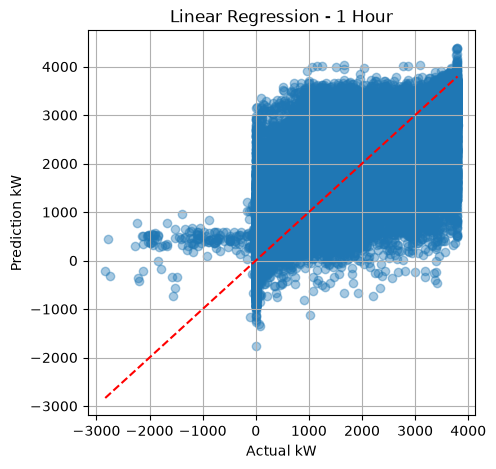

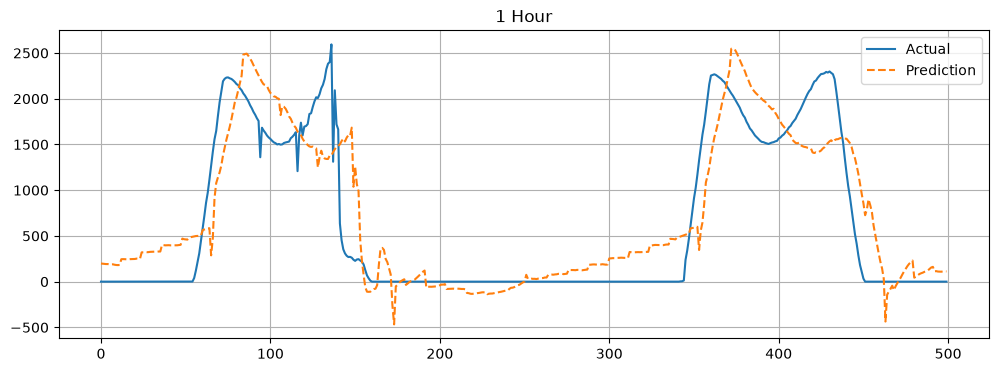

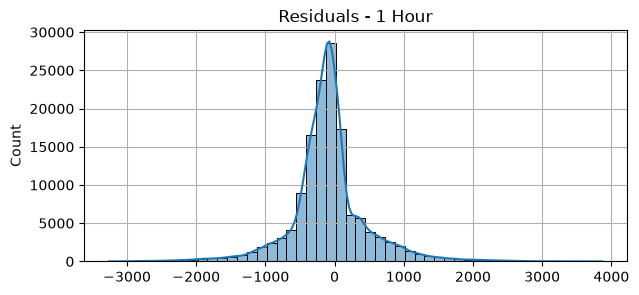


----- 2 Hour -----
RMSE : 706.624 kW
MAE  : 524.941 kW
R²   : 0.6877
NRMSE: 0.1861
MAPE : 49.66%


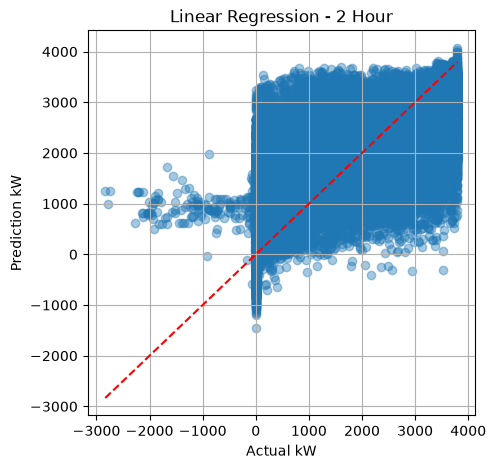

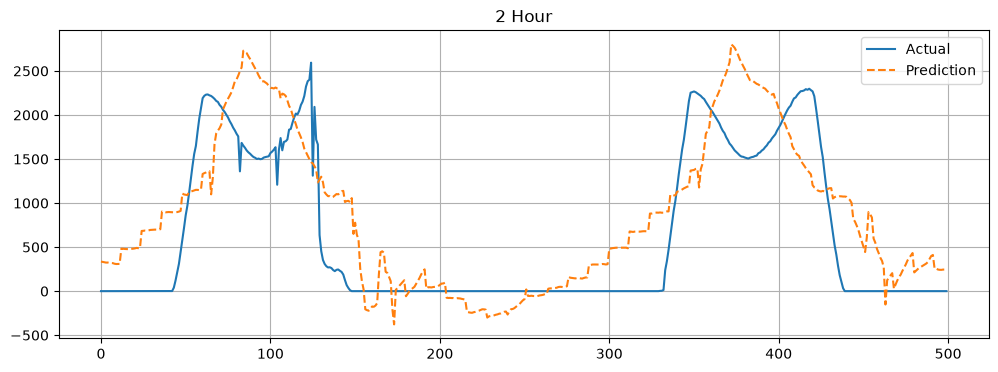

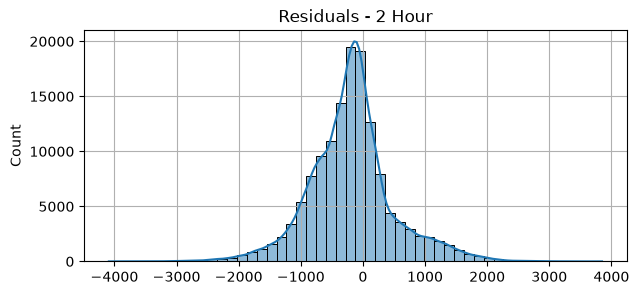

In [29]:
lr_results = evaluate_model(
    name="Linear Regression",
    model=lr_model,
    X_test=X_test_flat,
    y_test_scaled=y_test_flat,
    target_scaler=target_scaler,
    X_train=X_train_flat,
    y_train_scaled=y_train_flat
)


### Random Forest -- hyperparameter tuning (speed-fixed)

The earlier attempt at this took 2+ hours with no visible progress and had
to be stopped. Two likely causes, both fixed below:

1. **Nested parallelism.** `RandomizedSearchCV(n_jobs=-1)` together with
   `RandomForestRegressor(n_jobs=-1)` means each of the search's parallel
   workers tries to spawn its own full set of parallel workers -- massively
   oversubscribing CPU cores (e.g. 8 cores -> up to 64 competing threads),
   which thrashes far worse than running things one at a time. Fixed by
   parallelizing at only **one** level: the search runs candidates
   sequentially (`n_jobs=1`), while each individual Random Forest fit uses
   all cores (`n_jobs=-1`). This also means progress prints one candidate at
   a time instead of many interleaved, unreadable progress bars.
2. **Unbounded trees.** The search space included `max_depth=None` (fully
   grown trees) and `min_samples_leaf=1`. On ~500K rows this can produce
   very deep, very expensive trees. Both bounded below.

An optional subsample toggle (`SEARCH_SAMPLE_SIZE`) is also included:
fitting several candidate forests on the full ~500K-row training set is
expensive even with the fixes above. Searching on a random subsample first
finds a *good* configuration much faster -- the **final** chosen model is
still refit on the full training set afterward, so the final model's
accuracy isn't reduced, only the search phase is cheaper. Set it to `None`
to search on the full data instead (slower, most faithful).

In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
import time

# None = search on the full train+val pool. An integer (e.g. 100_000) =
# subsample the SEARCH phase only, for speed -- final refit always uses the
# FULL X_train_flat / y_train_flat regardless of this setting.
SEARCH_SAMPLE_SIZE = 100_000

rng = np.random.default_rng(SEED)

if SEARCH_SAMPLE_SIZE is not None and SEARCH_SAMPLE_SIZE < len(X_train_flat):
    train_idx = rng.choice(len(X_train_flat), size=SEARCH_SAMPLE_SIZE, replace=False)
else:
    train_idx = np.arange(len(X_train_flat))

if SEARCH_SAMPLE_SIZE is not None and SEARCH_SAMPLE_SIZE < len(X_val_flat):
    val_idx = rng.choice(len(X_val_flat), size=min(SEARCH_SAMPLE_SIZE, len(X_val_flat)), replace=False)
else:
    val_idx = np.arange(len(X_val_flat))

X_search_rf = np.vstack([X_train_flat[train_idx], X_val_flat[val_idx]])
y_search_rf = np.vstack([y_train_flat[train_idx], y_val_flat[val_idx]])
test_fold_rf = np.array([-1] * len(train_idx) + [0] * len(val_idx))
ps_rf = PredefinedSplit(test_fold_rf)

print(f"Search pool: {len(train_idx)} train rows + {len(val_idx)} val rows "
      f"(full training set has {len(X_train_flat)} rows)")

rf_param_dist = {
    "n_estimators": [150, 200, 300, 400],
    "max_depth": [10, 15, 20],        # unbounded (None) removed -- was a major slowdown source
    "min_samples_leaf": [2, 5, 10],    # 1 removed -- allowed pathologically deep, slow trees
    "max_features": ["sqrt", 0.5, 0.8],
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=SEED, n_jobs=-1),  # parallel WITHIN each fit
    param_distributions=rf_param_dist,
    n_iter=10,          # reduced from 15 for a faster first pass -- raise once this completes reliably
    cv=ps_rf,
    scoring="neg_root_mean_squared_error",
    random_state=SEED,
    n_jobs=1,            # sequential candidates -- avoids the nested-parallelism thrash described above
    verbose=3,            # prints each candidate's params + timing as it runs, so it's never silent
)

start = time.time()
rf_search.fit(X_search_rf, y_search_rf)
print(f"\nSearch finished in {(time.time() - start) / 60:.1f} minutes")

print("Best RF params:", rf_search.best_params_)
print("Best RF val RMSE (scaled target space):", -rf_search.best_score_)

# Refit the tuned model on the FULL training set (not the search subsample) before final evaluation.
rf_model = RandomForestRegressor(**rf_search.best_params_, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train_flat, y_train_flat)


Search pool: 100000 train rows + 100000 val rows (full training set has 523318 rows)
Fitting 1 folds for each of 10 candidates, totalling 10 fits
[CV 1/1] END max_depth=20, max_features=sqrt, min_samples_leaf=5, n_estimators=200;, score=-0.395 total time=  18.2s
[CV 1/1] END max_depth=10, max_features=sqrt, min_samples_leaf=10, n_estimators=300;, score=-0.405 total time=  18.9s
[CV 1/1] END max_depth=10, max_features=sqrt, min_samples_leaf=5, n_estimators=150;, score=-0.404 total time=   8.8s
[CV 1/1] END max_depth=20, max_features=sqrt, min_samples_leaf=10, n_estimators=400;, score=-0.396 total time=  34.4s
[CV 1/1] END max_depth=15, max_features=0.8, min_samples_leaf=2, n_estimators=300;, score=-0.386 total time= 3.4min
[CV 1/1] END max_depth=15, max_features=0.8, min_samples_leaf=5, n_estimators=400;, score=-0.385 total time= 4.5min
[CV 1/1] END max_depth=10, max_features=0.8, min_samples_leaf=5, n_estimators=300;, score=-0.388 total time= 2.9min
[CV 1/1] END max_depth=15, max_featu

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"ma

Random Forest (tuned)

----- 1 Hour -----
RMSE : 473.780 kW
MAE  : 237.107 kW
R²   : 0.8596
NRMSE: 0.1247
MAPE : 34.37%


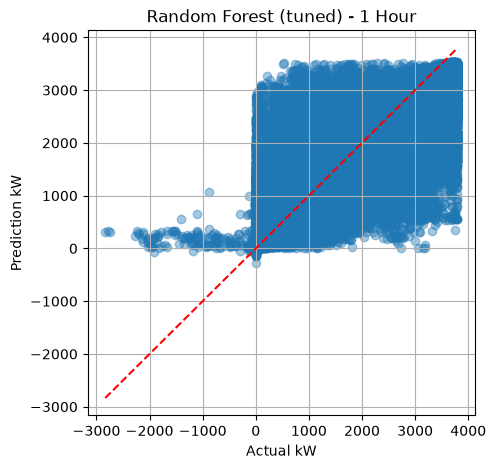

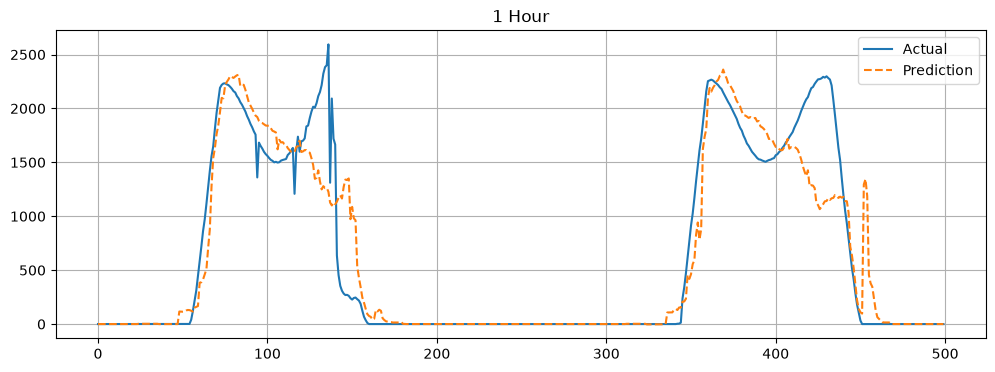

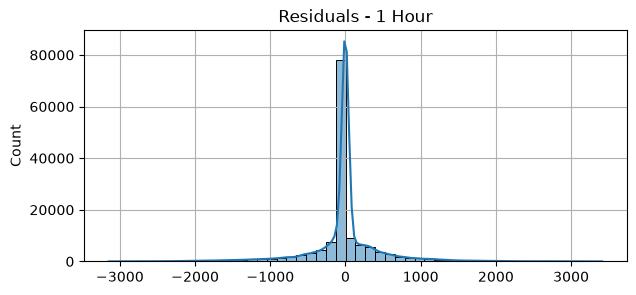


----- 2 Hour -----
RMSE : 564.446 kW
MAE  : 301.908 kW
R²   : 0.8007
NRMSE: 0.1486
MAPE : 41.12%


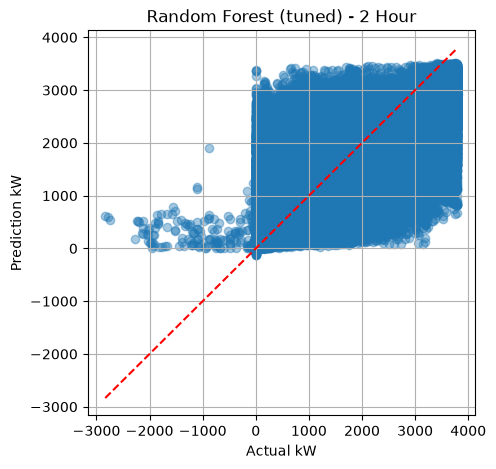

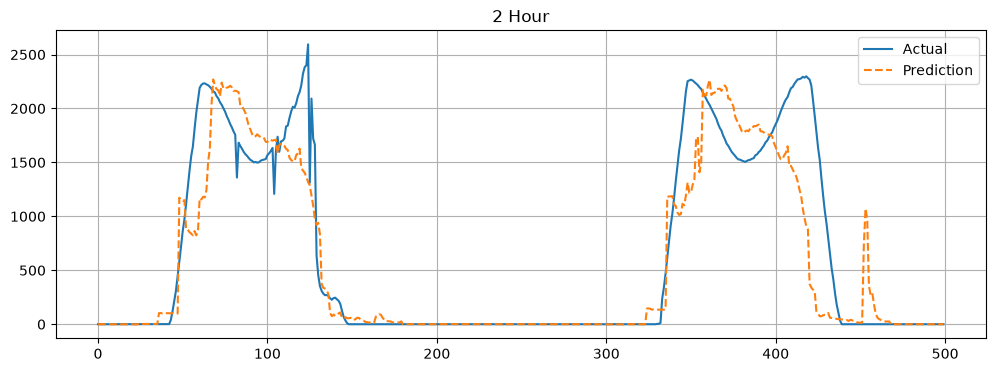

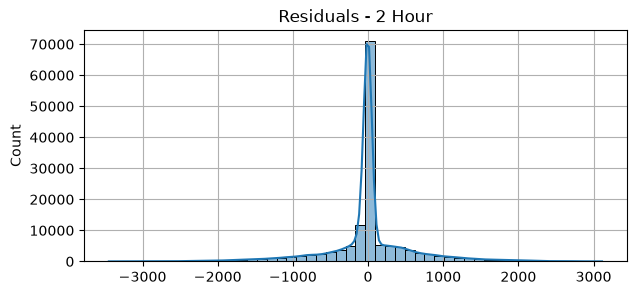

In [31]:
rf_results = evaluate_model(
    name="Random Forest (tuned)",
    model=rf_model,
    X_test=X_test_flat,
    y_test_scaled=y_test_flat,
    target_scaler=target_scaler,
    X_train=X_train_flat,
    y_train_scaled=y_train_flat
)


### XGBoost -- hyperparameter tuning + GPU

Same `PredefinedSplit`/subsample approach as Random Forest, plus the same
single-level-of-parallelism fix. Unlike Random Forest, XGBoost genuinely can
use a GPU: `device='cuda'` (XGBoost 2.x's current API) is set automatically
when `USE_CUDA` is True (from the diagnostic cell near the top of the
notebook), falling back to `device='cpu'` otherwise.

In [32]:
from xgboost import XGBRegressor

xgb_device = "cuda" if USE_CUDA else "cpu"
print(f"XGBoost will train on: {xgb_device}")

# Reuse the same search pool as the RF search above for consistency.
xgb_param_dist = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [4, 6, 8],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=SEED,
        tree_method="hist",
        device=xgb_device,
    ),
    param_distributions=xgb_param_dist,
    n_iter=10,
    cv=ps_rf,   # same PredefinedSplit / search pool built in the RF cell above
    scoring="neg_root_mean_squared_error",
    random_state=SEED,
    n_jobs=1,    # sequential candidates -- XGBoost already parallelizes internally per fit
    verbose=3,
)

start = time.time()
xgb_search.fit(X_search_rf, y_search_rf)
print(f"\nSearch finished in {(time.time() - start) / 60:.1f} minutes")

print("Best XGBoost params:", xgb_search.best_params_)
print("Best XGBoost val RMSE (scaled target space):", -xgb_search.best_score_)

xgb_model = XGBRegressor(
    **xgb_search.best_params_,
    objective="reg:squarederror",
    random_state=SEED,
    tree_method="hist",
    device=xgb_device,
)
xgb_model.fit(X_train_flat, y_train_flat, verbose=True)


XGBoost will train on: cuda
Fitting 1 folds for each of 10 candidates, totalling 10 fits


d:\AI_and_Python\Local_Notebooks\pvdaq_db\pvdaq_db\.venv\Lib\site-packages\xgboost\core.py:751: UserWarning: [13:45:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV 1/1] END colsample_bytree=0.8, learning_rate=0.01, max_depth=8, n_estimators=500, subsample=0.6;, score=-0.385 total time=  21.6s
[CV 1/1] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.6;, score=-0.429 total time=   2.3s
[CV 1/1] END colsample_bytree=0.8, learning_rate=0.03, max_depth=4, n_estimators=200, subsample=1.0;, score=-0.395 total time=   2.2s
[CV 1/1] END colsample_bytree=0.6, learning_rate=0.01, max_depth=6, n_estimators=200, subsample=0.6;, score=-0.416 total time=   3.8s
[CV 1/1] END colsample_bytree=0.8, learning_rate=0.05, max_depth=8, n_estimators=200, subsample=0.6;, score=-0.389 total time=   8.1s
[CV 1/1] END colsample_bytree=0.8, learning_rate=0.01, max_depth=8, n_estimators=200, subsample=0.6;, score=-0.407 total time=   9.5s
[CV 1/1] END colsample_bytree=1.0, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=0.6;, score=-0.404 total time=   3.3s
[CV 1/1] END colsample_bytree=0.8, learning_rate=0.1, max_dept

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


XGBoost (tuned)

----- 1 Hour -----
RMSE : 469.695 kW
MAE  : 239.328 kW
R²   : 0.8620
NRMSE: 0.1237
MAPE : 33.19%


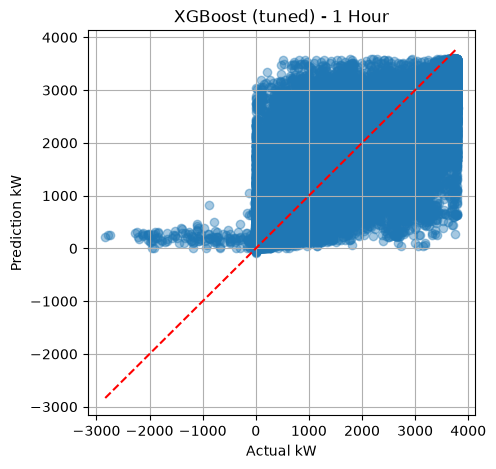

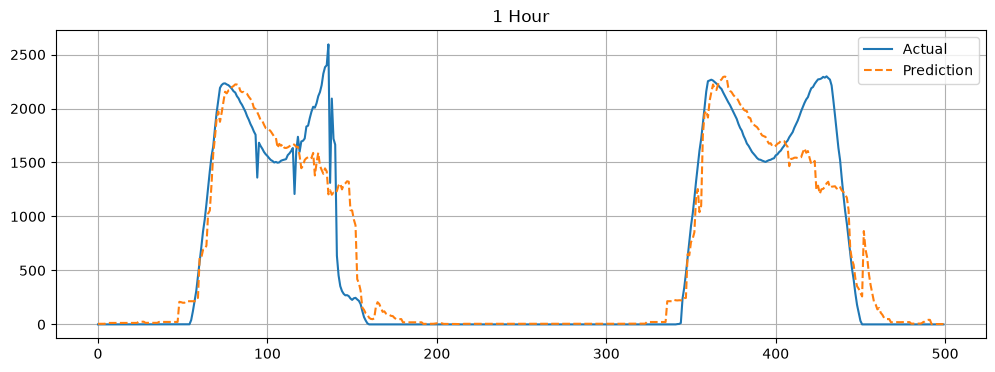

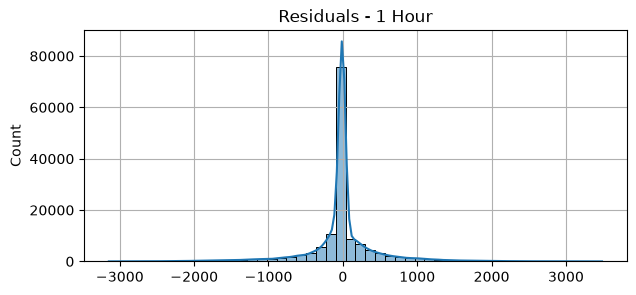


----- 2 Hour -----
RMSE : 561.646 kW
MAE  : 303.640 kW
R²   : 0.8027
NRMSE: 0.1479
MAPE : 39.82%


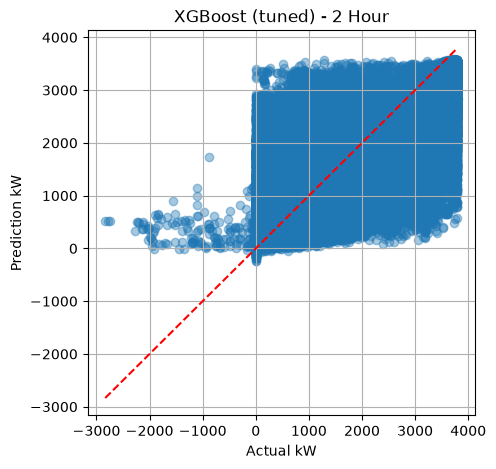

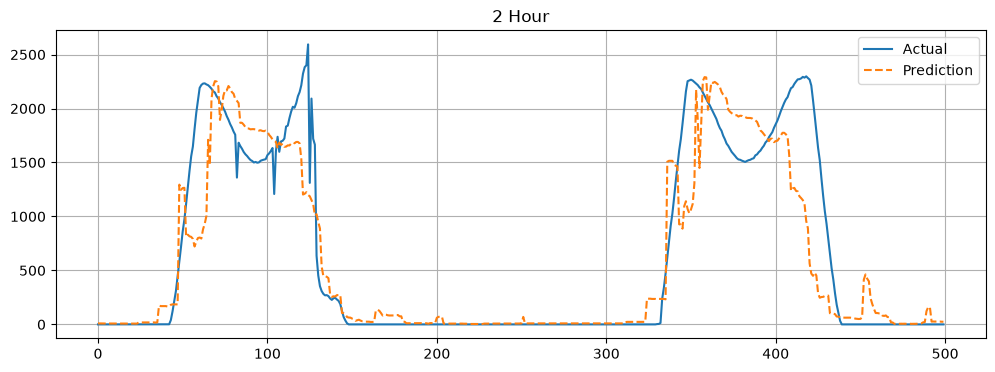

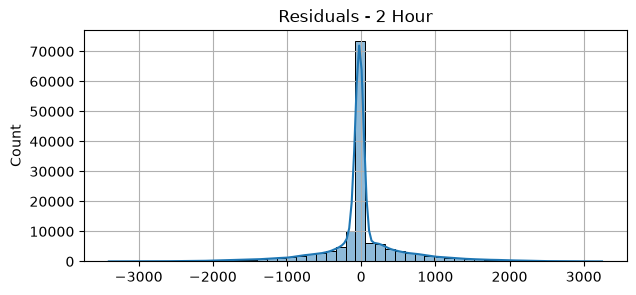

In [33]:
xgb_results = evaluate_model(
    name="XGBoost (tuned)",
    model=xgb_model,
    X_test=X_test_flat,
    y_test_scaled=y_test_flat,
    target_scaler=target_scaler,
    X_train=X_train_flat,
    y_train_scaled=y_train_flat
)


## 9. Daytime-only experiment (fixed)

FIX (important): the original filtered rows with `.between_time('06:00','18:00')`
*before* building sliding windows, which could splice non-adjacent days
together. The fix: use the flat arrays built from the full continuous data,
then keep only the rows whose **timestamp** falls in daytime.

In [34]:
day_mask_train = (idx_train.hour >= 6) & (idx_train.hour <= 18)
day_mask_val = (idx_val.hour >= 6) & (idx_val.hour <= 18)
day_mask_test = (idx_test.hour >= 6) & (idx_test.hour <= 18)

X_day_train_flat, y_day_train_flat = X_train_flat[day_mask_train], y_train_flat[day_mask_train]
X_day_val_flat, y_day_val_flat = X_val_flat[day_mask_val], y_val_flat[day_mask_val]
X_day_test_flat, y_day_test_flat = X_test_flat[day_mask_test], y_test_flat[day_mask_test]

print("Day-only train samples:", X_day_train_flat.shape[0], "/", X_train_flat.shape[0])
print("Day-only test samples: ", X_day_test_flat.shape[0], "/", X_test_flat.shape[0])


Day-only train samples: 283452 / 523318
Day-only test samples:  75660 / 139633


In [35]:
rf_day_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=5,
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)
rf_day_model.fit(X_day_train_flat, y_day_train_flat)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:  1.9min


KeyboardInterrupt: 

In [37]:
rf_day_results = evaluate_model(
    name="Random Forest (daytime only)",
    model=rf_day_model,
    X_test=X_day_test_flat,
    y_test_scaled=y_day_test_flat,
    target_scaler=target_scaler,
    X_train=X_day_train_flat,
    y_train_scaled=y_day_train_flat
)


IndexError: list index out of range

## 10. LSTM forecaster

Uses `lstm_feature_cols` (lag-free) and the lazy `SlidingWindowDataset`s built
above. `input_size` is derived from `len(lstm_feature_cols)`.

In [39]:
class LSTMOnlyForecaster(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=64,
            batch_first=True, num_layers=2, dropout=0.2
        )
        self.linear = nn.Linear(64, 2)

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.linear(last)


def build_lstm_and_optim(input_size, lr=0.001, weight_decay=1e-4):
    """Factory function so the model is freshly instantiated before each
    training run instead of being re-trained on top of a previous run's weights."""
    model = LSTMOnlyForecaster(input_size=input_size)
    optim = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optim, mode='min', factor=0.5, patience=5, min_lr=1e-6
    )
    return model, optim, scheduler


torch.manual_seed(SEED)
lstm_only_model, optim, scheduler = build_lstm_and_optim(input_size=len(lstm_feature_cols))
loss_fn = nn.MSELoss()


In [38]:
from torch.utils.data import DataLoader

BATCH_SIZE = 128

# train/val/test_dataset are the lazy SlidingWindowDataset instances built above.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


### Training loop

FIX (refactor): this used to be one long training loop written specifically
for the LSTM. Since the CNN+LSTM hybrid below needs the exact same training
procedure (same loss, same optimizer/scheduler pattern, same checkpointing,
same early stopping), it's pulled out into a reusable `train_forecaster()`
function instead of duplicating ~80 lines of near-identical code per model.
Checkpoint dict consistently uses `val_loss` as the key (save *and* resume).

In [40]:
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")


def train_forecaster(model, optim, scheduler, train_loader, val_loader,
                      checkpoint_path, epochs=50, patience=10, loss_fn=None):
    """Shared training loop for any (batch, window, features) -> (batch, targets)
    forecaster (plain LSTM, CNN+LSTM hybrid, etc). Returns the trained model
    (best checkpoint reloaded) plus the train/val loss history.
    """
    if loss_fn is None:
        loss_fn = nn.MSELoss()

    model.to(device)
    start_epoch = 0
    best_loss = float('inf')

    if os.path.exists(checkpoint_path):
        print(f"Found existing checkpoint at {checkpoint_path}. Loading weights to resume training...")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optim.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_loss = checkpoint['val_loss']
        print(f"Resuming training from Epoch {start_epoch} (Previous Best Validation Loss: {best_loss:.6f})")
    else:
        print("No previous checkpoint found. Starting training from scratch.")

    train_losses, val_losses = [], []
    counter = 0

    for n in range(start_epoch, epochs):
        # ---- Training ----
        model.train()
        full_loss = 0
        nb_batch = 0
        loop = tqdm(train_loader, desc=f"Epoch {n+1}/{epochs}")

        for batch_x, batch_y in loop:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            output = model(batch_x)
            loss = loss_fn(output, batch_y)

            optim.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optim.step()

            full_loss += loss.item()
            nb_batch += 1
            loop.set_postfix(loss=loss.item())

        epoch_loss = full_loss / nb_batch
        train_losses.append(epoch_loss)

        # ---- Validation ----
        model.eval()
        val_full_loss = 0
        val_nb_batch = 0
        with torch.no_grad():
            for val_x, val_y in val_loader:
                val_x, val_y = val_x.to(device), val_y.to(device)
                val_output = model(val_x)
                val_loss = loss_fn(val_output, val_y)
                val_full_loss += val_loss.item()
                val_nb_batch += 1
        val_epoch_loss = val_full_loss / val_nb_batch
        val_losses.append(val_epoch_loss)

        # ---- Scheduler ----
        scheduler.step(val_epoch_loss)
        current_lr = optim.param_groups[0]["lr"]

        print(f"Epoch {n+1:02d}/{epochs} | Train Loss: {epoch_loss:.6f} | Validation Loss: {val_epoch_loss:.6f}")
        print(f"Learning rate: {current_lr:.7f}")

        # ---- Save best checkpoint ----
        if val_epoch_loss < best_loss:
            best_loss = val_epoch_loss
            counter = 0
            torch.save({
                'epoch': n,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optim.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_loss': epoch_loss,
                'val_loss': best_loss,
            }, checkpoint_path)
            print(f"Checkpoint saved at epoch {n+1} with Best Validation Loss: {best_loss:.6f}")
        else:
            counter += 1
            print(f"No validation improvement ({counter}/{patience})")

        # ---- Early stopping ----
        if counter >= patience:
            print(f"Training stopped early at Epoch {n+1} due to validation stagnation.")
            break

    # ---- Load best model before returning ----
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Best model loaded from epoch {checkpoint['epoch']+1}")
    return model, train_losses, val_losses


def plot_forecast_and_loss(model, test_loader, target_scaler, train_losses, val_losses, title, device):
    """Shared plotting: first 20 predictions vs. actuals (both horizons) + loss curve."""
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for sample_x, sample_y in test_loader:
            sample_x = sample_x.to(device)
            out = model(sample_x).cpu()
            preds.append(out)
            actuals.append(sample_y)

    preds = torch.cat(preds).numpy()
    actuals = torch.cat(actuals).numpy()
    preds_real = target_scaler.inverse_transform(preds)
    actuals_real = target_scaler.inverse_transform(actuals)
    preds_1h, preds_2h = preds_real[:, 0], preds_real[:, 1]
    actuals_1h, actuals_2h = actuals_real[:, 0], actuals_real[:, 1]

    plt.figure(figsize=(12, 4))
    plt.plot(actuals_1h[:20], label='Actual 1h', color='blue')
    plt.plot(preds_1h[:20], label='Predicted 1h', linestyle='--', color='cyan')
    plt.plot(actuals_2h[:20], label='Actual 2h', color='red')
    plt.plot(preds_2h[:20], label='Predicted 2h', linestyle='--', color='orange')
    plt.xlabel('Time step')
    plt.ylabel('Power (kW)')
    plt.legend()
    plt.title(f'{title} — Forecast vs Actual (real kW scale)')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label="Training Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss (scaled target space)')
    plt.title(f'{title} — Training and Validation Loss Curve')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


Training on: cuda


In [ ]:
lstm_only_model, lstm_train_losses, lstm_val_losses = train_forecaster(
    model=lstm_only_model,
    optim=optim,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    checkpoint_path="best_lstm_only_model.pth",
    epochs=50,
    patience=10,
    loss_fn=loss_fn,
)


C:\Users\aidim\AppData\Local\Temp\ipykernel_24340\2723272554.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=devic

Found existing checkpoint at best_lstm_only_model.pth. Loading weights to resume training...
Resuming training from Epoch 21 (Previous Best Validation Loss: 0.171644)


Epoch 22/50: 100%|██████████| 4089/4089 [00:27<00:00, 149.75it/s, loss=0.00157] 


Epoch 22/50 | Train Loss: 0.150471 | Validation Loss: 0.172499
Learning rate: 0.0005000
No validation improvement (1/10)


Epoch 23/50: 100%|██████████| 4089/4089 [00:27<00:00, 146.84it/s, loss=0.00136] 


Epoch 23/50 | Train Loss: 0.150170 | Validation Loss: 0.174016
Learning rate: 0.0005000
No validation improvement (2/10)


Epoch 24/50: 100%|██████████| 4089/4089 [00:31<00:00, 131.37it/s, loss=0.00159] 


Epoch 24/50 | Train Loss: 0.149829 | Validation Loss: 0.174815
Learning rate: 0.0005000
No validation improvement (3/10)


Epoch 25/50: 100%|██████████| 4089/4089 [00:28<00:00, 144.51it/s, loss=0.00204] 


Epoch 25/50 | Train Loss: 0.149795 | Validation Loss: 0.175092
Learning rate: 0.0005000
No validation improvement (4/10)


Epoch 26/50: 100%|██████████| 4089/4089 [00:27<00:00, 147.11it/s, loss=0.00137] 


Epoch 26/50 | Train Loss: 0.149465 | Validation Loss: 0.175431
Learning rate: 0.0005000
No validation improvement (5/10)


Epoch 27/50: 100%|██████████| 4089/4089 [00:27<00:00, 146.89it/s, loss=0.00114] 


Epoch 27/50 | Train Loss: 0.149025 | Validation Loss: 0.175497
Learning rate: 0.0002500
No validation improvement (6/10)


Epoch 28/50: 100%|██████████| 4089/4089 [00:27<00:00, 147.69it/s, loss=0.000717]


Epoch 28/50 | Train Loss: 0.146998 | Validation Loss: 0.174344
Learning rate: 0.0002500
No validation improvement (7/10)


Epoch 29/50: 100%|██████████| 4089/4089 [00:27<00:00, 148.11it/s, loss=0.00053] 


Epoch 29/50 | Train Loss: 0.146043 | Validation Loss: 0.173423
Learning rate: 0.0002500
No validation improvement (8/10)


Epoch 30/50: 100%|██████████| 4089/4089 [00:27<00:00, 146.08it/s, loss=0.000693]


Epoch 30/50 | Train Loss: 0.145885 | Validation Loss: 0.172582
Learning rate: 0.0002500
No validation improvement (9/10)


Epoch 31/50: 100%|██████████| 4089/4089 [00:27<00:00, 146.87it/s, loss=0.000881]


Epoch 31/50 | Train Loss: 0.145379 | Validation Loss: 0.172826
Learning rate: 0.0002500
No validation improvement (10/10)
Training stopped early at Epoch 31 due to validation stagnation.
Best model loaded from epoch 21


C:\Users\aidim\AppData\Local\Temp\ipykernel_24340\2723272554.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=devi

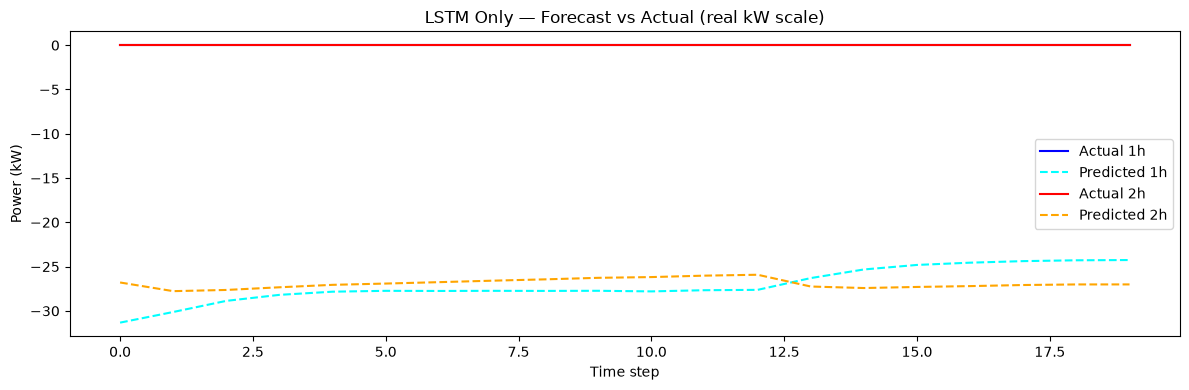

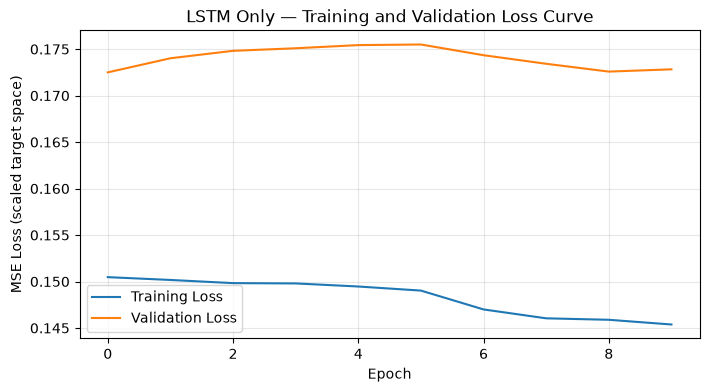

In [ ]:
plot_forecast_and_loss(
    model=lstm_only_model,
    test_loader=test_loader,
    target_scaler=target_scaler,
    train_losses=lstm_train_losses,
    val_losses=lstm_val_losses,
    title="LSTM Only",
    device=device,
)


LSTM Only

----- 1 Hour -----
RMSE : 618.945 kW
MAE  : 332.487 kW
R²   : 0.7604
NRMSE: 0.1630
MAPE : 55.54%


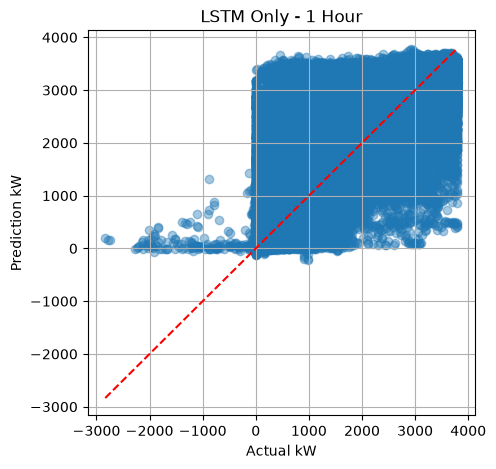

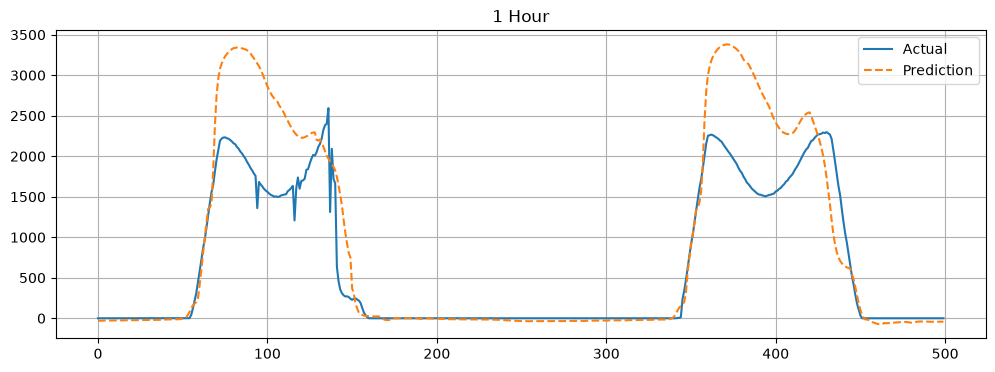

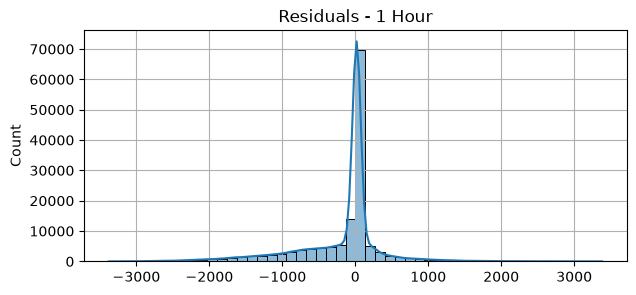


----- 2 Hour -----
RMSE : 667.242 kW
MAE  : 358.528 kW
R²   : 0.7216
NRMSE: 0.1757
MAPE : 57.33%


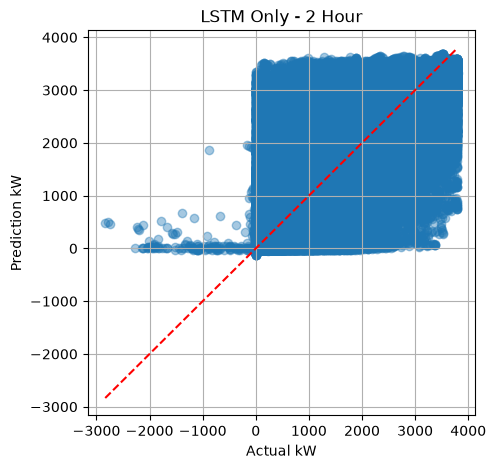

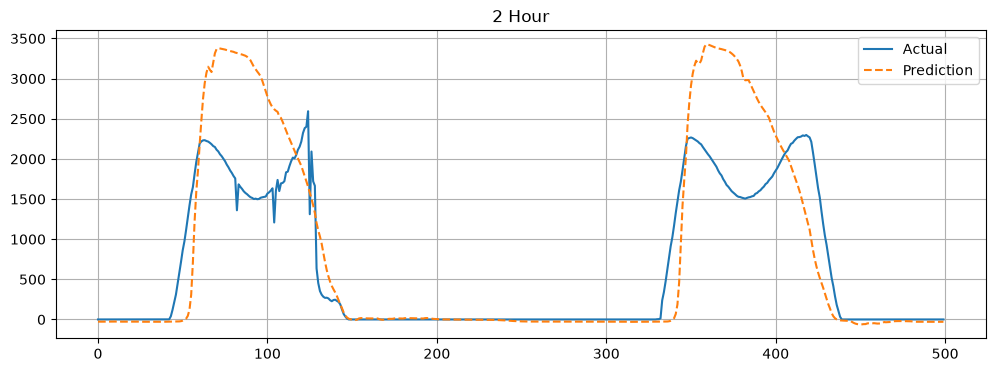

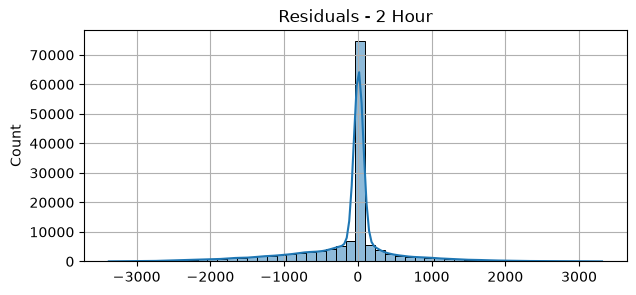

In [ ]:
lstm_results = evaluate_model(
    name="LSTM Only",
    model=lstm_only_model,
    X_test=test_dataset,   # lazy SlidingWindowDataset -- see evaluate_model's pytorch branch
    y_test_scaled=None,    # not needed on the Dataset path; targets come from the loader
    target_scaler=target_scaler,
    is_pytorch=True,
    device=device
)


## 11. CNN+LSTM hybrid

**Why 1D convolution along time, not 2D convolution over (time, features):**

A 2D kernel slides across *both* axes of the window, meaning it would combine
e.g. `temperature` at one timestep with `tracker_angle` at another purely
because those two columns happen to sit next to each other in
`lstm_feature_cols` -- an arbitrary ordering with no physical meaning. 2D
convolution only makes sense when *both* axes have real local structure (like
an image, where a pixel truly is spatially adjacent to its neighbors). Here,
only the time axis has that property -- timestep t and t+1 are genuinely
sequential; feature column 5 and column 6 are not "adjacent" in any
meaningful sense.

The standard fix (and what's used below): **1D convolution along time only**,
treating the 30 features at each timestep as *channels* -- the same way an
RGB image has 3 channels at every pixel. A conv layer is free to mix channels
in any combination at each time-position without needing them to be spatially
ordered, since channel-mixing isn't location-dependent the way pixel-adjacency
is. The conv stack acts as a fast local feature extractor along time (good at
picking up a sudden recent change) before the LSTM processes the resulting
sequence.

Note: this does **not** add any new forward-looking information -- it's still
working from exactly the same inputs as the plain LSTM. It may reduce lag on
transients already underway within the window, but it won't let the model
anticipate a cloud that hasn't shown up in the window yet. Worth reporting
either way -- if it doesn't meaningfully beat the plain LSTM, that's evidence
the earlier overshoot/lag issue is informational rather than architectural.

In [41]:
class CNNLSTMForecaster(nn.Module):
    def __init__(self, num_features, conv_channels=64, hidden_size=64):
        super().__init__()
        # Conv1d expects (batch, channels, time) -- channels = features here,
        # NOT a spatial axis. Padding=1 with kernel_size=3 keeps the time
        # dimension unchanged so the window length is preserved for the LSTM.
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=num_features, out_channels=conv_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=conv_channels, out_channels=conv_channels, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(
            input_size=conv_channels, hidden_size=hidden_size,
            batch_first=True, num_layers=2, dropout=0.2
        )
        self.linear = nn.Linear(hidden_size, 2)

    def forward(self, x):
        # x: (batch, window=24, features=num_features)
        x = x.permute(0, 2, 1)     # -> (batch, features, window) for Conv1d
        x = self.conv(x)            # -> (batch, conv_channels, window)
        x = x.permute(0, 2, 1)     # -> (batch, window, conv_channels) for LSTM
        out, _ = self.lstm(x)
        return self.linear(out[:, -1, :])


def build_cnn_lstm_and_optim(num_features, lr=0.001, weight_decay=1e-4):
    """Factory function -- fresh model instance before each training run,
    same reasoning as build_lstm_and_optim above."""
    model = CNNLSTMForecaster(num_features=num_features)
    optim = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optim, mode='min', factor=0.5, patience=5, min_lr=1e-6
    )
    return model, optim, scheduler


torch.manual_seed(SEED)
cnn_lstm_model, cnn_optim, cnn_scheduler = build_cnn_lstm_and_optim(num_features=len(lstm_feature_cols))
loss_fn = nn.MSELoss()


In [42]:
cnn_lstm_model, cnn_lstm_train_losses, cnn_lstm_val_losses = train_forecaster(
    model=cnn_lstm_model,
    optim=cnn_optim,
    scheduler=cnn_scheduler,
    train_loader=train_loader,   # same lazy SlidingWindowDataset loaders as the plain LSTM
    val_loader=val_loader,
    checkpoint_path="best_cnn_lstm_model.pth",
    epochs=50,
    patience=10,
    loss_fn=loss_fn,
)


No previous checkpoint found. Starting training from scratch.


Epoch 1/50: 100%|██████████| 4089/4089 [00:27<00:00, 149.74it/s, loss=0.00182] 


Epoch 01/50 | Train Loss: 0.203428 | Validation Loss: 0.282851
Learning rate: 0.0010000
Checkpoint saved at epoch 1 with Best Validation Loss: 0.282851


Epoch 2/50: 100%|██████████| 4089/4089 [00:25<00:00, 161.28it/s, loss=0.00114] 


Epoch 02/50 | Train Loss: 0.179378 | Validation Loss: 0.250025
Learning rate: 0.0010000
Checkpoint saved at epoch 2 with Best Validation Loss: 0.250025


Epoch 3/50: 100%|██████████| 4089/4089 [00:25<00:00, 160.72it/s, loss=0.00103] 


Epoch 03/50 | Train Loss: 0.173436 | Validation Loss: 0.244935
Learning rate: 0.0010000
Checkpoint saved at epoch 3 with Best Validation Loss: 0.244935


Epoch 4/50: 100%|██████████| 4089/4089 [00:25<00:00, 160.78it/s, loss=0.000857]


Epoch 04/50 | Train Loss: 0.170033 | Validation Loss: 0.237025
Learning rate: 0.0010000
Checkpoint saved at epoch 4 with Best Validation Loss: 0.237025


Epoch 5/50: 100%|██████████| 4089/4089 [00:30<00:00, 132.78it/s, loss=0.000754]


Epoch 05/50 | Train Loss: 0.167834 | Validation Loss: 0.230368
Learning rate: 0.0010000
Checkpoint saved at epoch 5 with Best Validation Loss: 0.230368


Epoch 6/50: 100%|██████████| 4089/4089 [00:28<00:00, 142.33it/s, loss=0.000727]


Epoch 06/50 | Train Loss: 0.165990 | Validation Loss: 0.229166
Learning rate: 0.0010000
Checkpoint saved at epoch 6 with Best Validation Loss: 0.229166


Epoch 7/50: 100%|██████████| 4089/4089 [00:32<00:00, 127.56it/s, loss=0.000633]


Epoch 07/50 | Train Loss: 0.164779 | Validation Loss: 0.220254
Learning rate: 0.0010000
Checkpoint saved at epoch 7 with Best Validation Loss: 0.220254


Epoch 8/50: 100%|██████████| 4089/4089 [00:36<00:00, 110.84it/s, loss=0.00108] 


Epoch 08/50 | Train Loss: 0.163789 | Validation Loss: 0.216863
Learning rate: 0.0010000
Checkpoint saved at epoch 8 with Best Validation Loss: 0.216863


Epoch 9/50: 100%|██████████| 4089/4089 [00:34<00:00, 118.71it/s, loss=0.00086] 


Epoch 09/50 | Train Loss: 0.162978 | Validation Loss: 0.214540
Learning rate: 0.0010000
Checkpoint saved at epoch 9 with Best Validation Loss: 0.214540


Epoch 10/50: 100%|██████████| 4089/4089 [00:29<00:00, 137.87it/s, loss=0.000624]


Epoch 10/50 | Train Loss: 0.162287 | Validation Loss: 0.209146
Learning rate: 0.0010000
Checkpoint saved at epoch 10 with Best Validation Loss: 0.209146


Epoch 11/50: 100%|██████████| 4089/4089 [00:30<00:00, 133.26it/s, loss=0.000902]


Epoch 11/50 | Train Loss: 0.161629 | Validation Loss: 0.210492
Learning rate: 0.0010000
No validation improvement (1/10)


Epoch 12/50: 100%|██████████| 4089/4089 [00:31<00:00, 129.73it/s, loss=0.000657]


Epoch 12/50 | Train Loss: 0.161154 | Validation Loss: 0.200875
Learning rate: 0.0010000
Checkpoint saved at epoch 12 with Best Validation Loss: 0.200875


Epoch 13/50: 100%|██████████| 4089/4089 [00:32<00:00, 125.94it/s, loss=0.000705]


Epoch 13/50 | Train Loss: 0.160629 | Validation Loss: 0.198926
Learning rate: 0.0010000
Checkpoint saved at epoch 13 with Best Validation Loss: 0.198926


Epoch 14/50: 100%|██████████| 4089/4089 [00:31<00:00, 130.41it/s, loss=0.000769]


Epoch 14/50 | Train Loss: 0.160320 | Validation Loss: 0.194583
Learning rate: 0.0010000
Checkpoint saved at epoch 14 with Best Validation Loss: 0.194583


Epoch 15/50: 100%|██████████| 4089/4089 [00:30<00:00, 132.25it/s, loss=0.000652]


Epoch 15/50 | Train Loss: 0.159820 | Validation Loss: 0.196826
Learning rate: 0.0010000
No validation improvement (1/10)


Epoch 16/50: 100%|██████████| 4089/4089 [00:30<00:00, 136.11it/s, loss=0.000566]


Epoch 16/50 | Train Loss: 0.160028 | Validation Loss: 0.197238
Learning rate: 0.0010000
No validation improvement (2/10)


Epoch 17/50: 100%|██████████| 4089/4089 [00:28<00:00, 141.55it/s, loss=0.000546]


Epoch 17/50 | Train Loss: 0.159895 | Validation Loss: 0.197855
Learning rate: 0.0010000
No validation improvement (3/10)


Epoch 18/50: 100%|██████████| 4089/4089 [00:29<00:00, 138.82it/s, loss=0.000665]


Epoch 18/50 | Train Loss: 0.158855 | Validation Loss: 0.198349
Learning rate: 0.0010000
No validation improvement (4/10)


Epoch 19/50: 100%|██████████| 4089/4089 [00:29<00:00, 138.65it/s, loss=0.000695]


Epoch 19/50 | Train Loss: 0.158489 | Validation Loss: 0.194444
Learning rate: 0.0010000
Checkpoint saved at epoch 19 with Best Validation Loss: 0.194444


Epoch 20/50: 100%|██████████| 4089/4089 [00:32<00:00, 124.47it/s, loss=0.000681]


Epoch 20/50 | Train Loss: 0.158289 | Validation Loss: 0.195319
Learning rate: 0.0010000
No validation improvement (1/10)


Epoch 21/50: 100%|██████████| 4089/4089 [00:33<00:00, 121.84it/s, loss=0.000632]


Epoch 21/50 | Train Loss: 0.158091 | Validation Loss: 0.191418
Learning rate: 0.0010000
Checkpoint saved at epoch 21 with Best Validation Loss: 0.191418


Epoch 22/50: 100%|██████████| 4089/4089 [00:31<00:00, 128.37it/s, loss=0.000752]


Epoch 22/50 | Train Loss: 0.157898 | Validation Loss: 0.192991
Learning rate: 0.0010000
No validation improvement (1/10)


Epoch 23/50: 100%|██████████| 4089/4089 [00:32<00:00, 126.88it/s, loss=0.000422]


Epoch 23/50 | Train Loss: 0.157607 | Validation Loss: 0.194774
Learning rate: 0.0010000
No validation improvement (2/10)


Epoch 24/50: 100%|██████████| 4089/4089 [00:31<00:00, 128.36it/s, loss=0.000691]


Epoch 24/50 | Train Loss: 0.157389 | Validation Loss: 0.195162
Learning rate: 0.0010000
No validation improvement (3/10)


Epoch 25/50: 100%|██████████| 4089/4089 [00:32<00:00, 127.40it/s, loss=0.000642]


Epoch 25/50 | Train Loss: 0.157135 | Validation Loss: 0.194913
Learning rate: 0.0010000
No validation improvement (4/10)


Epoch 26/50: 100%|██████████| 4089/4089 [00:32<00:00, 125.19it/s, loss=0.000545]


Epoch 26/50 | Train Loss: 0.156995 | Validation Loss: 0.194117
Learning rate: 0.0010000
No validation improvement (5/10)


Epoch 27/50: 100%|██████████| 4089/4089 [00:32<00:00, 124.95it/s, loss=0.00066] 


Epoch 27/50 | Train Loss: 0.156845 | Validation Loss: 0.193594
Learning rate: 0.0005000
No validation improvement (6/10)


Epoch 28/50: 100%|██████████| 4089/4089 [00:32<00:00, 126.29it/s, loss=0.000711]


Epoch 28/50 | Train Loss: 0.153175 | Validation Loss: 0.180140
Learning rate: 0.0005000
Checkpoint saved at epoch 28 with Best Validation Loss: 0.180140


Epoch 29/50: 100%|██████████| 4089/4089 [00:32<00:00, 124.68it/s, loss=0.000619]


Epoch 29/50 | Train Loss: 0.152493 | Validation Loss: 0.183472
Learning rate: 0.0005000
No validation improvement (1/10)


Epoch 30/50: 100%|██████████| 4089/4089 [00:32<00:00, 125.78it/s, loss=0.000492]


Epoch 30/50 | Train Loss: 0.152314 | Validation Loss: 0.183485
Learning rate: 0.0005000
No validation improvement (2/10)


Epoch 31/50: 100%|██████████| 4089/4089 [00:32<00:00, 126.17it/s, loss=0.000482]


Epoch 31/50 | Train Loss: 0.151717 | Validation Loss: 0.183988
Learning rate: 0.0005000
No validation improvement (3/10)


Epoch 32/50: 100%|██████████| 4089/4089 [00:33<00:00, 123.88it/s, loss=0.000577]


Epoch 32/50 | Train Loss: 0.151790 | Validation Loss: 0.184502
Learning rate: 0.0005000
No validation improvement (4/10)


Epoch 33/50: 100%|██████████| 4089/4089 [00:32<00:00, 127.36it/s, loss=0.000643]


Epoch 33/50 | Train Loss: 0.151392 | Validation Loss: 0.184156
Learning rate: 0.0005000
No validation improvement (5/10)


Epoch 34/50: 100%|██████████| 4089/4089 [00:32<00:00, 125.80it/s, loss=0.000623]


Epoch 34/50 | Train Loss: 0.151291 | Validation Loss: 0.183709
Learning rate: 0.0002500
No validation improvement (6/10)


Epoch 35/50: 100%|██████████| 4089/4089 [00:32<00:00, 126.13it/s, loss=0.000477]


Epoch 35/50 | Train Loss: 0.149509 | Validation Loss: 0.179006
Learning rate: 0.0002500
Checkpoint saved at epoch 35 with Best Validation Loss: 0.179006


Epoch 36/50: 100%|██████████| 4089/4089 [00:32<00:00, 125.48it/s, loss=0.000521]


Epoch 36/50 | Train Loss: 0.148787 | Validation Loss: 0.179492
Learning rate: 0.0002500
No validation improvement (1/10)


Epoch 37/50: 100%|██████████| 4089/4089 [00:32<00:00, 127.45it/s, loss=0.000519]


Epoch 37/50 | Train Loss: 0.148583 | Validation Loss: 0.179145
Learning rate: 0.0002500
No validation improvement (2/10)


Epoch 38/50: 100%|██████████| 4089/4089 [00:32<00:00, 125.82it/s, loss=0.000449]


Epoch 38/50 | Train Loss: 0.148432 | Validation Loss: 0.179870
Learning rate: 0.0002500
No validation improvement (3/10)


Epoch 39/50: 100%|██████████| 4089/4089 [00:32<00:00, 126.24it/s, loss=0.000613]


Epoch 39/50 | Train Loss: 0.148131 | Validation Loss: 0.179233
Learning rate: 0.0002500
No validation improvement (4/10)


Epoch 40/50: 100%|██████████| 4089/4089 [00:32<00:00, 125.97it/s, loss=0.000498]


Epoch 40/50 | Train Loss: 0.148006 | Validation Loss: 0.179389
Learning rate: 0.0002500
No validation improvement (5/10)


Epoch 41/50: 100%|██████████| 4089/4089 [00:32<00:00, 124.27it/s, loss=0.000366]


Epoch 41/50 | Train Loss: 0.147874 | Validation Loss: 0.179632
Learning rate: 0.0001250
No validation improvement (6/10)


Epoch 42/50: 100%|██████████| 4089/4089 [00:32<00:00, 126.29it/s, loss=0.000471]


Epoch 42/50 | Train Loss: 0.146938 | Validation Loss: 0.177532
Learning rate: 0.0001250
Checkpoint saved at epoch 42 with Best Validation Loss: 0.177532


Epoch 43/50: 100%|██████████| 4089/4089 [00:32<00:00, 125.08it/s, loss=0.000363]


Epoch 43/50 | Train Loss: 0.146298 | Validation Loss: 0.177364
Learning rate: 0.0001250
Checkpoint saved at epoch 43 with Best Validation Loss: 0.177364


Epoch 44/50: 100%|██████████| 4089/4089 [00:28<00:00, 142.29it/s, loss=0.000442]


Epoch 44/50 | Train Loss: 0.146097 | Validation Loss: 0.177123
Learning rate: 0.0001250
Checkpoint saved at epoch 44 with Best Validation Loss: 0.177123


Epoch 45/50: 100%|██████████| 4089/4089 [00:26<00:00, 153.34it/s, loss=0.000501]


Epoch 45/50 | Train Loss: 0.145953 | Validation Loss: 0.177327
Learning rate: 0.0001250
No validation improvement (1/10)


Epoch 46/50: 100%|██████████| 4089/4089 [00:26<00:00, 154.35it/s, loss=0.00045] 


Epoch 46/50 | Train Loss: 0.145796 | Validation Loss: 0.177447
Learning rate: 0.0001250
No validation improvement (2/10)


Epoch 47/50: 100%|██████████| 4089/4089 [00:27<00:00, 151.30it/s, loss=0.000358]


Epoch 47/50 | Train Loss: 0.145682 | Validation Loss: 0.177574
Learning rate: 0.0001250
No validation improvement (3/10)


Epoch 48/50: 100%|██████████| 4089/4089 [00:26<00:00, 151.63it/s, loss=0.000475]


Epoch 48/50 | Train Loss: 0.145532 | Validation Loss: 0.176912
Learning rate: 0.0001250
Checkpoint saved at epoch 48 with Best Validation Loss: 0.176912


Epoch 49/50: 100%|██████████| 4089/4089 [00:26<00:00, 151.68it/s, loss=0.000408]


Epoch 49/50 | Train Loss: 0.145368 | Validation Loss: 0.177442
Learning rate: 0.0001250
No validation improvement (1/10)


Epoch 50/50: 100%|██████████| 4089/4089 [51:00<00:00,  1.34it/s, loss=0.000417]   


Epoch 50/50 | Train Loss: 0.145316 | Validation Loss: 0.177071
Learning rate: 0.0001250
No validation improvement (2/10)
Best model loaded from epoch 48


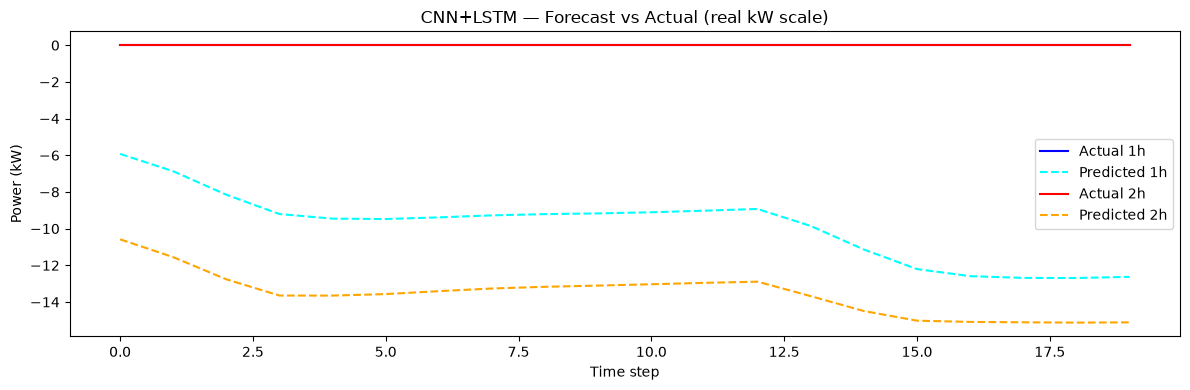

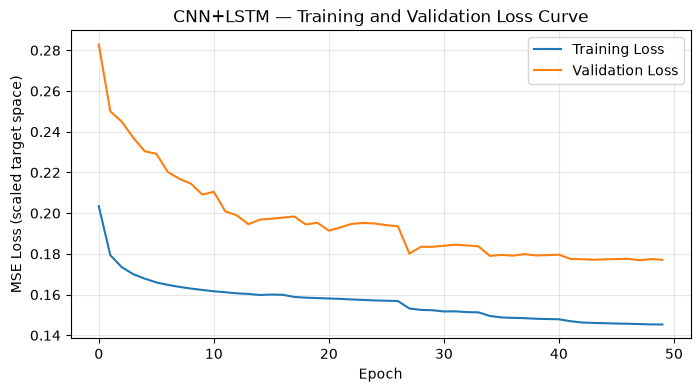

In [43]:
plot_forecast_and_loss(
    model=cnn_lstm_model,
    test_loader=test_loader,
    target_scaler=target_scaler,
    train_losses=cnn_lstm_train_losses,
    val_losses=cnn_lstm_val_losses,
    title="CNN+LSTM",
    device=device,
)


CNN+LSTM

----- 1 Hour -----
RMSE : 580.979 kW
MAE  : 292.934 kW
R²   : 0.7889
NRMSE: 0.1530
MAPE : 46.52%


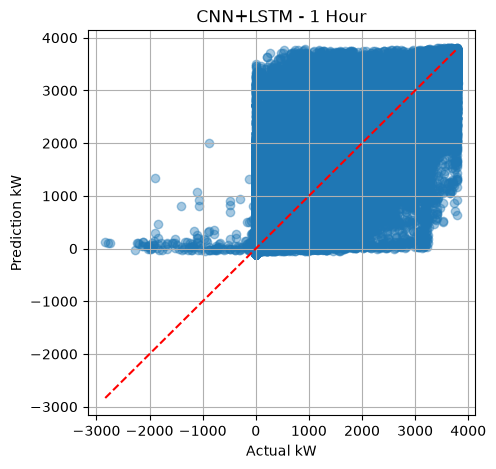

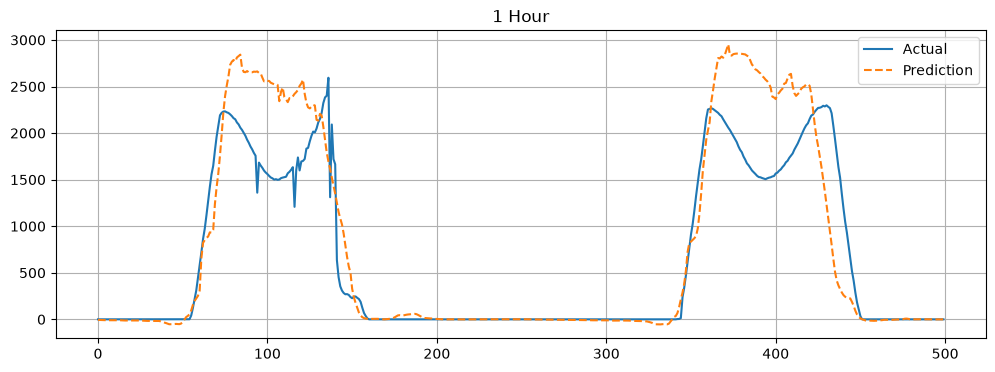

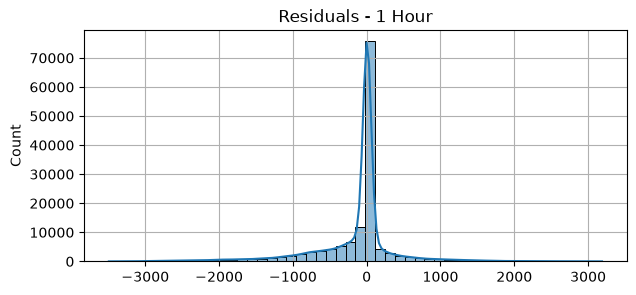


----- 2 Hour -----
RMSE : 665.763 kW
MAE  : 341.780 kW
R²   : 0.7228
NRMSE: 0.1753
MAPE : 51.52%


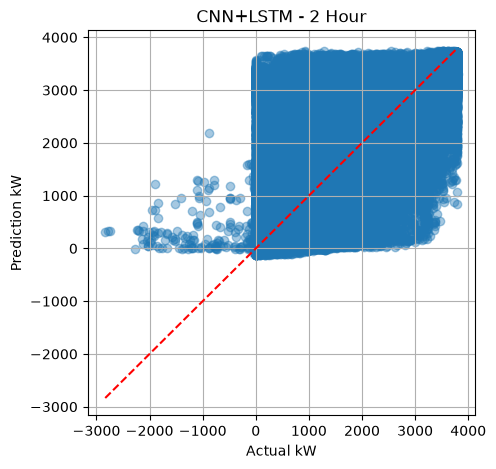

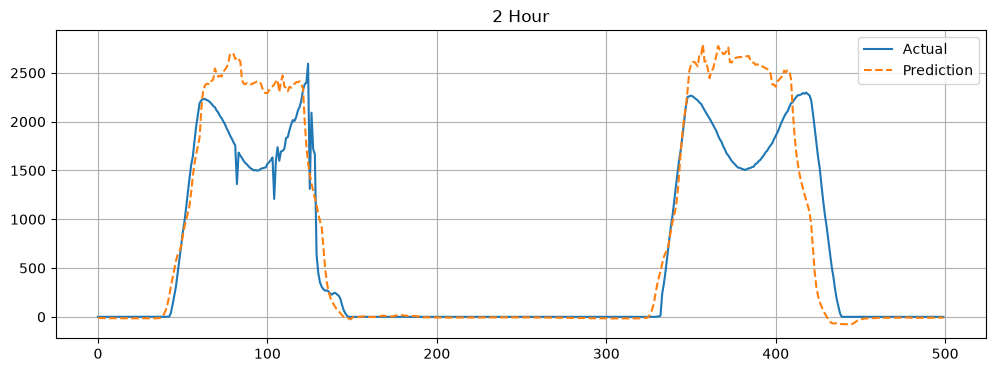

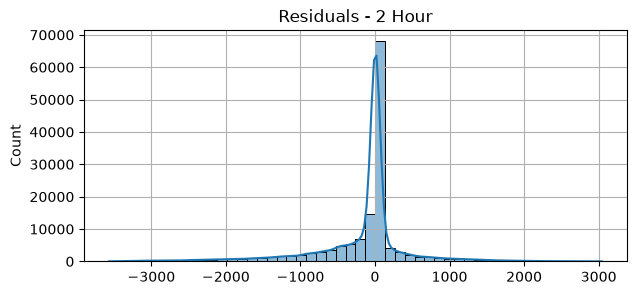

In [44]:
cnn_lstm_results = evaluate_model(
    name="CNN+LSTM",
    model=cnn_lstm_model,
    X_test=test_dataset,
    y_test_scaled=None,
    target_scaler=target_scaler,
    is_pytorch=True,
    device=device
)


## 12. Ablation: CNN(2D)+LSTM -- does convolving over features actually hurt?

Section 11 argued that 2D convolution over (time × features) is the wrong
tool, since the feature axis has no real local structure the way time does.
That argument is worth testing empirically rather than just asserting.

**Design, to keep this a fair, isolated comparison:** the 2D version uses the
same kernel count (64 channels) and produces the same shape LSTM input
(`batch, window, 64`) as the 1D version above -- the *only* thing that
differs between the two models is whether the convolution kernel is allowed
to slide across the feature axis (2D) or only across time (1D, Section 11).
To make that possible, the 2D version pools away the feature axis after
convolving over it (`AdaptiveAvgPool2d` collapsing it to size 1), so both
architectures hand the LSTM an input of identical shape and the comparison
isolates exactly one variable: which axes the kernel treated as spatially
local.

In [ ]:
class CNN2DLSTMForecaster(nn.Module):
    def __init__(self, num_features, conv_channels=64, hidden_size=64):
        super().__init__()
        # Conv2d slides over BOTH axes: (window, num_features) treated as a
        # single-channel "image" -- this is deliberately the version we expect
        # to underperform, since num_features has no real spatial structure.
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=conv_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=conv_channels, out_channels=conv_channels, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        # Collapse the feature axis down to size 1 so the LSTM receives the
        # same (batch, window, conv_channels) shape as the 1D version --
        # keeps the comparison to "which axes were convolved", nothing else.
        self.pool = nn.AdaptiveAvgPool2d((None, 1))
        self.lstm = nn.LSTM(
            input_size=conv_channels, hidden_size=hidden_size,
            batch_first=True, num_layers=2, dropout=0.2
        )
        self.linear = nn.Linear(hidden_size, 2)

    def forward(self, x):
        # x: (batch, window=24, features=num_features)
        x = x.unsqueeze(1)          # -> (batch, 1, window, features) -- single "image" channel
        x = self.conv(x)             # -> (batch, conv_channels, window, features)
        x = self.pool(x)             # -> (batch, conv_channels, window, 1)
        x = x.squeeze(-1)            # -> (batch, conv_channels, window)
        x = x.permute(0, 2, 1)      # -> (batch, window, conv_channels) for LSTM
        out, _ = self.lstm(x)
        return self.linear(out[:, -1, :])


def build_cnn2d_lstm_and_optim(num_features, lr=0.001, weight_decay=1e-4):
    model = CNN2DLSTMForecaster(num_features=num_features)
    optim = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optim, mode='min', factor=0.5, patience=5, min_lr=1e-6
    )
    return model, optim, scheduler


torch.manual_seed(SEED)
cnn2d_lstm_model, cnn2d_optim, cnn2d_scheduler = build_cnn2d_lstm_and_optim(num_features=len(lstm_feature_cols))


In [ ]:
cnn2d_lstm_model, cnn2d_lstm_train_losses, cnn2d_lstm_val_losses = train_forecaster(
    model=cnn2d_lstm_model,
    optim=cnn2d_optim,
    scheduler=cnn2d_scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    checkpoint_path="best_cnn2d_lstm_model.pth",
    epochs=50,
    patience=10,
    loss_fn=loss_fn,
)


No previous checkpoint found. Starting training from scratch.


Epoch 1/50: 100%|██████████| 4089/4089 [00:53<00:00, 76.32it/s, loss=0.348]   


Epoch 01/50 | Train Loss: 0.374923 | Validation Loss: 1.358388
Learning rate: 0.0010000
Checkpoint saved at epoch 1 with Best Validation Loss: 1.358388


Epoch 2/50: 100%|██████████| 4089/4089 [00:54<00:00, 74.81it/s, loss=0.117]   


Epoch 02/50 | Train Loss: 0.279011 | Validation Loss: 0.901069
Learning rate: 0.0010000
Checkpoint saved at epoch 2 with Best Validation Loss: 0.901069


Epoch 3/50: 100%|██████████| 4089/4089 [00:54<00:00, 75.13it/s, loss=0.34]    


Epoch 03/50 | Train Loss: 0.245727 | Validation Loss: 0.912632
Learning rate: 0.0010000
No validation improvement (1/10)


Epoch 4/50: 100%|██████████| 4089/4089 [00:54<00:00, 75.25it/s, loss=0.0284]  


Epoch 04/50 | Train Loss: 0.229010 | Validation Loss: 0.623714
Learning rate: 0.0010000
Checkpoint saved at epoch 4 with Best Validation Loss: 0.623714


Epoch 5/50: 100%|██████████| 4089/4089 [00:55<00:00, 74.21it/s, loss=0.00759] 


Epoch 05/50 | Train Loss: 0.221025 | Validation Loss: 0.540036
Learning rate: 0.0010000
Checkpoint saved at epoch 5 with Best Validation Loss: 0.540036


Epoch 6/50: 100%|██████████| 4089/4089 [00:55<00:00, 73.29it/s, loss=0.00536] 


Epoch 06/50 | Train Loss: 0.214131 | Validation Loss: 0.444450
Learning rate: 0.0010000
Checkpoint saved at epoch 6 with Best Validation Loss: 0.444450


Epoch 7/50: 100%|██████████| 4089/4089 [00:58<00:00, 70.07it/s, loss=0.00577] 


Epoch 07/50 | Train Loss: 0.210023 | Validation Loss: 0.439468
Learning rate: 0.0010000
Checkpoint saved at epoch 7 with Best Validation Loss: 0.439468


Epoch 8/50: 100%|██████████| 4089/4089 [00:56<00:00, 72.57it/s, loss=0.0051]  


Epoch 08/50 | Train Loss: 0.207446 | Validation Loss: 0.400361
Learning rate: 0.0010000
Checkpoint saved at epoch 8 with Best Validation Loss: 0.400361


Epoch 9/50: 100%|██████████| 4089/4089 [00:57<00:00, 70.79it/s, loss=0.00757] 


Epoch 09/50 | Train Loss: 0.203107 | Validation Loss: 0.423552
Learning rate: 0.0010000
No validation improvement (1/10)


Epoch 10/50: 100%|██████████| 4089/4089 [00:56<00:00, 71.83it/s, loss=0.00449] 


Epoch 10/50 | Train Loss: 0.201494 | Validation Loss: 0.417808
Learning rate: 0.0010000
No validation improvement (2/10)


Epoch 11/50: 100%|██████████| 4089/4089 [00:57<00:00, 71.25it/s, loss=0.00356] 


Epoch 11/50 | Train Loss: 0.198786 | Validation Loss: 0.421261
Learning rate: 0.0010000
No validation improvement (3/10)


Epoch 12/50: 100%|██████████| 4089/4089 [00:58<00:00, 69.42it/s, loss=0.00489] 


Epoch 12/50 | Train Loss: 0.196840 | Validation Loss: 0.408795
Learning rate: 0.0010000
No validation improvement (4/10)


Epoch 13/50: 100%|██████████| 4089/4089 [00:58<00:00, 69.93it/s, loss=0.00338] 


Epoch 13/50 | Train Loss: 0.194725 | Validation Loss: 0.443001
Learning rate: 0.0010000
No validation improvement (5/10)


Epoch 14/50: 100%|██████████| 4089/4089 [00:58<00:00, 69.58it/s, loss=0.00355] 


Epoch 14/50 | Train Loss: 0.194035 | Validation Loss: 0.427522
Learning rate: 0.0005000
No validation improvement (6/10)


Epoch 15/50: 100%|██████████| 4089/4089 [00:58<00:00, 69.33it/s, loss=0.00444] 


Epoch 15/50 | Train Loss: 0.187762 | Validation Loss: 0.313550
Learning rate: 0.0005000
Checkpoint saved at epoch 15 with Best Validation Loss: 0.313550


Epoch 16/50: 100%|██████████| 4089/4089 [00:59<00:00, 68.60it/s, loss=0.00389] 


Epoch 16/50 | Train Loss: 0.184881 | Validation Loss: 0.312419
Learning rate: 0.0005000
Checkpoint saved at epoch 16 with Best Validation Loss: 0.312419


Epoch 17/50: 100%|██████████| 4089/4089 [01:00<00:00, 68.13it/s, loss=0.004]   


Epoch 17/50 | Train Loss: 0.184719 | Validation Loss: 0.317719
Learning rate: 0.0005000
No validation improvement (1/10)


Epoch 18/50: 100%|██████████| 4089/4089 [00:58<00:00, 70.44it/s, loss=0.00258] 


Epoch 18/50 | Train Loss: 0.184250 | Validation Loss: 0.310091
Learning rate: 0.0005000
Checkpoint saved at epoch 18 with Best Validation Loss: 0.310091


Epoch 19/50: 100%|██████████| 4089/4089 [00:56<00:00, 71.79it/s, loss=0.0035]  


Epoch 19/50 | Train Loss: 0.183942 | Validation Loss: 0.314484
Learning rate: 0.0005000
No validation improvement (1/10)


Epoch 20/50: 100%|██████████| 4089/4089 [00:56<00:00, 72.28it/s, loss=0.00258] 


Epoch 20/50 | Train Loss: 0.183417 | Validation Loss: 0.337943
Learning rate: 0.0005000
No validation improvement (2/10)


Epoch 21/50: 100%|██████████| 4089/4089 [00:56<00:00, 72.14it/s, loss=0.00312] 


Epoch 21/50 | Train Loss: 0.182788 | Validation Loss: 0.313348
Learning rate: 0.0005000
No validation improvement (3/10)


Epoch 22/50: 100%|██████████| 4089/4089 [00:56<00:00, 72.27it/s, loss=0.0025]  


Epoch 22/50 | Train Loss: 0.183002 | Validation Loss: 0.326142
Learning rate: 0.0005000
No validation improvement (4/10)


Epoch 23/50: 100%|██████████| 4089/4089 [00:56<00:00, 72.94it/s, loss=0.00232] 


Epoch 23/50 | Train Loss: 0.182435 | Validation Loss: 0.309554
Learning rate: 0.0005000
Checkpoint saved at epoch 23 with Best Validation Loss: 0.309554


Epoch 24/50: 100%|██████████| 4089/4089 [00:55<00:00, 73.24it/s, loss=0.0024]  


Epoch 24/50 | Train Loss: 0.182128 | Validation Loss: 0.299762
Learning rate: 0.0005000
Checkpoint saved at epoch 24 with Best Validation Loss: 0.299762


Epoch 25/50: 100%|██████████| 4089/4089 [00:55<00:00, 73.21it/s, loss=0.00247] 


Epoch 25/50 | Train Loss: 0.182213 | Validation Loss: 0.308024
Learning rate: 0.0005000
No validation improvement (1/10)


Epoch 26/50: 100%|██████████| 4089/4089 [00:55<00:00, 73.53it/s, loss=0.002]   


Epoch 26/50 | Train Loss: 0.181568 | Validation Loss: 0.298530
Learning rate: 0.0005000
Checkpoint saved at epoch 26 with Best Validation Loss: 0.298530


Epoch 27/50: 100%|██████████| 4089/4089 [00:55<00:00, 73.69it/s, loss=0.00276] 


Epoch 27/50 | Train Loss: 0.181604 | Validation Loss: 0.310064
Learning rate: 0.0005000
No validation improvement (1/10)


Epoch 28/50: 100%|██████████| 4089/4089 [00:55<00:00, 73.94it/s, loss=0.0022]  


Epoch 28/50 | Train Loss: 0.180912 | Validation Loss: 0.294930
Learning rate: 0.0005000
Checkpoint saved at epoch 28 with Best Validation Loss: 0.294930


Epoch 29/50: 100%|██████████| 4089/4089 [00:55<00:00, 73.65it/s, loss=0.00398] 


Epoch 29/50 | Train Loss: 0.180516 | Validation Loss: 0.306738
Learning rate: 0.0005000
No validation improvement (1/10)


Epoch 30/50: 100%|██████████| 4089/4089 [00:55<00:00, 73.21it/s, loss=0.00222] 


Epoch 30/50 | Train Loss: 0.180152 | Validation Loss: 0.297821
Learning rate: 0.0005000
No validation improvement (2/10)


Epoch 31/50: 100%|██████████| 4089/4089 [00:55<00:00, 73.25it/s, loss=0.00294] 


Epoch 31/50 | Train Loss: 0.180423 | Validation Loss: 0.296226
Learning rate: 0.0005000
No validation improvement (3/10)


Epoch 32/50: 100%|██████████| 4089/4089 [00:56<00:00, 73.01it/s, loss=0.00187] 


Epoch 32/50 | Train Loss: 0.179834 | Validation Loss: 0.298259
Learning rate: 0.0005000
No validation improvement (4/10)


Epoch 33/50: 100%|██████████| 4089/4089 [00:55<00:00, 73.61it/s, loss=0.00179] 


Epoch 33/50 | Train Loss: 0.179595 | Validation Loss: 0.288406
Learning rate: 0.0005000
Checkpoint saved at epoch 33 with Best Validation Loss: 0.288406


Epoch 34/50: 100%|██████████| 4089/4089 [00:56<00:00, 72.57it/s, loss=0.0018]  


Epoch 34/50 | Train Loss: 0.179411 | Validation Loss: 0.284686
Learning rate: 0.0005000
Checkpoint saved at epoch 34 with Best Validation Loss: 0.284686


Epoch 35/50: 100%|██████████| 4089/4089 [00:55<00:00, 73.37it/s, loss=0.00361] 


Epoch 35/50 | Train Loss: 0.179669 | Validation Loss: 0.326614
Learning rate: 0.0005000
No validation improvement (1/10)


Epoch 36/50: 100%|██████████| 4089/4089 [00:56<00:00, 72.68it/s, loss=0.00297] 


Epoch 36/50 | Train Loss: 0.178959 | Validation Loss: 0.295068
Learning rate: 0.0005000
No validation improvement (2/10)


Epoch 37/50: 100%|██████████| 4089/4089 [00:56<00:00, 72.17it/s, loss=0.0025]  


Epoch 37/50 | Train Loss: 0.179205 | Validation Loss: 0.281653
Learning rate: 0.0005000
Checkpoint saved at epoch 37 with Best Validation Loss: 0.281653


Epoch 38/50: 100%|██████████| 4089/4089 [00:56<00:00, 72.43it/s, loss=0.0026]  


Epoch 38/50 | Train Loss: 0.178905 | Validation Loss: 0.283509
Learning rate: 0.0005000
No validation improvement (1/10)


Epoch 39/50: 100%|██████████| 4089/4089 [00:56<00:00, 72.12it/s, loss=0.00231] 


Epoch 39/50 | Train Loss: 0.178770 | Validation Loss: 0.286310
Learning rate: 0.0005000
No validation improvement (2/10)


Epoch 40/50: 100%|██████████| 4089/4089 [00:58<00:00, 69.67it/s, loss=0.00214] 


Epoch 40/50 | Train Loss: 0.178721 | Validation Loss: 0.281073
Learning rate: 0.0005000
Checkpoint saved at epoch 40 with Best Validation Loss: 0.281073


Epoch 41/50: 100%|██████████| 4089/4089 [00:59<00:00, 68.16it/s, loss=0.00214] 


Epoch 41/50 | Train Loss: 0.178598 | Validation Loss: 0.282074
Learning rate: 0.0005000
No validation improvement (1/10)


Epoch 42/50: 100%|██████████| 4089/4089 [00:56<00:00, 72.28it/s, loss=0.00201] 


Epoch 42/50 | Train Loss: 0.178610 | Validation Loss: 0.287440
Learning rate: 0.0005000
No validation improvement (2/10)


Epoch 43/50: 100%|██████████| 4089/4089 [00:56<00:00, 71.80it/s, loss=0.00211] 


Epoch 43/50 | Train Loss: 0.178553 | Validation Loss: 0.274313
Learning rate: 0.0005000
Checkpoint saved at epoch 43 with Best Validation Loss: 0.274313


Epoch 44/50: 100%|██████████| 4089/4089 [00:57<00:00, 70.63it/s, loss=0.00141] 


Epoch 44/50 | Train Loss: 0.178104 | Validation Loss: 0.275915
Learning rate: 0.0005000
No validation improvement (1/10)


Epoch 45/50: 100%|██████████| 4089/4089 [00:58<00:00, 69.47it/s, loss=0.00107] 


Epoch 45/50 | Train Loss: 0.177893 | Validation Loss: 0.274279
Learning rate: 0.0005000
Checkpoint saved at epoch 45 with Best Validation Loss: 0.274279


Epoch 46/50: 100%|██████████| 4089/4089 [00:58<00:00, 69.58it/s, loss=0.00126] 


Epoch 46/50 | Train Loss: 0.177948 | Validation Loss: 0.271348
Learning rate: 0.0005000
Checkpoint saved at epoch 46 with Best Validation Loss: 0.271348


Epoch 47/50: 100%|██████████| 4089/4089 [00:58<00:00, 69.73it/s, loss=0.00167] 


Epoch 47/50 | Train Loss: 0.177780 | Validation Loss: 0.272044
Learning rate: 0.0005000
No validation improvement (1/10)


Epoch 48/50: 100%|██████████| 4089/4089 [00:58<00:00, 69.51it/s, loss=0.00112] 


Epoch 48/50 | Train Loss: 0.177478 | Validation Loss: 0.272550
Learning rate: 0.0005000
No validation improvement (2/10)


Epoch 49/50: 100%|██████████| 4089/4089 [00:58<00:00, 69.47it/s, loss=0.000842]


Epoch 49/50 | Train Loss: 0.177522 | Validation Loss: 0.271001
Learning rate: 0.0005000
Checkpoint saved at epoch 49 with Best Validation Loss: 0.271001


Epoch 50/50: 100%|██████████| 4089/4089 [00:59<00:00, 69.20it/s, loss=0.00133] 


Epoch 50/50 | Train Loss: 0.177193 | Validation Loss: 0.270438
Learning rate: 0.0005000
Checkpoint saved at epoch 50 with Best Validation Loss: 0.270438
Best model loaded from epoch 50


C:\Users\aidim\AppData\Local\Temp\ipykernel_24340\2723272554.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=devi

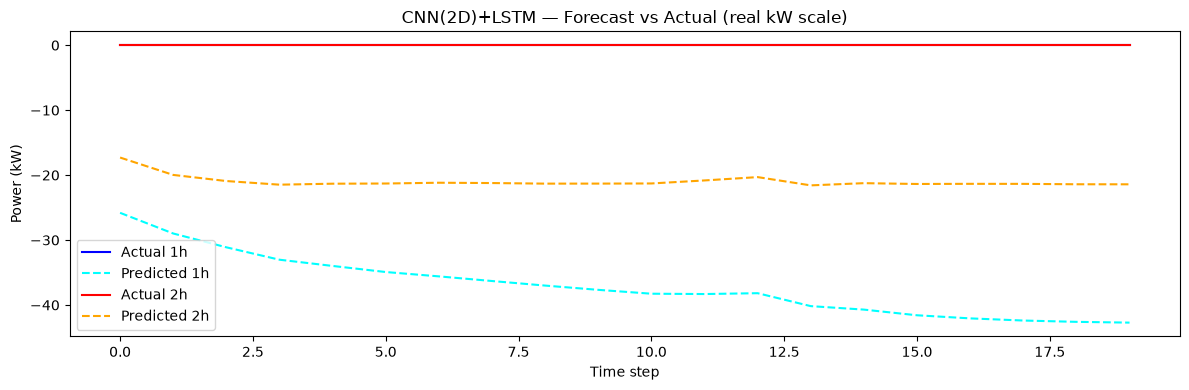

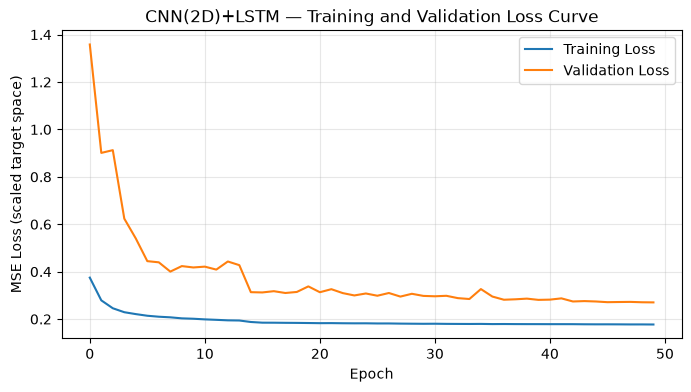

In [ ]:
plot_forecast_and_loss(
    model=cnn2d_lstm_model,
    test_loader=test_loader,
    target_scaler=target_scaler,
    train_losses=cnn2d_lstm_train_losses,
    val_losses=cnn2d_lstm_val_losses,
    title="CNN(2D)+LSTM",
    device=device,
)


CNN(2D)+LSTM

----- 1 Hour -----
RMSE : 863.631 kW
MAE  : 506.065 kW
R²   : 0.5335
NRMSE: 0.2274
MAPE : 55.63%


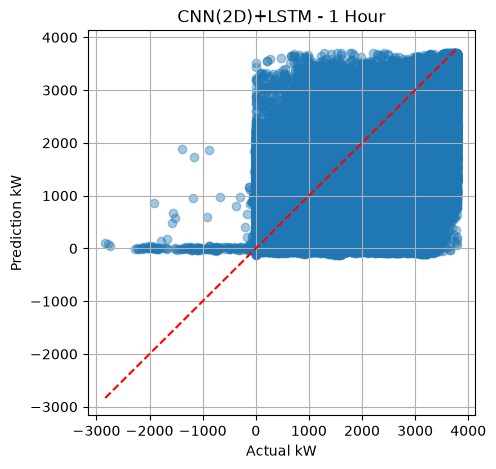

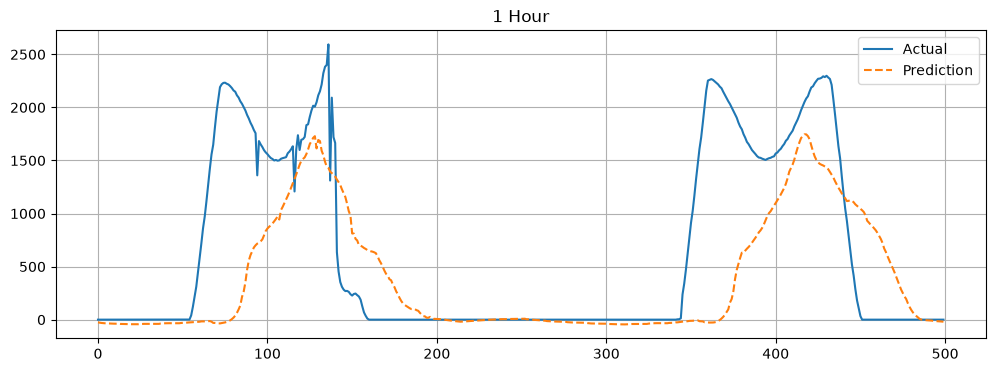

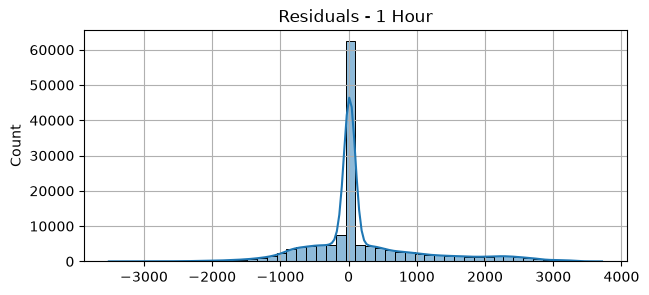


----- 2 Hour -----
RMSE : 1073.498 kW
MAE  : 625.751 kW
R²   : 0.2793
NRMSE: 0.2826
MAPE : 67.65%


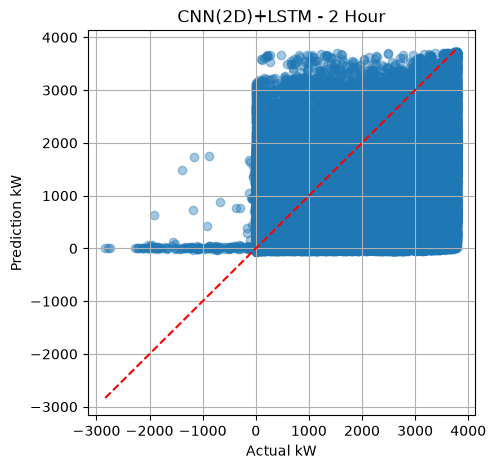

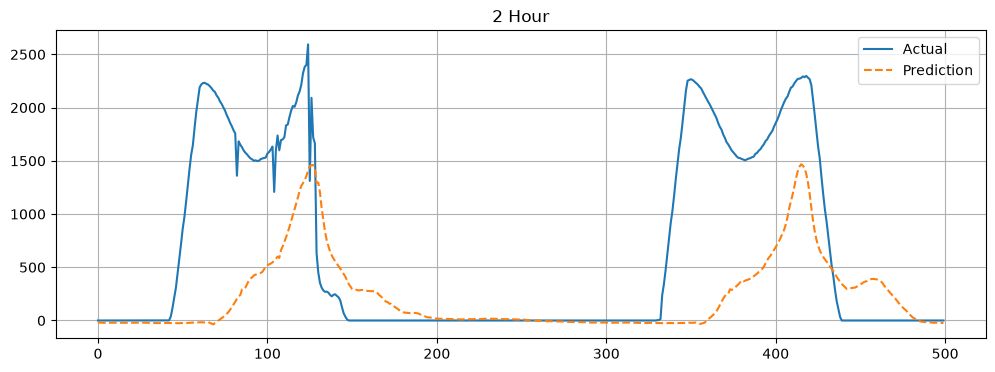

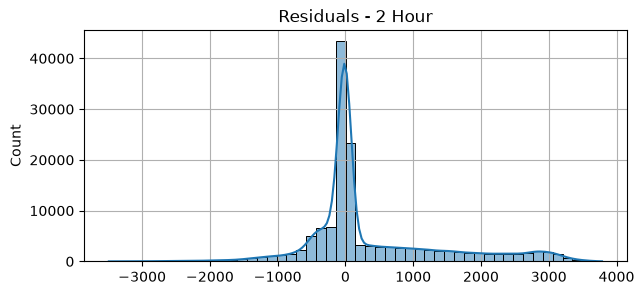

In [ ]:
cnn2d_lstm_results = evaluate_model(
    name="CNN(2D)+LSTM",
    model=cnn2d_lstm_model,
    X_test=test_dataset,
    y_test_scaled=None,
    target_scaler=target_scaler,
    is_pytorch=True,
    device=device
)


**Reading this result:** if `CNN(2D)+LSTM` performs on par with or better
than `CNN+LSTM` (1D), that would actually undercut the axis argument from
Section 11 and is worth reporting honestly rather than dismissed. If it
performs worse -- the expected outcome given the reasoning above -- that's
direct empirical evidence for the "feature axis has no real locality"
argument, not just a theoretical one.

## 13. Persistence baseline

The standard baseline in solar forecasting: predict that AC power at
t+1h/t+2h will simply equal AC power right now (t). Any model that can't
beat this has learned nothing beyond "assume no change" — this is usually a
required comparison in the literature, not just a sanity check.

Implemented as a tiny `.predict()`-style wrapper so it plugs into
`evaluate_model()` exactly like the sklearn models above, with no changes
needed to `evaluate_model` itself.

d:\AI_and_Python\Local_Notebooks\pvdaq_db\pvdaq_db\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Persistence (t = t)

----- 1 Hour -----
RMSE : 691.739 kW
MAE  : 321.087 kW
R²   : 0.7007
NRMSE: 0.1821
MAPE : 47.81%


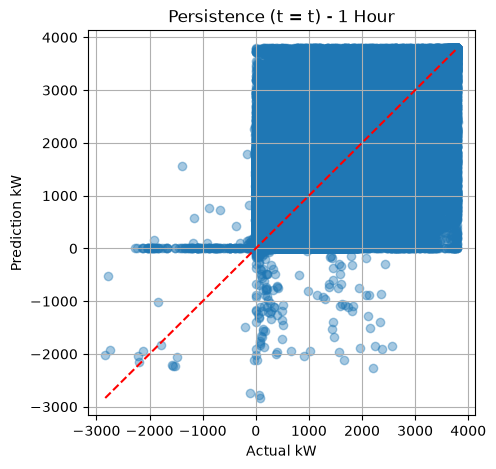

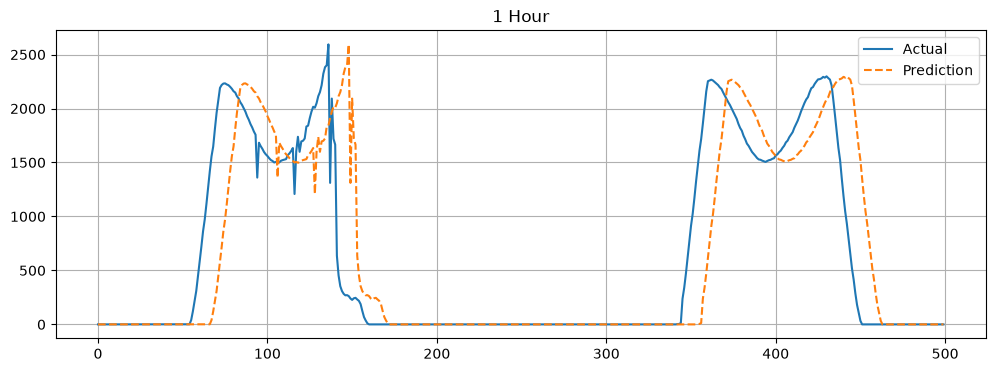

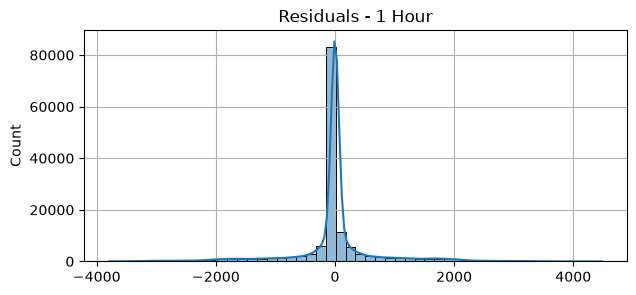


----- 2 Hour -----
RMSE : 1000.311 kW
MAE  : 521.060 kW
R²   : 0.3742
NRMSE: 0.2634
MAPE : 62.98%


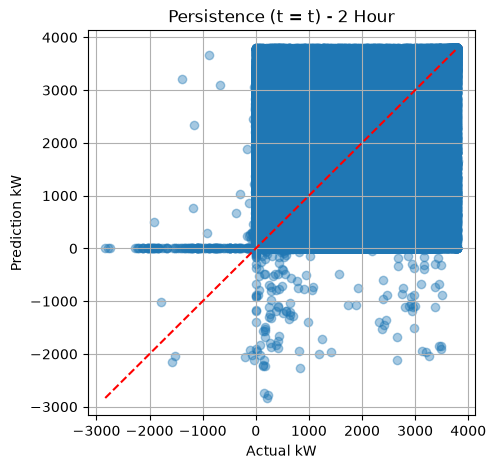

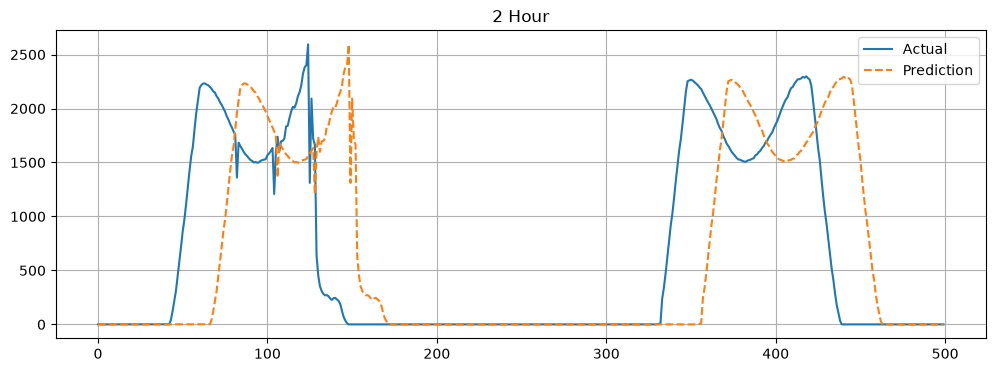

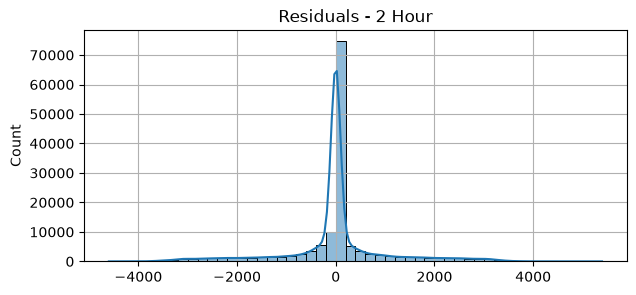

In [45]:
class PersistenceModel:
    """predict(X) where X is the *real* (unscaled) current AC power in kW.
    Returns the same current value for both the 1h and 2h horizon, already
    scaled via target_scaler so evaluate_model's inverse_transform step
    undoes it symmetrically and everything ends up back in real kW.
    """
    def __init__(self, target_scaler):
        self.target_scaler = target_scaler

    def predict(self, X):
        X = np.asarray(X).reshape(-1, 1)
        y_pred_real = np.hstack([X, X])  # same value predicted for both horizons
        return self.target_scaler.transform(y_pred_real)


# Real (unscaled) current AC power, aligned row-for-row with X_test_flat/y_test_flat
# (test_df_flat and test_flat_scaled share the same row order/index).
current_power_test = (
    test_df_flat['inverter_1_ac_power_(kw)_inv_150143'] +
    test_df_flat['inverter_2_ac_power_(kw)_inv_150144']
).values

persistence_model = PersistenceModel(target_scaler)

persistence_results = evaluate_model(
    name="Persistence (t = t)",
    model=persistence_model,
    X_test=current_power_test,
    y_test_scaled=y_test_flat,
    target_scaler=target_scaler,
)


## 14. Final comparison

A single table across every model, including the persistence baseline and both CNN+LSTM variants.

In [49]:
all_results = [persistence_results, lr_results, rf_results, xgb_results, cnn_lstm_results]

rows = []
for res in all_results:
    row = {"Model": res["Model"]}
    for target_name in ("1 Hour", "2 Hour"):
        for metric, value in res[target_name].items():
            row[f"{target_name} {metric}"] = value
    rows.append(row)

comparison_df = pd.DataFrame(rows).set_index("Model")
comparison_df


,1 Hour RMSE_kW,1 Hour MAE_kW,1 Hour R2,1 Hour NRMSE,1 Hour MAPE_%,2 Hour RMSE_kW,2 Hour MAE_kW,2 Hour R2,2 Hour NRMSE,2 Hour MAPE_%
Model,,,,,,,,,,
Persistence (t = t),691.739382,321.086961,0.700739,0.182133,47.814832,1000.310767,521.059652,0.374201,0.263378,62.975263
Linear Regression,562.244501,378.066045,0.802296,0.148037,40.198407,706.623980,524.940773,0.687722,0.186052,49.658230
Random Forest (tuned),473.780060,237.106527,0.859616,0.124745,34.371757,564.446332,301.907989,0.800744,0.148617,41.119968
XGBoost (tuned),469.695013,239.327727,0.862026,0.123669,33.193052,561.645615,303.640359,0.802717,0.147879,39.815545
CNN+LSTM,580.978888,292.933624,0.788901,0.152970,46.515511,665.763143,341.779968,0.722793,0.175293,51.521347


# 15. Reviewer-response experiments (v7)

Everything below is **appended** to the v6 notebook and reuses its variables. Run Sections 1-14 first
(at minimum up to Section 7 plus the model-class cells of Sections 10-11). Keep `rf_model`, `xgb_model`,
`lr_model` in memory if they should appear as reference rows; otherwise they are skipped.

| # | Reviewer item | Where it is handled |
|---|---|---|
| 1 | Representation vs. architecture confounded | 15.4-15.7: XGBoost on raw 2 h windows, LSTM and CNN+LSTM on the engineered lag matrix (2x2 design) |
| 2 | No repeated runs | 15.5-15.7: seeds, mean ± std, t-based 95% CI, paired tests, day-block bootstrap |
| 3 | Training details missing | 15.8 (`training_details_table`) |
| 4 | CNN+LSTM gain may be capacity/optimisation | 15.8: parameter counts, time, convergence curves; parameter-matched LSTM control |
| 5 | No seasonal analysis | 15.9: skill by season and by month |
| 6 | Search under-specified | 15.8 (`search_space_table`) |
| 7 | Missing values lack denominator | 15.10 |
| 8 | Code availability | 15.11 + statement template |
| 9, 10 | Editorial / scope | text templates at the end of this section |

**Check before trusting old numbers (alignment).** `SlidingWindowDataset` (v6) pairs the window `rows[i:i+24]`
with `targets[i+24]`. Row `i+24` is *not* in the window, so the LSTM forecasts 65 min / 125 min ahead of its last
input, while the tree models (lag0 = current row) forecast 60 / 120 min. `ALIGNED = True` in 15.1 fixes this for all
new neural runs (window ends at the forecast origin). Set `ALIGNED = False` to reproduce v6 exactly. If the aligned
numbers differ from the paper, the paper tables must be regenerated from the new runs.

In [50]:
# =====================================================================
# 15.1  Reviewer-response setup  (run once per kernel session)
# =====================================================================
import json, time, threading, pickle, math, warnings, traceback
from pathlib import Path
from scipy import stats
from torch.utils.data import DataLoader, Dataset

RUN_DIR = Path("review_runs")
for _sub in ("ckpt", "results", "preds", "figs", "tables"):
    (RUN_DIR / _sub).mkdir(parents=True, exist_ok=True)

# ---- experiment configuration (edit here) ---------------------------
ALIGNED = True            # True: window ENDS at the forecast origin t (target = row t+h).
                          # False: reproduces the v6 behaviour (target taken one row after the window end).
SEEDS_MAIN  = [0, 1, 2, 3, 4]   # LSTM and CNN+LSTM            (reviewer item 2)
SEEDS_CROSS = [0, 1, 2]         # lag-feature LSTM variants + parameter-matched LSTM (items 1, 4)
SEEDS_TREE  = [0, 1, 2]         # XGBoost on engineered lags / raw windows           (item 1)
RUN_MATCHED_LSTM = True         # LSTM widened to the CNN+LSTM parameter count        (item 4)

EPOCHS, PATIENCE = 50, 10
REV_BATCH_SIZE   = 128
SHUFFLE_TRAIN    = False        # v6 trained with shuffle=False; keep for comparability
LR, WEIGHT_DECAY, GRAD_CLIP = 1e-3, 1e-4, 1.0
SCHED = dict(mode="min", factor=0.5, patience=5, min_lr=1e-6)   # ReduceLROnPlateau

AC1 = "inverter_1_ac_power_(kw)_inv_150143"
AC2 = "inverter_2_ac_power_(kw)_inv_150144"
HORIZONS = ["1h", "2h"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
xgb_device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| ALIGNED =", ALIGNED)

def set_seed(s):
    np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

# XGBoost hyper-parameters: reuse the tuned values from Section 8 (no re-tuning)
try:
    XGB_PARAMS = dict(xgb_search.best_params_)
    print("XGB params from xgb_search:", XGB_PARAMS)
except NameError:
    XGB_PARAMS = dict(n_estimators=500, learning_rate=0.05, max_depth=6,
                      subsample=0.8, colsample_bytree=0.8)
    print("WARNING: xgb_search not in memory -> using placeholder params, EDIT XGB_PARAMS:", XGB_PARAMS)


device: cuda | ALIGNED = True
XGB params from xgb_search: {'subsample': 0.6, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [51]:
# =====================================================================
# 15.2  Common evaluation on timestamp-aligned predictions
# =====================================================================
# Ground truth and persistence, in real kW, indexed by timestamp.
truth_test = test_df[target_cols].copy()
truth_test.columns = HORIZONS
_cur = test_df[AC1] + test_df[AC2]
persist_test = pd.DataFrame({"1h": _cur, "2h": _cur}, index=test_df.index)

def _rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

def metrics_frame(pred, idx):
    """pred: DataFrame['1h','2h'] in kW. Returns {h: {RMSE, MAE, R2, SS}} on idx.
    SS (skill score) = 1 - RMSE_model / RMSE_persistence on the same rows."""
    out = {}
    for h in HORIZONS:
        y = truth_test.loc[idx, h].values
        p = pred.loc[idx, h].values
        b = persist_test.loc[idx, h].values
        r, rb = _rmse(y, p), _rmse(y, b)
        out[h] = dict(RMSE=r, MAE=float(np.mean(np.abs(y - p))),
                      R2=float(1 - np.sum((y - p) ** 2) / np.sum((y - y.mean()) ** 2)),
                      SS=1 - r / rb)
    return out

def flat_metrics(m):
    return {f"{k}_{h}": v for h, d in m.items() for k, v in d.items()}

# ---- prediction store -------------------------------------------------
PRED = {}
def save_pred(name, pred_real, index):
    df = pd.DataFrame(np.asarray(pred_real), index=index, columns=HORIZONS)
    df.to_pickle(RUN_DIR / "preds" / f"{name}.pkl")
    PRED[name] = df
    return df

def load_pred(name):
    if name not in PRED:
        PRED[name] = pd.read_pickle(RUN_DIR / "preds" / f"{name}.pkl")
    return PRED[name]

def register_references():
    """Store test predictions of the models already trained in Sections 8-13 so every
    table below is computed on exactly the same rows."""
    save_pred("ref_persistence", persist_test.values, persist_test.index)
    for tag, var in [("ref_lr", "lr_model"), ("ref_rf", "rf_model"), ("ref_xgb_engineered", "xgb_model")]:
        if var in globals():
            p = globals()[var].predict(X_test_flat)
            save_pred(tag, target_scaler.inverse_transform(p), idx_test)
            print("registered", tag)
        else:
            print("skipped", tag, "(model not in memory)")
register_references()


registered ref_lr
registered ref_rf
registered ref_xgb_engineered


In [52]:
# =====================================================================
# 15.3  Pause / resume control
# =====================================================================
# Pause  : blocks the worker thread at the next batch (instant, in-memory resume).
# Stop   : saves state and ends the worker. Start again later -> resumes from the
#          last finished epoch of the current run; finished runs are skipped.
# The notebook cell returns immediately, so the buttons stay responsive.
# Fallback without widgets: create an empty file  review_runs/PAUSE  (delete it to
# continue) or  review_runs/STOP.

class StopRun(Exception):
    pass

class RunController:
    def __init__(self):
        self._go = threading.Event(); self._go.set()
        self.stop_requested = False
        self.paused_total = 0.0
        self.status = "idle"
        self.on_status = None
        self.pause_file = RUN_DIR / "PAUSE"
        self.stop_file = RUN_DIR / "STOP"

    @property
    def paused(self):
        return (not self._go.is_set()) or self.pause_file.exists()

    def say(self, msg, log=True):
        self.status = msg
        if log:
            with open(RUN_DIR / "log.txt", "a", encoding="utf-8") as f:
                f.write(time.strftime("%Y-%m-%d %H:%M:%S ") + msg + "\n")
        if self.on_status:
            try: self.on_status(msg)
            except Exception: pass

    def pause(self):
        self._go.clear(); self.say("PAUSED (click Continue)")
    def resume(self):
        self._go.set(); self.say("resumed")
    def stop(self):
        self.stop_requested = True; self._go.set()

    def checkpoint(self):
        """Call at safe points. Blocks while paused, raises StopRun when stopping."""
        if self.stop_file.exists():
            self.stop_requested = True
        if self.paused and not self.stop_requested:
            t = time.time()
            while self.paused and not self.stop_requested and not self.stop_file.exists():
                time.sleep(0.5)
            self.paused_total += time.time() - t
        if self.stop_requested or self.stop_file.exists():
            raise StopRun()

ctl = RunController()

def run_queue(jobs, ctl):
    try:
        todo = [j for j in jobs if not (RUN_DIR / "results" / f"{j[0]}.json").exists()]
        ctl.say(f"queue: {len(todo)} to run, {len(jobs) - len(todo)} already finished")
        for k, (name, fn) in enumerate(todo, 1):
            ctl.checkpoint()
            ctl.say(f"[{k}/{len(todo)}] {name}")
            fn(ctl)
        ctl.say("ALL JOBS DONE")
    except StopRun:
        ctl.say("STOPPED - progress saved. Click Start / Resume to continue.")
    except Exception as e:
        ctl.say("ERROR: " + repr(e))
        with open(RUN_DIR / "log.txt", "a", encoding="utf-8") as f:
            f.write(traceback.format_exc())

_worker = {"thread": None}

def start_worker(jobs):
    if _worker["thread"] is not None and _worker["thread"].is_alive():
        ctl.say("already running"); return
    ctl.stop_requested = False
    if ctl.stop_file.exists(): ctl.stop_file.unlink()
    ctl._go.set()
    t = threading.Thread(target=run_queue, args=(jobs, ctl), daemon=True)
    _worker["thread"] = t; t.start()

def show_panel(jobs):
    import ipywidgets as W
    from IPython.display import display
    b_start = W.Button(description="Start / Resume", button_style="success", icon="play")
    b_pause = W.Button(description="Pause", button_style="warning", icon="pause")
    b_cont  = W.Button(description="Continue", button_style="info", icon="step-forward")
    b_stop  = W.Button(description="Stop & save", button_style="danger", icon="stop")
    label = W.HTML(value="<b>idle</b>")
    ctl.on_status = lambda m: setattr(label, "value", f"<b>{m}</b>")
    b_start.on_click(lambda _: start_worker(jobs))
    b_pause.on_click(lambda _: ctl.pause())
    b_cont.on_click(lambda _: ctl.resume())
    b_stop.on_click(lambda _: (ctl.stop(), ctl.say("stopping at next batch...")))
    display(W.VBox([W.HBox([b_start, b_pause, b_cont, b_stop]), label]))


In [53]:
# =====================================================================
# 15.4  Datasets and models for the cross-experiments
# =====================================================================
class AlignedWindowDataset(Dataset):
    """Window of `window` rows ending at row t (inclusive). With aligned=True the target is
    row t's own forecast target (value at t+1h / t+2h). aligned=False reproduces the v6
    SlidingWindowDataset, which took the target one row after the window end."""
    def __init__(self, df_scaled, target_cols, feature_cols, window=24, aligned=True):
        self.f = df_scaled[feature_cols].values.astype(np.float32)
        self.t = df_scaled[target_cols].values.astype(np.float32)
        self.w, self.aligned, self.index = window, aligned, df_scaled.index
    def __len__(self):
        return len(self.f) - self.w + (1 if self.aligned else 0)
    def __getitem__(self, i):
        j = i + self.w - 1 if self.aligned else i + self.w
        return torch.from_numpy(self.f[i:i + self.w]), torch.from_numpy(self.t[j])
    @property
    def timestamps(self):
        return self.index[self.w - 1:] if self.aligned else self.index[self.w:]

class FlatDataset(Dataset):
    """Rows of the engineered-lag matrix (same X the tree models use)."""
    def __init__(self, X, y, index):
        self.X = torch.from_numpy(np.asarray(X, dtype=np.float32))
        self.y = torch.from_numpy(np.asarray(y, dtype=np.float32))
        self.index = index
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]
    @property
    def timestamps(self):
        return self.index

ds_win = {k: AlignedWindowDataset(df, target_cols, lstm_feature_cols, WINDOW_SIZE, ALIGNED)
          for k, df in [("train", train_df_scaled), ("val", val_df_scaled), ("test", test_df_scaled)]}
ds_flat = {"train": FlatDataset(X_train_flat, y_train_flat, idx_train),
           "val":   FlatDataset(X_val_flat,   y_val_flat,   idx_val),
           "test":  FlatDataset(X_test_flat,  y_test_flat,  idx_test)}

# ---- LSTM / CNN+LSTM that consume the SAME engineered lag matrix as the trees -------------
class LagSeqForecaster(nn.Module):
    """Input = one row of the flat feature matrix. The lag_* columns are reshaped into a
    (lag+1, 4) sequence [ac, dc, pad_1, pad_2], oldest first, and the current non-lag
    features are broadcast along time. Information content equals X_flat exactly."""
    def __init__(self, all_cols, static_cols, lag=24, use_conv=False, conv_channels=64, hidden=64):
        super().__init__()
        pos = {c: i for i, c in enumerate(all_cols)}
        chans = ["lag_ac_power", "lag_dc_power", "lag_pad_1", "lag_pad_2"]
        seq = [[pos[f"{ch}{k}"] for ch in chans] for k in range(lag, -1, -1)]
        self.register_buffer("seq_idx", torch.tensor(seq, dtype=torch.long))
        self.register_buffer("static_idx", torch.tensor([pos[c] for c in static_cols], dtype=torch.long))
        in_size = len(chans) + len(static_cols)
        self.use_conv = use_conv
        if use_conv:
            self.conv = nn.Sequential(
                nn.Conv1d(in_size, conv_channels, kernel_size=3, padding=1), nn.ReLU(),
                nn.Conv1d(conv_channels, conv_channels, kernel_size=3, padding=1), nn.ReLU())
            lstm_in = conv_channels
        else:
            lstm_in = in_size
        self.lstm = nn.LSTM(lstm_in, hidden, batch_first=True, num_layers=2, dropout=0.2)
        self.linear = nn.Linear(hidden, 2)
    def forward(self, x):
        seq = x[:, self.seq_idx]                                    # (B, lag+1, 4)
        static = x[:, self.static_idx].unsqueeze(1).expand(-1, seq.size(1), -1)
        z = torch.cat([seq, static], dim=2)
        if self.use_conv:
            z = self.conv(z.permute(0, 2, 1)).permute(0, 2, 1)
        out, _ = self.lstm(z)
        return self.linear(out[:, -1, :])

class WideLSTMForecaster(nn.Module):
    """Plain 2-layer LSTM with adjustable hidden size (parameter-matched control)."""
    def __init__(self, input_size, hidden):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, batch_first=True, num_layers=2, dropout=0.2)
        self.linear = nn.Linear(hidden, 2)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.linear(out[:, -1, :])

def count_params(m):
    return int(sum(p.numel() for p in m.parameters() if p.requires_grad))

def match_hidden(target_params, input_size):
    best = None
    for h in range(32, 257):
        n = count_params(WideLSTMForecaster(input_size, h))
        if best is None or abs(n - target_params) < best[0]:
            best = (abs(n - target_params), h, n)
    return best[1], best[2]

N_LSTM_IN = len(lstm_feature_cols)
_n_lstm = count_params(LSTMOnlyForecaster(N_LSTM_IN))
_n_cnn  = count_params(CNNLSTMForecaster(N_LSTM_IN))
MATCH_H, MATCH_N = match_hidden(_n_cnn, N_LSTM_IN)
print(f"parameters  LSTM: {_n_lstm:,} | CNN+LSTM: {_n_cnn:,} | "
      f"parameter-matched LSTM (hidden={MATCH_H}): {MATCH_N:,}")

# ---- raw-window flattening for XGBoost (no hand-made lag features) --------------------------
def flatten_windows(df_scaled, feature_cols, w):
    A = df_scaled[feature_cols].values.astype(np.float32)
    win = np.lib.stride_tricks.sliding_window_view(A, w, axis=0)      # (n, F, w)
    X = np.ascontiguousarray(win.transpose(0, 2, 1)).reshape(len(win), -1)
    y = df_scaled[target_cols].values[w - 1:].astype(np.float32)
    return X, y, df_scaled.index[w - 1:]

_SEQ = {}
def get_seq_arrays():
    if not _SEQ:
        for k, df in [("train", train_df_scaled), ("test", test_df_scaled)]:
            _SEQ[k] = flatten_windows(df, lstm_feature_cols, WINDOW_SIZE)
        print("raw-window matrices:", {k: v[0].shape for k, v in _SEQ.items()})
    return _SEQ


parameters  LSTM: 57,986 | CNN+LSTM: 84,866 | parameter-matched LSTM (hidden=79): 85,796


In [54]:
# =====================================================================
# 15.5  Resumable trainer + job queue
# =====================================================================
def make_opt(model):
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    return opt, torch.optim.lr_scheduler.ReduceLROnPlateau(opt, **SCHED)

def train_resumable(model, train_loader, val_loader, tag, ctl, epochs=EPOCHS, patience=PATIENCE):
    model.to(device)
    opt, sch = make_opt(model)
    loss_fn = nn.MSELoss()
    last_path = RUN_DIR / "ckpt" / f"{tag}_last.pt"
    st = dict(epoch=0, best_val=float("inf"), best_epoch=-1, counter=0, done=False,
              train_losses=[], val_losses=[], epoch_secs=[], best_state=None)
    if last_path.exists():
        ck = torch.load(last_path, map_location=device, weights_only=False)
        model.load_state_dict(ck["model"]); opt.load_state_dict(ck["opt"])
        sch.load_state_dict(ck["sched"]); st.update(ck["state"])
        ctl.say(f"{tag}: resuming at epoch {st['epoch'] + 1}")

    def _save():
        torch.save({"model": model.state_dict(), "opt": opt.state_dict(),
                    "sched": sch.state_dict(), "state": st}, last_path)

    while st["epoch"] < epochs and not st["done"]:
        t0, p0 = time.time(), ctl.paused_total
        model.train(); tot = nb = 0
        for bx, by in train_loader:
            ctl.checkpoint()                                   # pause / stop point
            bx, by = bx.to(device), by.to(device)
            loss = loss_fn(model(bx), by)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
            opt.step()
            tot += loss.item(); nb += 1
            if nb % 50 == 0:
                ctl.say(f"{tag} | epoch {st['epoch'] + 1}/{epochs} | batch {nb}/{len(train_loader)} "
                        f"| loss {loss.item():.4f}", log=False)
        tr = tot / nb
        model.eval(); vt = vb = 0
        with torch.no_grad():
            for vx, vy in val_loader:
                vt += loss_fn(model(vx.to(device)), vy.to(device)).item(); vb += 1
        va = vt / vb
        sch.step(va)
        st["train_losses"].append(tr); st["val_losses"].append(va)
        st["epoch_secs"].append(time.time() - t0 - (ctl.paused_total - p0))
        if va < st["best_val"]:
            st.update(best_val=va, best_epoch=st["epoch"], counter=0,
                      best_state={k: v.detach().cpu().clone() for k, v in model.state_dict().items()})
        else:
            st["counter"] += 1
        st["epoch"] += 1
        if st["counter"] >= patience:
            st["done"] = True
        _save()
        ctl.say(f"{tag} | epoch {st['epoch']} | train {tr:.5f} | val {va:.5f} | best ep {st['best_epoch'] + 1}")
    st["done"] = True; _save()
    model.load_state_dict(st["best_state"])
    return model, st

@torch.no_grad()
def predict_real(model, ds, batch=512):
    model.eval()
    out = [model(bx.to(device)).cpu() for bx, _ in DataLoader(ds, batch_size=batch, shuffle=False)]
    return target_scaler.inverse_transform(torch.cat(out).numpy())

def write_result(name, meta):
    tmp = RUN_DIR / "results" / f"{name}.json.tmp"
    with open(tmp, "w") as f:
        json.dump(meta, f)
    tmp.replace(RUN_DIR / "results" / f"{name}.json")      # written last = run is "finished"

def neural_job(name, seed, build_model, data):
    def run(ctl):
        set_seed(seed)
        d = ds_win if data == "window" else ds_flat
        model = build_model()
        tl = DataLoader(d["train"], batch_size=REV_BATCH_SIZE, shuffle=SHUFFLE_TRAIN)
        vl = DataLoader(d["val"],   batch_size=REV_BATCH_SIZE, shuffle=False)
        model, st = train_resumable(model, tl, vl, name, ctl)
        save_pred(name, predict_real(model, d["test"]), d["test"].timestamps)
        write_result(name, dict(name=name, seed=seed, kind="neural", params=count_params(model),
                                best_epoch=st["best_epoch"] + 1, epochs_run=st["epoch"],
                                best_val_mse=st["best_val"], train_secs=float(sum(st["epoch_secs"])),
                                sec_per_epoch=float(np.mean(st["epoch_secs"])),
                                train_losses=st["train_losses"], val_losses=st["val_losses"],
                                aligned=ALIGNED))
        del model
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    return run

def xgb_job(name, seed, kind):
    def run(ctl):
        from xgboost import XGBRegressor
        if kind == "flat":
            Xtr, ytr, Xte, te_idx = X_train_flat, y_train_flat, X_test_flat, idx_test
        else:
            S = get_seq_arrays(); Xtr, ytr = S["train"][0], S["train"][1]
            Xte, te_idx = S["test"][0], S["test"][2]
        ctl.say(f"{name}: fitting XGBoost on {Xtr.shape[1]} features (cannot be paused mid-fit)")
        t0 = time.time()
        m = XGBRegressor(**XGB_PARAMS, objective="reg:squarederror", random_state=seed,
                         tree_method="hist", device=xgb_device)
        m.fit(Xtr, ytr)
        secs = time.time() - t0
        save_pred(name, target_scaler.inverse_transform(m.predict(Xte)), te_idx)
        write_result(name, dict(name=name, seed=seed, kind="xgb", n_features=int(Xtr.shape[1]),
                                train_secs=secs, params_dict={k: (v if isinstance(v, (int, float, str)) else str(v))
                                                              for k, v in XGB_PARAMS.items()}))
    return run

def build_jobs():
    jobs = []
    nF = len(lstm_feature_cols)
    mk_lstm  = lambda: LSTMOnlyForecaster(nF)
    mk_cnn   = lambda: CNNLSTMForecaster(nF)
    mk_lag   = lambda: LagSeqForecaster(feature_cols, lstm_feature_cols, LAG, use_conv=False)
    mk_clag  = lambda: LagSeqForecaster(feature_cols, lstm_feature_cols, LAG, use_conv=True)
    mk_match = lambda: WideLSTMForecaster(nF, MATCH_H)
    # interleaved by seed: if time runs out, every model family still has the same n of seeds
    for s in sorted(set(SEEDS_MAIN) | set(SEEDS_CROSS) | set(SEEDS_TREE)):
        if s in SEEDS_MAIN:
            jobs += [(f"lstm_s{s}", neural_job(f"lstm_s{s}", s, mk_lstm, "window")),
                     (f"cnnlstm_s{s}", neural_job(f"cnnlstm_s{s}", s, mk_cnn, "window"))]
        if s in SEEDS_TREE:
            jobs += [(f"xgb_flat_s{s}", xgb_job(f"xgb_flat_s{s}", s, "flat")),
                     (f"xgb_seq_s{s}", xgb_job(f"xgb_seq_s{s}", s, "seq"))]
        if s in SEEDS_CROSS:
            jobs += [(f"lstm_lag_s{s}", neural_job(f"lstm_lag_s{s}", s, mk_lag, "flat")),
                     (f"cnnlstm_lag_s{s}", neural_job(f"cnnlstm_lag_s{s}", s, mk_clag, "flat"))]
    if RUN_MATCHED_LSTM:
        jobs += [(f"lstm_matched_s{s}", neural_job(f"lstm_matched_s{s}", s, mk_match, "window"))
                 for s in SEEDS_CROSS]
    return jobs

JOBS = build_jobs()
print(len(JOBS), "jobs queued:", [j[0] for j in JOBS][:8], "...")


25 jobs queued: ['lstm_s0', 'cnnlstm_s0', 'xgb_flat_s0', 'xgb_seq_s0', 'lstm_lag_s0', 'cnnlstm_lag_s0', 'lstm_s1', 'cnnlstm_s1'] ...


## 15.6 Run the queue (pause / resume)

* **Start / Resume** launches a background worker; the cell returns at once, so the buttons stay clickable.
* **Pause** halts at the next batch, **Continue** resumes instantly (nothing is lost, GPU memory stays allocated).
* **Stop & save** ends the worker. Press **Start / Resume** again, also after closing the notebook or restarting the
  kernel (re-run Sections 1-7 and 15.1-15.5 first): finished runs are skipped, a half-trained run restarts from its last
  finished epoch (`review_runs/ckpt/*_last.pt`).
* XGBoost fits cannot be paused mid-fit; the pause takes effect when that fit ends.
* No widgets? Create an empty file `review_runs/PAUSE` to pause (delete it to continue) or `review_runs/STOP` to stop.
* "Interrupt kernel" does **not** stop the worker thread; use Stop & save. Progress log: `review_runs/log.txt`.
* Jobs are ordered seed by seed, so if time runs out every model family has the same number of seeds.

In [55]:
show_panel(JOBS)

ModuleNotFoundError: No module named 'ipywidgets'

## 15.7 Multi-seed summary, cross-experiments, paired tests
Re-run this cell whenever more runs have finished.

In [56]:
# =====================================================================
# 15.7  Multi-seed summary, cross-experiment table, paired tests  (items 1, 2, 4)
# Run at any time: uses whatever runs have finished.
# =====================================================================
LABELS = {"ref_persistence": "Persistence", "ref_lr": "Linear Regression", "ref_rf": "Random Forest (tuned)",
          "ref_xgb_engineered": "XGBoost, engineered lags (v6 model)",
          "xgb_flat": "XGBoost, engineered lags", "xgb_seq": "XGBoost, raw 2 h window",
          "lstm": "LSTM, raw window", "cnnlstm": "CNN+LSTM, raw window",
          "lstm_lag": "LSTM, engineered lags", "cnnlstm_lag": "CNN+LSTM, engineered lags",
          "lstm_matched": "LSTM, parameter-matched"}

def family(name):
    head, _, tail = name.rpartition("_s")
    return head if head and tail.isdigit() else name

def finished_runs():
    return sorted(p.stem for p in (RUN_DIR / "results").glob("*.json"))

def analysis_index(names, daytime_only=False):
    idx = None
    for n in names:
        i = load_pred(n).index
        idx = i if idx is None else idx.intersection(i)
    idx = idx.sort_values()
    if daytime_only:
        idx = idx[(idx.hour >= 6) & (idx.hour <= 18)]
    return idx

def t_ci(vals):
    v = np.asarray(vals, float); n = len(v)
    if n < 2: return np.nan
    return float(stats.t.ppf(0.975, n - 1) * v.std(ddof=1) / math.sqrt(n))

def per_run_table(daytime_only=False):
    runs = finished_runs()
    refs = [r for r in ["ref_persistence", "ref_lr", "ref_rf", "ref_xgb_engineered"]
            if (RUN_DIR / "preds" / f"{r}.pkl").exists()]
    idx = analysis_index(runs + refs, daytime_only)
    rows = [dict(run=n, family=family(n), **flat_metrics(metrics_frame(load_pred(n), idx)))
            for n in runs + refs]
    return pd.DataFrame(rows).set_index("run"), idx

def summary_table(daytime_only=False, metrics=("RMSE", "SS")):
    pr, idx = per_run_table(daytime_only)
    cols = [f"{m}_{h}" for h in HORIZONS for m in metrics]
    out = []
    for fam, g in pr.groupby("family", sort=False):
        row = {"Model": LABELS.get(fam, fam), "n_runs": len(g)}
        for c in cols:
            mu, sd = g[c].mean(), (g[c].std(ddof=1) if len(g) > 1 else np.nan)
            row[c] = f"{mu:.1f} ± {sd:.1f}" if c.startswith("RMSE") and len(g) > 1 else \
                     (f"{mu:.1f}" if c.startswith("RMSE") else
                      (f"{100*mu:.1f} ± {100*sd:.1f}" if len(g) > 1 else f"{100*mu:.1f}"))
            if len(g) > 1:
                row[c + "_CI95"] = round((1 if c.startswith("RMSE") else 100) * t_ci(g[c]), 2)
        out.append(row)
    tab = pd.DataFrame(out).set_index("Model")
    print(f"evaluated on {len(idx):,} common test timestamps "
          f"({idx.min().date()} -> {idx.max().date()}), daytime_only={daytime_only}")
    print("RMSE in kW; skill score (SS) in % vs persistence; mean ± sample std over seeds; *_CI95 = t-based 95% half-width")
    return tab, pr

def paired_compare(fam_a, fam_b, metric="RMSE_1h", pr=None):
    """Paired over matching seeds: diff = a - b (negative = a better for RMSE)."""
    pr = per_run_table()[0] if pr is None else pr
    a = pr[pr.family == fam_a]; b = pr[pr.family == fam_b]
    sa = {n.rpartition("_s")[2]: v for n, v in a[metric].items()}
    sb = {n.rpartition("_s")[2]: v for n, v in b[metric].items()}
    common = sorted(set(sa) & set(sb))
    d = np.array([sa[s] - sb[s] for s in common])
    if len(d) < 2: return None
    p = stats.ttest_rel([sa[s] for s in common], [sb[s] for s in common]).pvalue
    return dict(a=fam_a, b=fam_b, metric=metric, n_pairs=len(d), mean_diff=d.mean(),
                ci95=t_ci(d), p_paired_t=p, a_better_in=int((d < 0).sum()))

def vs_reference(fam, ref="ref_xgb_engineered", metric="RMSE_1h", pr=None):
    pr = per_run_table()[0] if pr is None else pr
    v = pr[pr.family == fam][metric].values
    if len(v) < 2: return None
    return dict(model=fam, reference=ref, metric=metric, model_mean=v.mean(), ref_value=pr.loc[ref, metric],
                p_one_sample_t=stats.ttest_1samp(v, pr.loc[ref, metric]).pvalue)

def block_bootstrap_diff(pred_a, pred_b, idx, h="1h", n_boot=2000, seed=0):
    """95% CI for RMSE_a - RMSE_b, resampling whole days (keeps within-day correlation)."""
    y = truth_test.loc[idx, h].values
    ea = (y - pred_a.loc[idx, h].values) ** 2
    eb = (y - pred_b.loc[idx, h].values) ** 2
    day = pd.Series(idx.normalize())
    g = pd.DataFrame({"a": ea, "b": eb, "n": 1.0, "d": day.values}).groupby("d").sum()
    rng = np.random.default_rng(seed)
    draw = rng.integers(0, len(g), size=(n_boot, len(g)))
    n = g["n"].values[draw].sum(1)
    diff = np.sqrt(g["a"].values[draw].sum(1) / n) - np.sqrt(g["b"].values[draw].sum(1) / n)
    pt = np.sqrt(ea.mean()) - np.sqrt(eb.mean())
    return float(pt), float(np.percentile(diff, 2.5)), float(np.percentile(diff, 97.5))

def median_run(pr, fam, metric="RMSE_1h"):
    g = pr[pr.family == fam][metric].sort_values()
    return g.index[len(g) // 2]

if finished_runs():
    summary, per_run = summary_table()
    display(summary)
    summary.to_csv(RUN_DIR / "tables" / "summary_multiseed.csv")
    per_run.to_csv(RUN_DIR / "tables" / "per_run_metrics.csv")
    for a, b in [("cnnlstm", "lstm"), ("cnnlstm", "lstm_matched"), ("lstm_lag", "lstm"),
                 ("cnnlstm_lag", "lstm_lag"), ("xgb_seq", "xgb_flat")]:
        for m in ("RMSE_1h", "RMSE_2h"):
            r = paired_compare(a, b, m, per_run)
            if r: print(f"{a} - {b} [{m}]: mean diff {r['mean_diff']:+.1f} kW ± {r['ci95']:.1f} (95% CI), "
                        f"p={r['p_paired_t']:.3f}, {a} better in {r['a_better_in']}/{r['n_pairs']} seeds")
    for fam in ("lstm", "cnnlstm", "lstm_lag", "cnnlstm_lag"):
        for m in ("RMSE_1h", "RMSE_2h"):
            r = vs_reference(fam, metric=m, pr=per_run)
            if r: print(f"{fam} vs XGBoost(engineered) [{m}]: {r['model_mean']:.1f} vs {r['ref_value']:.1f} kW, p={r['p_one_sample_t']:.3g}")
    if "xgb_flat" in set(per_run.family) and "cnnlstm" in set(per_run.family):
        idx = analysis_index(list(per_run.index))
        a, b = median_run(per_run, "cnnlstm"), median_run(per_run, "xgb_flat")
        for h in HORIZONS:
            pt, lo, hi = block_bootstrap_diff(load_pred(a), load_pred(b), idx, h)
            print(f"day-block bootstrap RMSE({a}) - RMSE({b}) [{h}]: {pt:+.1f} kW, 95% CI [{lo:+.1f}, {hi:+.1f}]")
else:
    print("No finished runs yet - start the queue in Section 15.6 first.")


No finished runs yet - start the queue in Section 15.6 first.


## 15.8 Training details, parameter counts, search spaces, convergence

In [57]:
# =====================================================================
# 15.8  Training details, parameter counts, search spaces, convergence  (items 3, 4, 6)
# =====================================================================
def training_details_table():
    rows = [
        ("Optimizer", f"Adam (lr={LR}, weight decay={WEIGHT_DECAY})"),
        ("Loss", "MSE on standardised targets (1 h and 2 h jointly, 2 outputs)"),
        ("LR schedule", f"ReduceLROnPlateau on validation loss (factor={SCHED['factor']}, "
                        f"patience={SCHED['patience']}, min_lr={SCHED['min_lr']})"),
        ("Batch size", str(REV_BATCH_SIZE)),
        ("Max epochs / early stopping", f"{EPOCHS} / patience {PATIENCE} on validation MSE; best-validation weights restored"),
        ("Gradient clipping", f"global norm {GRAD_CLIP}"),
        ("Window length / step", f"{WINDOW_SIZE} steps x 5 min = 2 h"),
        ("Training-set shuffling", "off (chronological batches)" if not SHUFFLE_TRAIN else "on"),
        ("Dropout", "0.2 between the two LSTM layers"),
        ("Architectures", "LSTM: 2 layers, 64 hidden; CNN+LSTM: 2 x Conv1d(k=3, 64 ch, ReLU) then the same LSTM"),
        ("Seeds", f"{SEEDS_MAIN} (LSTM, CNN+LSTM); {SEEDS_CROSS} (cross-experiments); {SEEDS_TREE} (XGBoost)"),
        ("Hardware", (torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")),
    ]
    return pd.DataFrame(rows, columns=["Item", "Setting"]).set_index("Item")

def search_space_table():
    g = globals()
    rf_space  = g.get("rf_param_dist",  {"n_estimators": [150, 200, 300, 400], "max_depth": [10, 15, 20],
                                         "min_samples_leaf": [2, 5, 10], "max_features": ["sqrt", 0.5, 0.8]})
    xgb_space = g.get("xgb_param_dist", {"n_estimators": [200, 300, 500], "learning_rate": [0.01, 0.03, 0.05, 0.1],
                                         "max_depth": [4, 6, 8], "subsample": [0.6, 0.8, 1.0],
                                         "colsample_bytree": [0.6, 0.8, 1.0]})
    rf_best  = g["rf_search"].best_params_  if "rf_search"  in g else {}
    xgb_best = g["xgb_search"].best_params_ if "xgb_search" in g else {}
    rows = []
    for model, space, best in [("Random Forest", rf_space, rf_best), ("XGBoost", xgb_space, xgb_best)]:
        for k, v in space.items():
            rows.append((model, k, str(v), str(best.get(k, "n/a"))))
    tab = pd.DataFrame(rows, columns=["Model", "Hyper-parameter", "Tested values", "Selected"])
    _ss = globals().get("SEARCH_SAMPLE_SIZE")
    _ss = f"{_ss:,}" if isinstance(_ss, int) else "all"
    protocol = ("Randomised search (sklearn RandomizedSearchCV), 10 sampled configurations per model, "
                "no repeated CV: a single PredefinedSplit with the chronological training part as fit set and the "
                f"validation period as hold-out. Search used a random subsample of {_ss} "
                "training rows and the same number of validation rows; scoring = negative RMSE on standardised targets; "
                "the selected configuration was refitted on the full training set. Test data were not used.")
    return tab, protocol

def params_time_table():
    rows = []
    for fam in ["lstm", "cnnlstm", "lstm_matched", "lstm_lag", "cnnlstm_lag"]:
        metas = [json.load(open(p)) for p in sorted((RUN_DIR / "results").glob(f"{fam}_s*.json"))]
        if not metas: continue
        f = lambda k: np.mean([m[k] for m in metas])
        rows.append({"Model": LABELS.get(fam, fam), "Trainable params": f"{metas[0]['params']:,}", "n_runs": len(metas),
                     "Best epoch (mean)": round(f("best_epoch"), 1), "Epochs run (mean)": round(f("epochs_run"), 1),
                     "s/epoch": round(f("sec_per_epoch"), 1), "Train time, min": round(f("train_secs") / 60, 1),
                     "Best val MSE": f"{f('best_val_mse'):.4f}"})
    return pd.DataFrame(rows).set_index("Model")

def convergence_figure(fams=("lstm", "cnnlstm", "lstm_matched")):
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
    for fam in fams:
        metas = [json.load(open(p)) for p in sorted((RUN_DIR / "results").glob(f"{fam}_s*.json"))]
        if not metas: continue
        for a, key in zip(ax, ("val_losses", "train_losses")):
            L = max(len(m[key]) for m in metas)
            M = np.full((len(metas), L), np.nan)
            for i, m in enumerate(metas): M[i, :len(m[key])] = m[key]
            mu, sd = np.nanmean(M, 0), np.nanstd(M, 0)
            x = np.arange(1, L + 1)
            a.plot(x, mu, label=f"{LABELS.get(fam, fam)} (n={len(metas)})")
            a.fill_between(x, mu - sd, mu + sd, alpha=0.2)
            if key == "val_losses":
                a.axvline(np.mean([m["best_epoch"] for m in metas]), ls=":", lw=0.8, color=a.lines[-1].get_color())
    for a, t in zip(ax, ("Validation MSE", "Training MSE")):
        a.set_xlabel("Epoch"); a.set_ylabel(t + " (standardised)"); a.set_title(t); a.grid(alpha=0.3)
    ax[0].legend(fontsize=8)
    plt.tight_layout()
    fig.savefig(RUN_DIR / "figs" / "convergence.png", dpi=300); plt.show()

display(training_details_table())
_sp, _protocol = search_space_table()
display(_sp); print(_protocol)
if finished_runs():
    _pt = params_time_table(); display(_pt)
    _pt.to_csv(RUN_DIR / "tables" / "params_time.csv")
    convergence_figure()
training_details_table().to_csv(RUN_DIR / "tables" / "training_details.csv")
_sp.to_csv(RUN_DIR / "tables" / "search_space.csv")


,Setting
Item,
Optimizer,"Adam (lr=0.001, weight decay=0.0001)"
Loss,MSE on standardised targets (1 h and 2 h joint...
LR schedule,ReduceLROnPlateau on validation loss (factor=0...
Batch size,128
Max epochs / early stopping,50 / patience 10 on validation MSE; best-valid...
Gradient clipping,global norm 1.0
Window length / step,24 steps x 5 min = 2 h
Training-set shuffling,off (chronological batches)
Dropout,0.2 between the two LSTM layers


,Model,Hyper-parameter,Tested values,Selected
0,Random Forest,n_estimators,"[150, 200, 300, 400]",400
1,Random Forest,max_depth,"[10, 15, 20]",20
2,Random Forest,min_samples_leaf,"[2, 5, 10]",10
3,Random Forest,max_features,"['sqrt', 0.5, 0.8]",0.5
4,XGBoost,n_estimators,"[200, 300, 500]",500
5,XGBoost,learning_rate,"[0.01, 0.03, 0.05, 0.1]",0.01
6,XGBoost,max_depth,"[4, 6, 8]",8
7,XGBoost,subsample,"[0.6, 0.8, 1.0]",0.6
8,XGBoost,colsample_bytree,"[0.6, 0.8, 1.0]",0.8


Randomised search (sklearn RandomizedSearchCV), 10 sampled configurations per model, no repeated CV: a single PredefinedSplit with the chronological training part as fit set and the validation period as hold-out. Search used a random subsample of 100,000 training rows and the same number of validation rows; scoring = negative RMSE on standardised targets; the selected configuration was refitted on the full training set. Test data were not used.


## 15.9 Seasonal and monthly skill
The test period is Jan 2024 - Apr 2025 (seasons are unbalanced; counts `n` are listed).

In [58]:
# =====================================================================
# 15.9  Seasonal / monthly skill  (item 5)
# =====================================================================
SEASON = {12: "Winter", 1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring", 5: "Spring",
          6: "Summer", 7: "Summer", 8: "Summer", 9: "Autumn", 10: "Autumn", 11: "Autumn"}
SEASON_ORDER = ["Winter", "Spring", "Summer", "Autumn"]

def grouped_metrics(pred, idx, labels):
    rows = {}
    for g in pd.unique(labels):
        sub = idx[np.asarray(labels) == g]
        m = flat_metrics(metrics_frame(pred, sub)); m["n"] = len(sub)
        rows[g] = m
    return pd.DataFrame(rows).T

def seasonal_table(by="season", daytime_only=False, fams=None):
    runs = finished_runs()
    refs = [r for r in ["ref_persistence", "ref_rf", "ref_xgb_engineered"] if (RUN_DIR / "preds" / f"{r}.pkl").exists()]
    idx = analysis_index(runs + refs, daytime_only)
    labels = idx.month.map(SEASON).values if by == "season" else idx.strftime("%Y-%m").values
    by_family = {}
    for n in runs + refs:
        fam = family(n)
        if fams and fam not in fams and n not in fams: continue
        by_family.setdefault(fam, []).append(grouped_metrics(load_pred(n), idx, labels))
    tabs = {fam: sum(t for t in lst) / len(lst) for fam, lst in by_family.items()}   # mean over seeds
    n_per_group = next(iter(tabs.values()))["n"]
    return tabs, n_per_group

def plot_seasonal(by="season", daytime_only=False, fams=("ref_xgb_engineered", "ref_rf", "lstm", "cnnlstm", "xgb_seq", "lstm_lag")):
    import matplotlib.pyplot as plt
    tabs, n = seasonal_table(by, daytime_only, set(fams))
    order = SEASON_ORDER if by == "season" else sorted(n.index)
    order = [o for o in order if o in n.index]
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
    for a, h in zip(ax, HORIZONS):
        for fam, t in tabs.items():
            a.plot(range(len(order)), 100 * t.loc[order, f"SS_{h}"].values, marker="o", ms=3, label=LABELS.get(fam, fam))
        a.set_xticks(range(len(order))); a.set_xticklabels(order, rotation=45 if by == "month" else 0, ha="right" if by == "month" else "center")
        a.set_title(f"Skill score vs persistence, {h}"); a.set_ylabel("Skill score (%)"); a.grid(alpha=0.3)
    ax[0].legend(fontsize=7)
    plt.tight_layout(); fig.savefig(RUN_DIR / "figs" / f"skill_by_{by}.png", dpi=300); plt.show()
    return tabs, n

if finished_runs():
    for by in ("season", "month"):
        tabs, n = plot_seasonal(by)
        rows = []
        for fam, t in tabs.items():
            for g in t.index:
                rows.append(dict(Model=LABELS.get(fam, fam), Group=g, n=int(n[g]),
                                 **{f"RMSE_{h}": t.loc[g, f"RMSE_{h}"] for h in HORIZONS},
                                 **{f"SS_{h}_%": 100 * t.loc[g, f"SS_{h}"] for h in HORIZONS}))
        out = pd.DataFrame(rows)
        out.to_csv(RUN_DIR / "tables" / f"skill_by_{by}.csv", index=False)
        print(f"\n=== by {by} (neural families: mean over seeds) ===")
        display(out.pivot(index="Group", columns="Model", values="SS_1h_%").round(1))
        display(out.pivot(index="Group", columns="Model", values="SS_2h_%").round(1))
    print("\nNote: test period is Jan 2024 - Apr 2025, so winter/spring contain more months than summer/autumn.")
else:
    print("No finished runs yet.")


No finished runs yet.


## 15.10 Missing-value report with denominators

In [59]:
# =====================================================================
# 15.10  Missing-value report with denominators  (item 7)
# Rebuilds the joined (pre-cleaning) frames, so it reads the CSVs again (about as slow as Section 3).
# =====================================================================
SPLITS = {
    "train": dict(start="2017-08-23 18:15:00", end="2022-08-15 00:00:00", tracker="9068_tracker_data.csv",
                  dc="9068_dc_combiner_data.csv", cols=train_selected_cols),
    "val":   dict(start="2022-08-15 00:00:00", end="2023-11-16 00:00:00", tracker="9068_tracker_data.csv",
                  dc="9068_dc_combiner_data.csv", cols=train_selected_cols),
    "test":  dict(start="2024-01-01 00:00:00", end="2025-04-30 00:00:00",
                  tracker="9068_tracker_data_20240101_20250430.csv",
                  dc="9068_dc_combiner_data_20240101_20250430.csv", cols=test_selected_cols),
}

def joined_raw(cfg):
    """Same joins as build_dataset(), stopped before outlier masking / interpolation."""
    out = pd.DataFrame(index=pd.date_range(cfg["start"], cfg["end"], freq="5min"))
    out.index.name = "measured_on"
    out = out.join(avg_tracker_angle(data_folder / cfg["tracker"]), how="left")
    out = out.join(open_meteo_df, how="left")
    out = out.join(process_dc_combiner(data_folder / cfg["dc"]), how="left")
    for file, cols in cfg["cols"].items():
        d = pd.read_csv(data_folder / file)[cols].set_index("measured_on")
        d.index = pd.to_datetime(d.index)
        out = out.join(d, how="left")
    return rename_weather_columns(out)

def missing_report():
    rows, per_col = [], {}
    for name, cfg in SPLITS.items():
        raw = joined_raw(cfg)
        num = raw.select_dtypes(include=[np.number])
        n_cells, n_nan = num.size, int(num.isna().sum().sum())
        masked = outlier_feature(num.copy())
        n_out = int(masked.isna().sum().sum()) - n_nan
        ac = num[[AC1, AC2]]
        rows.append(dict(split=name, timestamps=len(num), columns=num.shape[1], values=n_cells,
                         missing=n_nan, missing_pct=100 * n_nan / n_cells,
                         masked_outliers=n_out, masked_pct=100 * n_out / n_cells,
                         ac_values=ac.size, ac_missing=int(ac.isna().sum().sum()),
                         ac_missing_pct=100 * ac.isna().sum().sum() / ac.size,
                         timestamps_any_nan=int(num.isna().any(axis=1).sum()),
                         timestamps_any_nan_pct=100 * num.isna().any(axis=1).mean()))
        per_col[name] = 100 * num.isna().mean()
    rep = pd.DataFrame(rows).set_index("split")
    tot = rep[["timestamps", "values", "missing", "masked_outliers", "ac_values", "ac_missing"]].sum()
    tot["missing_pct"] = 100 * tot["missing"] / tot["values"]
    tot["masked_pct"] = 100 * tot["masked_outliers"] / tot["values"]
    tot["ac_missing_pct"] = 100 * tot["ac_missing"] / tot["ac_values"]
    rep.loc["ALL"] = tot
    return rep, pd.DataFrame(per_col)

# NB: process_dc_combiner() sums strings with skipna, so a timestamp present in the DC file but
# with every string NaN becomes 0 kW (not NaN) and is not counted as missing here.
miss_rep, miss_by_col = missing_report()
display(miss_rep.round(2))
display(miss_by_col.round(2).sort_values("train", ascending=False).head(15))
miss_rep.to_csv(RUN_DIR / "tables" / "missing_report.csv")
_a = miss_rep.loc["ALL"]
print(f"\nSentence for the paper: {int(_a['missing']):,} of {int(_a['values']):,} sensor/weather values "
      f"({_a['missing_pct']:.2f}%) were missing before cleaning across all splits; "
      f"{int(_a['masked_outliers']):,} further values ({_a['masked_pct']:.2f}%) were masked as physically implausible. "
      f"For the AC-power target channels: {int(_a['ac_missing']):,} of {int(_a['ac_values']):,} ({_a['ac_missing_pct']:.2f}%).")


,timestamps,columns,values,missing,missing_pct,masked_outliers,masked_pct,ac_values,ac_missing,ac_missing_pct,timestamps_any_nan,timestamps_any_nan_pct
split,,,,,,,,,,,,
train,523366.0,26.0,13607516.0,3608329.0,26.52,1317495.0,9.68,1046732.0,37543.0,3.59,482613.0,92.21
val,131905.0,26.0,3429530.0,985613.0,28.74,335628.0,9.79,263810.0,21157.0,8.02,121955.0,92.46
test,139681.0,26.0,3631706.0,963550.0,26.53,396701.0,10.92,279362.0,6666.0,2.39,129049.0,92.39
ALL,794952.0,NaN,20668752.0,5557492.0,26.89,2049824.0,9.92,1589904.0,65366.0,4.11,NaN,NaN


,train,val,test
apparent_temp,91.67,91.67,92.15
is_day,91.67,91.67,92.15
diffuse_rad,91.67,91.67,92.15
dni,91.67,91.67,92.15
shortwave_rad,91.67,91.67,92.15
direct_rad,91.67,91.67,92.15
cloud_cover,91.67,91.67,92.15
tracker_1.2_avg_angle,4.84,9.45,1.92
tracker_2.2_avg_angle,4.50,6.59,2.85
tracker_1.1_avg_angle,4.00,9.45,1.92



Sentence for the paper: 5,557,492 of 20,668,752 sensor/weather values (26.89%) were missing before cleaning across all splits; 2,049,824 further values (9.92%) were masked as physically implausible. For the AC-power target channels: 65,366 of 1,589,904 (4.11%).


## 15.11 Reproducibility artefacts

In [61]:
# =====================================================================
# 15.11  Reproducibility artefacts  (item 8)
# =====================================================================
import platform, importlib
pkgs = ["numpy", "pandas", "scipy", "sklearn", "xgboost", "torch", "matplotlib", "seaborn"]
lines = [f"python=={platform.python_version()}"]
for p in pkgs:
    try: lines.append(f"{p.replace('sklearn', 'scikit-learn')}=={importlib.import_module(p).__version__}")
    except Exception: pass
(RUN_DIR / "requirements_used.txt").write_text("\n".join(lines) + "\n")
print("\n".join(lines))
print("\nCUDA:", torch.version.cuda, "| GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")



python==3.11.9
numpy==2.4.6
pandas==3.0.6
scipy==1.17.1
scikit-learn==1.9.1
xgboost==3.2.0
torch==2.14.1+cu126
matplotlib==3.11.2
seaborn==0.13.2

CUDA: 12.6 | GPU: NVIDIA GeForce RTX 3050 Laptop GPU


## Text templates for the paper (items 1, 8, 9, 10)

Fill the brackets from the tables in `review_runs/tables/`.

**New Section III-X, "Implementation details"** (move Table IV here, out of Results; add the output of
`training_details_table()`, `search_space_table()` and the parameter table from 15.8):
> All neural models share one training protocol (Table [N]). Tree models were tuned by randomised search over the
> ranges in Table [M]. Each neural configuration was trained with [5/3] random seeds; results are reported as mean ± standard deviation.

**Representation vs. architecture (Results, new subsection "Cross-experiments")**
> To separate input representation from model class, each family was evaluated on both representations: engineered lag
> features and raw 2 h windows. [XGBoost on raw windows reaches RMSE X kW (1 h) versus Y kW with engineered lags.
> The LSTM on engineered lags reaches ... versus ... on raw windows.] The gap between tree ensembles and recurrent
> networks therefore [persists / shrinks to ...] when the representation is held fixed.

Wording must follow the numbers. If the gap shrinks, say that representation explains part of it; if it persists, say
the tree advantage holds under both representations. Do not keep the sentence "future cloud information is crucial"
unless an experiment supports it.

**Limitations / scope (end of Discussion and Conclusion)**
> All results come from a single utility-scale site (PVDAQ Site 9068, Kersey, Colorado, 4.74 MW) and one 16-month test
> period. The conclusions are therefore specific to this site and climate. Transfer to other sites, tracker
> configurations or climates was not tested and is left for future work.

**Missing values (Data section):** use the sentence printed by 15.10 (with denominators).

**Code availability:** use the template printed by 15.11.